# Input/Output Visualization - PyPSA Isolated
This notebook contains only charts and tables.
The model and optimization are executed from `config.py`.

In [247]:
import warnings
warnings.filterwarnings('ignore')

import importlib
import matplotlib.pyplot as plt
import build_demand
import config

# Reload both modules in case they changed during the session
build_demand = importlib.reload(build_demand)
config = importlib.reload(config)

config.configure_runtime_output()
plt.style.use('seaborn-v0_8-whitegrid')

# Consistent color palette by technology (use across all technology cells)
TECH_COLORS = {
    'wind': '#5bbcff',      # light blue
    'solar': '#ffd54f',     # yellow
    'ocgt': '#b85c5c',      # muted red
    'bess': '#9966cc',      # purple (battery)
    'electrolyzer': '#00897b',
    'h2_fuel_cell': '#ff8f00',
    'h2_turbine': '#6d4c41',
    'hydrogen_storage': '#26a69a',
    'uhs_injection': '#1e88e5',
    'uhs_withdrawal': '#3949ab',
    'uhs_storage': '#8e24aa',
    'slack': '#d32f2f',     # red (unserved energy)
    'natural_gas': '#bdbdbd',  # light gray
    'gas': '#bdbdbd',       # light gray (alias)
}

In [248]:
# ─────────────────────────────────────────────────────────────────────────────
# Batch run: all Punta Arenas scenarios
# ─────────────────────────────────────────────────────────────────────────────
from pathlib import Path
import numpy as np
import pandas as pd
import importlib

config = importlib.reload(config)

# Planning years
years = [2025, 2050] #[2025, 2030, 2040, 2050]
detailed_year = years[-1]

case_folder = "input_punta_arenas"
base_case_name = "punta_arenas"
cutout_case_name = "magallanes"  # only used to reuse the existing Magallanes ERA5 cutout filename

# Critical weather year selected from the renewable scarcity analysis
critical_weather_year = 2020

# Reuse the same cutout file across all scenarios, instead of creating one per scenario
cutout_file = f"{cutout_case_name}_{critical_weather_year}.nc"

# VRE technology assumptions
vre_profile_method = "atlite_technology"
wind_turbine = "Vestas_V112_3MW"
solar_panel = "CSi"
solar_orientation = "latitude_optimal"

# Solver settings
solver_name = "gurobi"
time_limit = 2000
mip_gap = 0.02
threads = 8

# General switches
enable_heat = False
enable_year_linking = True
prepare_cutout = False
fallback_to_highs = True

paths_base = config.get_case_paths(case_folder)

# Scenario matrix
# co2_policy:
#   "none"      -> no emissions cap
#   "bau_50"    -> 50% of BAU_base emissions for each model year
#   "zero"      -> zero emissions
SCENARIOS = [
    {
        "code": "BAU_base",
        "paper_id": "S1",
        "technology": "BAU",
        "demand": "base",
        "enable_hydrogen": False,
        "co2_policy": "none",
    },
    {
        "code": "RT_full",
        "paper_id": "S4",
        "technology": "VRE + BESS + thermal",
        "demand": "full_electrification_exports",
        "enable_hydrogen": True,
        "co2_policy": "bau_50_2050",
    },
    {
        "code": "RH_full",
        "paper_id": "S7",
        "technology": "VRE + BESS + hydrogen",
        "demand": "full_electrification_exports",
        "enable_hydrogen": True,
        "co2_policy": "net_zero_2050",
    },
]


def _scenario_optional_csv(base_name: str, scenario_code: str) -> str:
    """
    Use scenario-specific input files if they exist, otherwise fall back to the base file.

    Example:
      input_punta_arenas/generators_capacity_RH_full_ptx.csv
    falls back to:
      input_punta_arenas/generators_capacity.csv
    """
    specific = Path(case_folder) / f"{base_name}_{scenario_code}.csv"
    fallback = Path(case_folder) / f"{base_name}.csv"
    return str(specific if specific.exists() else fallback)


def _compute_total_co2_by_year(results_dict: dict) -> dict:
    """Compute annual CO2 emissions from PyPSA network outputs."""
    out = {}

    for year, result in results_dict.items():
        net = result["network"]

        if "co2_emissions" not in net.carriers.columns:
            out[year] = 0.0
            continue

        carrier_factors = net.carriers["co2_emissions"].fillna(0.0)
        dispatch = net.generators_t.p.reindex(columns=net.generators.index, fill_value=0.0)

        gen_carrier = net.generators["carrier"].astype(str)
        gen_eff = net.generators["efficiency"].replace(0, np.nan).fillna(1.0)

        emission_factor_per_mwh_el = gen_carrier.map(carrier_factors).fillna(0.0) / gen_eff
        emissions_ts = dispatch.multiply(emission_factor_per_mwh_el, axis=1)

        out[year] = float(emissions_ts.to_numpy().sum())

    return out


def _co2_cap_from_policy(policy: str, bau_co2_by_year: dict | None) -> dict | None:
    """Resolve scenario emissions cap."""
    if policy == "none":
        return None

    if bau_co2_by_year is None:
        raise ValueError(f"BAU emissions are needed before applying CO2 policy: {policy}")

    start_year = min(years)
    target_year = 2050

    def _linear_cap_fraction(y: int, target_reduction: float) -> float:
        """Fraction of same-year BAU emissions allowed in year y."""
        if y <= start_year:
            return 1.0
        if y >= target_year:
            return 1.0 - target_reduction
        progress = (y - start_year) / (target_year - start_year)
        return 1.0 - target_reduction * progress

    if policy in {"reduction_50_2050", "bau_50_2050", "bau_50"}:
        return {
            year: _linear_cap_fraction(year, target_reduction=0.50)
            * float(bau_co2_by_year[year])
            for year in years
        }

    if policy == "net_zero_2050":
        return {
            year: _linear_cap_fraction(year, target_reduction=1.00)
            * float(bau_co2_by_year[year])
            for year in years
        }

    raise ValueError(f"Unknown CO2 policy: {policy}")


def run_one_scenario(sc: dict, bau_co2_by_year: dict | None = None) -> dict:
    """Run one scenario across all planning years."""
    scenario_code = sc["code"]
    print("\n" + "=" * 90)
    print(f"Running {sc['paper_id']} | {scenario_code}")
    print("=" * 90)

    demand_file = Path(case_folder) / f"demand_profiles_scenarios/demand_profiles_{scenario_code}.csv"
    if not demand_file.exists():
        raise FileNotFoundError(
            f"Missing demand file for scenario {scenario_code}: {demand_file}\n"
            "Run build_demand_scenarios.py first."
        )

    scenario_paths = dict(paths_base)
    scenario_paths["csv_demand"] = str(demand_file)
    scenario_paths["csv_demand_summary"] = str(
        Path(case_folder) / f"demand_profiles_scenarios/demand_validation_summary_{scenario_code}.csv"
    )

    # Optional scenario-specific technology files.
    # Create these only if you need technology availability to differ by scenario.
    scenario_paths["csv_capacity"] = _scenario_optional_csv("generators_capacity", scenario_code)
    scenario_paths["csv_storage"] = _scenario_optional_csv("storage_capacity", scenario_code)
    scenario_paths["csv_hydrogen"] = _scenario_optional_csv("hydrogen_assets", scenario_code)
    scenario_paths["csv_costs"] = _scenario_optional_csv("costs", scenario_code)

    co2_cap = _co2_cap_from_policy(sc["co2_policy"], bau_co2_by_year)

    results = config.run_case_multiple_years(
        years=years,
        weather_year=critical_weather_year,
        case_name=f"{base_case_name}_{scenario_code}",
        solver_name=solver_name,
        time_limit=time_limit,
        mip_gap=mip_gap,
        threads=threads,
        prepare_cutout=prepare_cutout,
        fallback_to_highs=fallback_to_highs,
        enable_year_linking=enable_year_linking,
        enable_hydrogen=sc["enable_hydrogen"],
        enable_heat=enable_heat,
        co2_cap_tons=co2_cap,
        vre_profile_method=vre_profile_method,
        wind_turbine=wind_turbine,
        solar_panel=solar_panel,
        solar_orientation=solar_orientation,
        cutout_file=cutout_file,
        **scenario_paths,
    )

    export_dir = config.export_results_to_csv(
        results,
        case_name=f"{base_case_name}_{scenario_code}",
        output_base_dir="output",
    )

    co2_by_year = _compute_total_co2_by_year(results)

    return {
        "metadata": sc,
        "results": results,
        "co2_by_year": co2_by_year,
        "co2_cap_tons": co2_cap,
        "export_dir": export_dir,
    }


# ── Run all scenarios ────────────────────────────────────────────────────────
scenario_results = {}

# 1) Run BAU first to derive 50% emissions caps
bau_scenario = next(sc for sc in SCENARIOS if sc["code"] == "BAU_base")
scenario_results["BAU_base"] = run_one_scenario(bau_scenario, bau_co2_by_year=None)
bau_co2_by_year = scenario_results["BAU_base"]["co2_by_year"]

print("\nBAU emissions used to define 50% caps:")
display(pd.Series(bau_co2_by_year, name="BAU CO2 [tCO2]").to_frame())

# 2) Run remaining scenarios
for sc in SCENARIOS:
    if sc["code"] == "BAU_base":
        continue
    scenario_results[sc["code"]] = run_one_scenario(sc, bau_co2_by_year=bau_co2_by_year)

# ── Compact run summary ─────────────────────────────────────────────────────
summary_rows = []
for scenario_code, package in scenario_results.items():
    sc = package["metadata"]
    for year in years:
        result = package["results"][year]
        summary_rows.append(
            {
                "scenario": scenario_code,
                "paper_id": sc["paper_id"],
                "technology": sc["technology"],
                "demand": sc["demand"],
                "year": year,
                "objective": result["objective"],
                "solver": result["solver"],
                "status": result["status"],
                "condition": result["condition"],
                "co2_tons": package["co2_by_year"].get(year, np.nan),
                "co2_cap_tons": None if package["co2_cap_tons"] is None else package["co2_cap_tons"].get(year),
                "export_dir": package["export_dir"],
            }
        )

scenario_summary = pd.DataFrame(summary_rows)
display(scenario_summary)

# Save global scenario summary under the common output folder
output_root = Path("output")
output_root.mkdir(parents=True, exist_ok=True)
batch_summary_path = output_root / f"batch_scenario_run_summary_{base_case_name}.csv"
scenario_summary.to_csv(batch_summary_path, index=False)
print(f"\nSaved batch summary to: {batch_summary_path}")

# ── Select one scenario for the existing detailed plotting cells ─────────────
active_scenario = "RH_full"  # change this to BAU_base, RT_base, RT_partial, etc.

all_results = scenario_results[active_scenario]["results"]
n = all_results[detailed_year]["network"]
load = all_results[detailed_year]["load"]
heat_load = all_results[detailed_year].get("heat_load")
wind_cf = all_results[detailed_year]["wind_cf"]
solar_cf = all_results[detailed_year]["solar_cf"]

print("\n" + "=" * 60)
print("ACTIVE SCENARIO FOR DETAILED PLOTS")
print("=" * 60)
print(f"Scenario: {active_scenario}")
print(f"Detailed year: {detailed_year}")
print(f"Cutout: {all_results[detailed_year].get('cutout_path', 'N/A')}")
print(f"Hydrogen enabled: {scenario_results[active_scenario]['metadata']['enable_hydrogen']}")
print(f"CO2 cap: {scenario_results[active_scenario]['co2_cap_tons']}")


Running S1 | BAU_base

Running optimization for punta_arenas_BAU_base - 2025...


INFO:atlite.convert:Convert and aggregate 'wind'.
INFO:atlite.convert:Convert and aggregate 'pv'.
INFO:atlite.convert:Convert and aggregate 'wind'.
INFO:atlite.convert:Convert and aggregate 'pv'.
Writing integer variables.: 100%|██████████| 1/1 [00:00<00:00, 212.19it/s]

Set parameter Username
Set parameter LicenseID to value 2807461
Academic license - for non-commercial use only - expires 2027-04-15
Read LP format model from file C:\Users\vse23\AppData\Local\Temp\linopy-problem-ninp8vuv.lp


Reading time = 0.61 seconds
obj: 122645 rows, 52563 columns, 192727 nonzeros
Set parameter LogToConsole to value 1
Set parameter TimeLimit to value 2000
Set parameter MIPGap to value 0.02
Set parameter Threads to value 8


Objective (2025): 38,815,315.03
Solver: gurobi

Running optimization for punta_arenas_BAU_base - 2050...
  (with year-linking from 2025)


...

INFO:atlite.convert:Convert and aggregate 'pv'.
INFO:atlite.convert:Convert and aggregate 'wind'.
INFO:atlite.convert:Convert and aggregate 'pv'.
Writing integer variables.: 100%|██████████| 1/1 [00:00<00:00, 111.00it/s]


Set parameter Username
Set parameter LicenseID to value 2807461
Academic license - for non-commercial use only - expires 2027-04-15
Read LP format model from file C:\Users\vse23\AppData\Local\Temp\linopy-problem-iku2ocsl.lp
Reading time = 2.40 seconds
obj: 429270 rows, 192734 columns, 831664 nonzeros
Set parameter LogToConsole to value 1
Set parameter TimeLimit to value 2000
Set parameter MIPGap to value 0.02
Set parameter Threads to value 8


Objective (2050): 883,382,166.18
Solver: gurobi
Exporting results to: C:\Users\vse23\OneDrive - University of Canterbury\Vicente\Analysis\0_PyPSA-Isolated\model\output\output_punta_arenas_RH_full_2026_07_07_1
  ✓ punta_arenas_RH_full_solver_summary.csv
  ✓ punta_arenas_RH_full_capacity_by_year.csv
  ✓ punta_arenas_RH_full_links_by_year.csv
  ✓ punta_arenas_RH_full_stores_by_year.csv
  ✓ punta_arenas_RH_full_dispatch_by_year.csv
  ✓ punta_arenas_RH_full_demand_by_year.csv
  ✓ link_flows/punta_arenas_RH_full_link_flows_<year>.csv  (per year)
  ✓ punta_arenas_RH_full_co2_by_year.csv


,scenario,paper_id,technology,demand,year,objective,solver,status,condition,co2_tons,co2_cap_tons,export_dir
0,BAU_base,S1,BAU,base,2025,3.881532e+07,gurobi,ok,optimal,147381.459335,NaN,C:\Users\vse23\OneDrive - University of Canter...
1,BAU_base,S1,BAU,base,2050,3.856231e+07,gurobi,ok,optimal,83850.920404,NaN,C:\Users\vse23\OneDrive - University of Canter...
2,RT_full,S4,VRE + BESS + thermal,full_electrification_exports,2025,3.881532e+07,gurobi,ok,optimal,147381.459335,147381.459335,C:\Users\vse23\OneDrive - University of Canter...
3,RT_full,S4,VRE + BESS + thermal,full_electrification_exports,2050,3.071541e+08,gurobi,ok,optimal,13398.093428,41925.460202,C:\Users\vse23\OneDrive - University of Canter...
4,RH_full,S7,VRE + BESS + hydrogen,full_electrification_exports,2025,3.881532e+07,gurobi,ok,optimal,147381.459335,147381.459335,C:\Users\vse23\OneDrive - University of Canter...
5,RH_full,S7,VRE + BESS + hydrogen,full_electrification_exports,2050,8.833822e+08,gurobi,ok,optimal,0.000000,0.000000,C:\Users\vse23\OneDrive - University of Canter...



Saved batch summary to: output\batch_scenario_run_summary_punta_arenas.csv

ACTIVE SCENARIO FOR DETAILED PLOTS
Scenario: RH_full
Detailed year: 2050
Cutout: C:\Users\vse23\OneDrive - University of Canterbury\Vicente\Analysis\0_PyPSA-Isolated\model\data\magallanes_2020.nc
Hydrogen enabled: True
CO2 cap: {2025: 147381.45933511513, 2050: 0.0}


In [249]:
# ── Per-scenario CSV exports ────────────────────────────────────────────────
# The batch cell above already exports each scenario to:
#   output/output_punta_arenas_<scenario>_<YYYY_MM_DD>_<iteration>/
#
# Avoid calling export_results_to_csv() again here, because that would create
# an extra non-scenario output folder.

print("Per-scenario exports already created:")
for scenario_code, package in scenario_results.items():
    print(f"  {scenario_code}: {package['export_dir']}")


Per-scenario exports already created:
  BAU_base: C:\Users\vse23\OneDrive - University of Canterbury\Vicente\Analysis\0_PyPSA-Isolated\model\output\output_punta_arenas_BAU_base_2026_07_07_1
  RT_full: C:\Users\vse23\OneDrive - University of Canterbury\Vicente\Analysis\0_PyPSA-Isolated\model\output\output_punta_arenas_RT_full_2026_07_07_1
  RH_full: C:\Users\vse23\OneDrive - University of Canterbury\Vicente\Analysis\0_PyPSA-Isolated\model\output\output_punta_arenas_RH_full_2026_07_07_1


In [250]:
# ─────────────────────────────────────────────────────────────────────────────
# Curtailment diagnostic: available VRE vs dispatch
# ─────────────────────────────────────────────────────────────────────────────


def _get_nominal_capacity_for_curtailment(net, gen_ids):
    """
    Return optimized capacity when available, otherwise nominal capacity.
    Works for both expansion runs and fixed-capacity re-operation.
    """
    gens = net.generators.loc[gen_ids].copy()

    if "p_nom_opt" in gens.columns:
        p_nom = gens["p_nom_opt"].copy()
        p_nom = p_nom.fillna(gens["p_nom"])
    else:
        p_nom = gens["p_nom"].copy()

    return p_nom.astype(float).fillna(0.0)


def build_vre_curtailment_diagnostic(net, freq="YS"):
    """
    Build curtailment diagnostic for wind and solar.

    Curtailment is calculated as:
        available VRE = p_nom * p_max_pu
        curtailed VRE = max(available VRE - dispatched VRE, 0)

    Parameters
    ----------
    net : pypsa.Network
    freq : str
        "YS" for annual, "MS" for monthly, "D" for daily, "h" for hourly.
    """
    if len(net.generators) == 0:
        return pd.DataFrame()

    rows = []

    vre_carriers = ["wind", "solar"]

    for carrier in vre_carriers:
        gen_ids = net.generators.index[
            net.generators["carrier"].astype(str).str.lower() == carrier
        ].tolist()

        if not gen_ids:
            continue

        # Safer check: do not silently assume p_max_pu = 1 if missing.
        missing_profiles = [g for g in gen_ids if g not in net.generators_t.p_max_pu.columns]
        if missing_profiles:
            raise ValueError(
                f"Missing p_max_pu profiles for {carrier}: {missing_profiles}. "
                "Do not calculate curtailment with assumed p_max_pu = 1.0."
            )

        p_nom = _get_nominal_capacity_for_curtailment(net, gen_ids)

        available = net.generators_t.p_max_pu[gen_ids].clip(lower=0.0).multiply(p_nom, axis=1)
        dispatch = net.generators_t.p[gen_ids].fillna(0.0).clip(lower=0.0)

        curtailed = (available - dispatch).clip(lower=0.0)

        for gen_id in gen_ids:
            bus = net.generators.loc[gen_id, "bus"]

            tmp = pd.DataFrame({
                "available_mwh": available[gen_id],
                "dispatch_mwh": dispatch[gen_id],
                "curtailment_mwh": curtailed[gen_id],
            })

            if freq is not None:
                tmp = tmp.resample(freq).sum()

            for ts, r in tmp.iterrows():
                rows.append({
                    "period": ts,
                    "carrier": carrier,
                    "generator": gen_id,
                    "bus": bus,
                    "available_mwh": float(r["available_mwh"]),
                    "dispatch_mwh": float(r["dispatch_mwh"]),
                    "curtailment_mwh": float(r["curtailment_mwh"]),
                })

    out = pd.DataFrame(rows)

    if out.empty:
        return out

    out["curtailment_share_available_pct"] = np.where(
        out["available_mwh"] > 0,
        100 * out["curtailment_mwh"] / out["available_mwh"],
        np.nan,
    )

    return out


def summarize_vre_curtailment(net):
    annual = build_vre_curtailment_diagnostic(net, freq="YS")

    summary = (
        annual
        .groupby(["carrier", "bus"], as_index=False)
        [["available_mwh", "dispatch_mwh", "curtailment_mwh"]]
        .sum()
    )

    summary["curtailment_share_available_pct"] = np.where(
        summary["available_mwh"] > 0,
        100 * summary["curtailment_mwh"] / summary["available_mwh"],
        np.nan,
    )

    total = pd.DataFrame([{
        "carrier": "total_vre",
        "bus": "all",
        "available_mwh": summary["available_mwh"].sum(),
        "dispatch_mwh": summary["dispatch_mwh"].sum(),
        "curtailment_mwh": summary["curtailment_mwh"].sum(),
    }])

    total["curtailment_share_available_pct"] = (
        100 * total["curtailment_mwh"] / total["available_mwh"]
        if float(total["available_mwh"].iloc[0]) > 0 else np.nan
    )

    return pd.concat([summary, total], ignore_index=True)


# Select case to diagnose
diag_scenario = "RH_full"
diag_year = 2050

net_diag = scenario_results[diag_scenario]["results"][diag_year]["network"]

curtailment_summary = summarize_vre_curtailment(net_diag)
display(curtailment_summary.round(2))

curtailment_monthly = build_vre_curtailment_diagnostic(net_diag, freq="MS")
curtailment_monthly_summary = (
    curtailment_monthly
    .groupby(["period", "carrier"], as_index=False)
    [["available_mwh", "dispatch_mwh", "curtailment_mwh"]]
    .sum()
)
curtailment_monthly_summary["curtailment_share_available_pct"] = np.where(
    curtailment_monthly_summary["available_mwh"] > 0,
    100 * curtailment_monthly_summary["curtailment_mwh"] / curtailment_monthly_summary["available_mwh"],
    np.nan,
)

display(curtailment_monthly_summary.round(2))

,carrier,bus,available_mwh,dispatch_mwh,curtailment_mwh,curtailment_share_available_pct
0,solar,elec_punta_arenas_1,161635.45,95385.93,66249.52,40.99
1,solar,elec_punta_arenas_2,1616354.47,1062438.05,553916.41,34.27
2,wind,elec_punta_arenas_2,11371177.32,1666150.95,9705026.37,85.35
3,total_vre,all,13149167.23,2823974.93,10325192.30,78.52


,period,carrier,available_mwh,dispatch_mwh,curtailment_mwh,curtailment_share_available_pct
0,2050-01-01,solar,199597.03,123624.11,75972.91,38.06
1,2050-01-01,wind,1125678.55,111719.86,1013958.69,90.08
2,2050-02-01,solar,189915.59,111062.30,78853.29,41.52
3,2050-02-01,wind,883596.29,98406.92,785189.37,88.86
4,2050-03-01,solar,128818.20,95376.93,33441.27,25.96
5,2050-03-01,wind,918839.38,139574.50,779264.88,84.81
6,2050-04-01,solar,118022.51,91653.56,26368.95,22.34
7,2050-04-01,wind,934269.99,143480.47,790789.52,84.64
8,2050-05-01,solar,65070.76,53912.53,11158.23,17.15
9,2050-05-01,wind,512492.22,187422.41,325069.82,63.43


## Cross-scenario results for the paper

The cells below build scenario-level comparison tables and figures from `scenario_results`. The rest of the notebook can still be used as a detailed analysis of one selected `active_scenario`. In other words: use these cells for **S1–S7 comparisons**, and use the later cells for a **deep-dive** into one or two key scenarios such as `RT_full_ptx` and `RH_full_ptx`.

In [251]:
# ─────────────────────────────────────────────────────────────────────────────
# Cross-scenario summary tables
# ─────────────────────────────────────────────────────────────────────────────
from pathlib import Path
import numpy as np
import pandas as pd


def _nominal_capacity(df, opt_col="p_nom_opt", fixed_col="p_nom"):
    """Return optimized capacity when available, otherwise fixed capacity."""
    if df is None or len(df) == 0:
        return pd.Series(dtype=float)

    if opt_col in df.columns:
        cap = df[opt_col].copy()
        if fixed_col in df.columns:
            cap = cap.fillna(df[fixed_col])
        return cap.fillna(0.0)

    if fixed_col in df.columns:
        return df[fixed_col].fillna(0.0)

    return pd.Series(0.0, index=df.index)


def _energy_capacity(df, opt_col="e_nom_opt", fixed_col="e_nom"):
    """Return optimized energy capacity when available, otherwise fixed energy capacity."""
    if df is None or len(df) == 0:
        return pd.Series(dtype=float)

    if opt_col in df.columns:
        cap = df[opt_col].copy()
        if fixed_col in df.columns:
            cap = cap.fillna(df[fixed_col])
        return cap.fillna(0.0)

    if fixed_col in df.columns:
        return df[fixed_col].fillna(0.0)

    return pd.Series(0.0, index=df.index)


def _annual_generation_by_carrier(net):
    """Annual generator dispatch by carrier [MWh]."""
    if len(net.generators) == 0:
        return pd.Series(dtype=float)

    dispatch = net.generators_t.p.reindex(columns=net.generators.index, fill_value=0.0)
    dispatch = dispatch.clip(lower=0.0)
    carriers = net.generators["carrier"].astype(str)

    return dispatch.T.groupby(carriers).sum().T.sum()


def _vre_curtailment(net, carrier):
    """Approximate annual curtailment for wind or solar [MWh]."""
    if len(net.generators) == 0 or not hasattr(net.generators_t, "p_max_pu"):
        return 0.0

    gens = net.generators.index[net.generators["carrier"].astype(str) == carrier]
    if len(gens) == 0:
        return 0.0

    p_nom = _nominal_capacity(net.generators.loc[gens], "p_nom_opt", "p_nom")
    p_max_pu = net.generators_t.p_max_pu.reindex(columns=gens, fill_value=1.0)
    available = p_max_pu.multiply(p_nom, axis=1).sum().sum()

    dispatch = net.generators_t.p.reindex(columns=gens, fill_value=0.0).clip(lower=0.0).sum().sum()
    return max(float(available - dispatch), 0.0)


def _link_energy_by_carrier(net, carrier, mode="input"):
    """
    Annual energy through links by carrier [MWh].
    mode='input' uses p0; mode='output' uses -p1.
    """
    if len(net.links) == 0:
        return 0.0

    links = net.links.index[net.links["carrier"].astype(str) == carrier]
    if len(links) == 0:
        return 0.0

    if mode == "input":
        return float(net.links_t.p0[links].clip(lower=0.0).sum().sum())

    if mode == "output":
        return float((-net.links_t.p1[links]).clip(lower=0.0).sum().sum())

    raise ValueError("mode must be 'input' or 'output'")


def _sum_columns_by_keywords(df, keywords):
    """Sum columns whose names contain any keyword."""
    cols = [c for c in df.columns if any(k.lower() in c.lower() for k in keywords)]
    if not cols:
        return pd.Series(0.0, index=df.index)
    return df[cols].sum(axis=1)


def build_scenario_comparison(scenario_results, years):
    rows = []

    for scenario_code, package in scenario_results.items():
        meta = package["metadata"]

        for year in years:
            result = package["results"][year]
            net = result["network"]
            load_y = result["load"].sum(axis=1)

            row = {
                "scenario": scenario_code,
                "paper_id": meta["paper_id"],
                "technology": meta["technology"],
                "demand_pathway": meta["demand"],
                "year": year,
                "status": result.get("status"),
                "condition": result.get("condition"),
                "objective": result.get("objective", np.nan),
                "demand_mwh": float(load_y.sum()),
                "peak_demand_mw": float(load_y.max()),
                "co2_tons": float(package["co2_by_year"].get(year, np.nan)),
                "co2_cap_tons": (
                    np.nan if package["co2_cap_tons"] is None
                    else package["co2_cap_tons"].get(year, np.nan)
                ),
            }

            row["cost_per_mwh"] = (
                row["objective"] / row["demand_mwh"]
                if row["demand_mwh"] > 0 and pd.notna(row["objective"])
                else np.nan
            )

            row["co2_intensity_t_per_mwh"] = (
                row["co2_tons"] / row["demand_mwh"]
                if row["demand_mwh"] > 0
                else np.nan
            )

            # Generator capacities [MW]
            if len(net.generators) > 0:
                gen_caps = _nominal_capacity(net.generators, "p_nom_opt", "p_nom")
                gen_caps_by_carrier = gen_caps.groupby(net.generators["carrier"].astype(str)).sum()
                for carrier, value in gen_caps_by_carrier.items():
                    row[f"cap_{carrier}_mw"] = float(value)

            # BESS power and energy capacity
            if len(net.storage_units) > 0:
                su_cap = _nominal_capacity(net.storage_units, "p_nom_opt", "p_nom")
                row["cap_bess_mw"] = float(su_cap.sum())
                row["energy_bess_mwh"] = float((su_cap * net.storage_units["max_hours"]).sum())
            else:
                row["cap_bess_mw"] = 0.0
                row["energy_bess_mwh"] = 0.0

            # Link capacities [MW]
            if len(net.links) > 0:
                link_caps = _nominal_capacity(net.links, "p_nom_opt", "p_nom")
                link_caps_by_carrier = link_caps.groupby(net.links["carrier"].astype(str)).sum()
                for carrier, value in link_caps_by_carrier.items():
                    row[f"linkcap_{carrier}_mw"] = float(value)

            # Store energy capacities [MWh]
            if len(net.stores) > 0:
                store_caps = _energy_capacity(net.stores, "e_nom_opt", "e_nom")
                store_caps_by_carrier = store_caps.groupby(net.stores["carrier"].astype(str)).sum()
                for carrier, value in store_caps_by_carrier.items():
                    row[f"store_{carrier}_mwh"] = float(value)

            # Annual generation [MWh]
            gen_by_carrier = _annual_generation_by_carrier(net)
            for carrier, value in gen_by_carrier.items():
                row[f"generation_{carrier}_mwh"] = float(value)

            # BESS operation [MWh]
            if len(net.storage_units) > 0:
                bess_p = net.storage_units_t.p.copy()
                row["bess_discharge_mwh"] = float(bess_p.clip(lower=0.0).sum().sum())
                row["bess_charge_mwh"] = float((-bess_p.clip(upper=0.0)).sum().sum())
            else:
                row["bess_discharge_mwh"] = 0.0
                row["bess_charge_mwh"] = 0.0

            # Hydrogen operation [MWh]
            row["electrolyzer_input_mwh"] = _link_energy_by_carrier(net, "electrolyzer", mode="input")
            row["h2_fuel_cell_output_mwh"] = _link_energy_by_carrier(net, "h2_fuel_cell", mode="output")
            row["h2_turbine_output_mwh"] = _link_energy_by_carrier(net, "h2_turbine", mode="output")
            row["h2_to_power_mwh"] = row["h2_fuel_cell_output_mwh"] + row["h2_turbine_output_mwh"]
            row["uhs_injection_mwh"] = _link_energy_by_carrier(net, "uhs_injection", mode="input")
            row["uhs_withdrawal_mwh"] = _link_energy_by_carrier(net, "uhs_withdrawal", mode="output")

            # Curtailment [MWh]
            row["curtailment_wind_mwh"] = _vre_curtailment(net, "wind")
            row["curtailment_solar_mwh"] = _vre_curtailment(net, "solar")
            row["curtailment_total_mwh"] = row["curtailment_wind_mwh"] + row["curtailment_solar_mwh"]

            rows.append(row)

    df = pd.DataFrame(rows)

    # Fill missing numerical columns with zeros where appropriate
    for col in df.columns:
        if col.startswith(("cap_", "linkcap_", "store_", "generation_", "energy_", "bess_", "h2_", "uhs_", "curtailment_", "electrolyzer_")):
            df[col] = df[col].fillna(0.0)

    df = df.sort_values(["year", "paper_id"]).reset_index(drop=True)
    return df


scenario_comparison = build_scenario_comparison(scenario_results, years)

# Robust aggregate storage columns used by later plots.
scenario_comparison["h2_storage_total_mwh"] = _sum_columns_by_keywords(
    scenario_comparison, ["store_h2", "store_hydrogen"]
)
scenario_comparison["uhs_storage_total_mwh"] = _sum_columns_by_keywords(
    scenario_comparison, ["store_uhs"]
)
scenario_comparison["thermal_generation_mwh"] = _sum_columns_by_keywords(
    scenario_comparison, ["generation_ocgt", "generation_gas", "generation_natural_gas", "generation_diesel"]
)
scenario_comparison["slack_generation_mwh"] = _sum_columns_by_keywords(
    scenario_comparison, ["generation_slack"]
)


display_cols = [
    "paper_id", "scenario", "technology", "demand_pathway", "year",
    "demand_mwh", "peak_demand_mw", "objective", "cost_per_mwh",
    "co2_tons", "co2_intensity_t_per_mwh", "slack_generation_mwh",
]
display(scenario_comparison[display_cols].round(3))

# Save table
output_root = Path("output")
output_root.mkdir(parents=True, exist_ok=True)

comparison_path = output_root / f"scenario_comparison_{base_case_name}.csv"
scenario_comparison.to_csv(comparison_path, index=False)
print(f"Saved scenario comparison table to: {comparison_path}")


,paper_id,scenario,technology,demand_pathway,year,demand_mwh,peak_demand_mw,objective,cost_per_mwh,co2_tons,co2_intensity_t_per_mwh,slack_generation_mwh
0,S1,BAU_base,BAU,base,2025,277252.250,45.457,3.881532e+07,140.000,147381.459,0.532,0.000
1,S4,RT_full,VRE + BESS + thermal,full_electrification_exports,2025,277252.250,45.457,3.881532e+07,140.000,147381.459,0.532,0.000
2,S7,RH_full,VRE + BESS + hydrogen,full_electrification_exports,2025,277252.250,45.457,3.881532e+07,140.000,147381.459,0.532,0.000
3,S1,BAU_base,BAU,base,2050,454861.705,74.577,3.856231e+07,84.778,83850.920,0.184,0.000
4,S4,RT_full,VRE + BESS + thermal,full_electrification_exports,2050,1245886.905,242.668,3.071541e+08,246.534,13398.093,0.011,0.000
5,S7,RH_full,VRE + BESS + hydrogen,full_electrification_exports,2050,1245886.905,242.668,8.833822e+08,709.039,0.000,0.000,3463.822


Saved scenario comparison table to: output\scenario_comparison_punta_arenas.csv


Saved figure to: output\figure_cross_scenario_design_2050.png


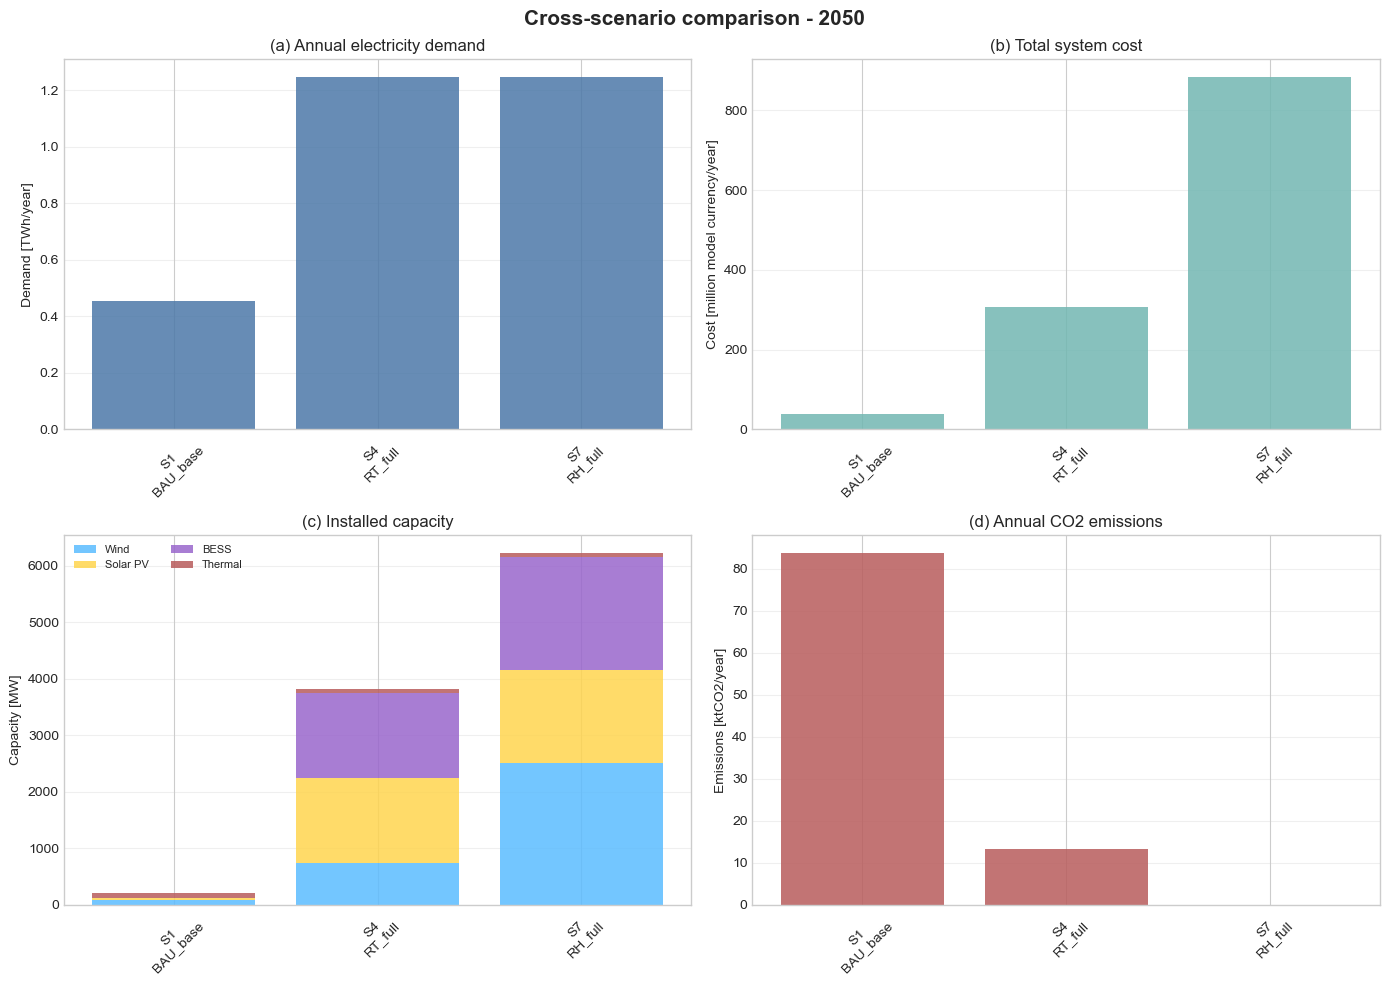

In [252]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure candidate: cross-scenario system design comparison
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

comparison_year = detailed_year  # usually 2050 for the main paper figure

df_y = scenario_comparison[scenario_comparison["year"] == comparison_year].copy()
df_y["label"] = df_y["paper_id"] + "\n" + df_y["scenario"]

# Columns to show as installed capacity
capacity_cols = [
    "cap_wind_mw",
    "cap_solar_mw",
    "cap_bess_mw",
    "cap_ocgt_mw",
    "cap_gas_mw",
    "cap_natural_gas_mw",
    "cap_diesel_mw",
    "linkcap_electrolyzer_mw",
    "linkcap_h2_fuel_cell_mw",
    "linkcap_h2_turbine_mw",
]
capacity_cols = [c for c in capacity_cols if c in df_y.columns and df_y[c].sum() > 0]

cap_labels = {
    "cap_wind_mw": "Wind",
    "cap_solar_mw": "Solar PV",
    "cap_bess_mw": "BESS",
    "cap_ocgt_mw": "Thermal",
    "cap_gas_mw": "Gas",
    "cap_natural_gas_mw": "Natural gas",
    "cap_diesel_mw": "Diesel",
    "linkcap_electrolyzer_mw": "Electrolyser",
    "linkcap_h2_fuel_cell_mw": "H2 fuel cell",
    "linkcap_h2_turbine_mw": "H2 turbine",
}

cap_colors = {
    "cap_wind_mw": TECH_COLORS.get("wind", "#5bbcff"),
    "cap_solar_mw": TECH_COLORS.get("solar", "#ffd54f"),
    "cap_bess_mw": TECH_COLORS.get("bess", "#9966cc"),
    "cap_ocgt_mw": TECH_COLORS.get("ocgt", "#b85c5c"),
    "cap_gas_mw": TECH_COLORS.get("gas", "#bdbdbd"),
    "cap_natural_gas_mw": TECH_COLORS.get("natural_gas", "#bdbdbd"),
    "cap_diesel_mw": "#8d6e63",
    "linkcap_electrolyzer_mw": TECH_COLORS.get("electrolyzer", "#00897b"),
    "linkcap_h2_fuel_cell_mw": TECH_COLORS.get("h2_fuel_cell", "#ff8f00"),
    "linkcap_h2_turbine_mw": TECH_COLORS.get("h2_turbine", "#6d4c41"),
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Cross-scenario comparison - {comparison_year}", fontsize=15, fontweight="bold")

# (a) Annual electricity demand
axes[0, 0].bar(df_y["label"], df_y["demand_mwh"] / 1e6, color="#4c78a8", alpha=0.85)
axes[0, 0].set_title("(a) Annual electricity demand")
axes[0, 0].set_ylabel("Demand [TWh/year]")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].grid(True, axis="y", alpha=0.3)

# (b) Total system cost
axes[0, 1].bar(df_y["label"], df_y["objective"] / 1e6, color="#72b7b2", alpha=0.85)
axes[0, 1].set_title("(b) Total system cost")
axes[0, 1].set_ylabel("Cost [million model currency/year]")
axes[0, 1].tick_params(axis="x", rotation=45)
axes[0, 1].grid(True, axis="y", alpha=0.3)

# (c) Installed capacity by technology
bottom = np.zeros(len(df_y))
x = np.arange(len(df_y))

for col in capacity_cols:
    values = df_y[col].values
    axes[1, 0].bar(
        x, values, bottom=bottom,
        label=cap_labels.get(col, col),
        color=cap_colors.get(col, "#999999"),
        alpha=0.85,
    )
    bottom += values

axes[1, 0].set_title("(c) Installed capacity")
axes[1, 0].set_ylabel("Capacity [MW]")
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(df_y["label"], rotation=45)
axes[1, 0].legend(fontsize=8, ncol=2)
axes[1, 0].grid(True, axis="y", alpha=0.3)

# (d) CO2 emissions
axes[1, 1].bar(df_y["label"], df_y["co2_tons"] / 1e3, color="#b85c5c", alpha=0.85)
axes[1, 1].set_title("(d) Annual CO2 emissions")
axes[1, 1].set_ylabel("Emissions [ktCO2/year]")
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()

fig_path = output_root / f"figure_cross_scenario_design_{comparison_year}.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {fig_path}")
plt.show()


Saved figure to: output\figure_flexibility_transition_2050.png


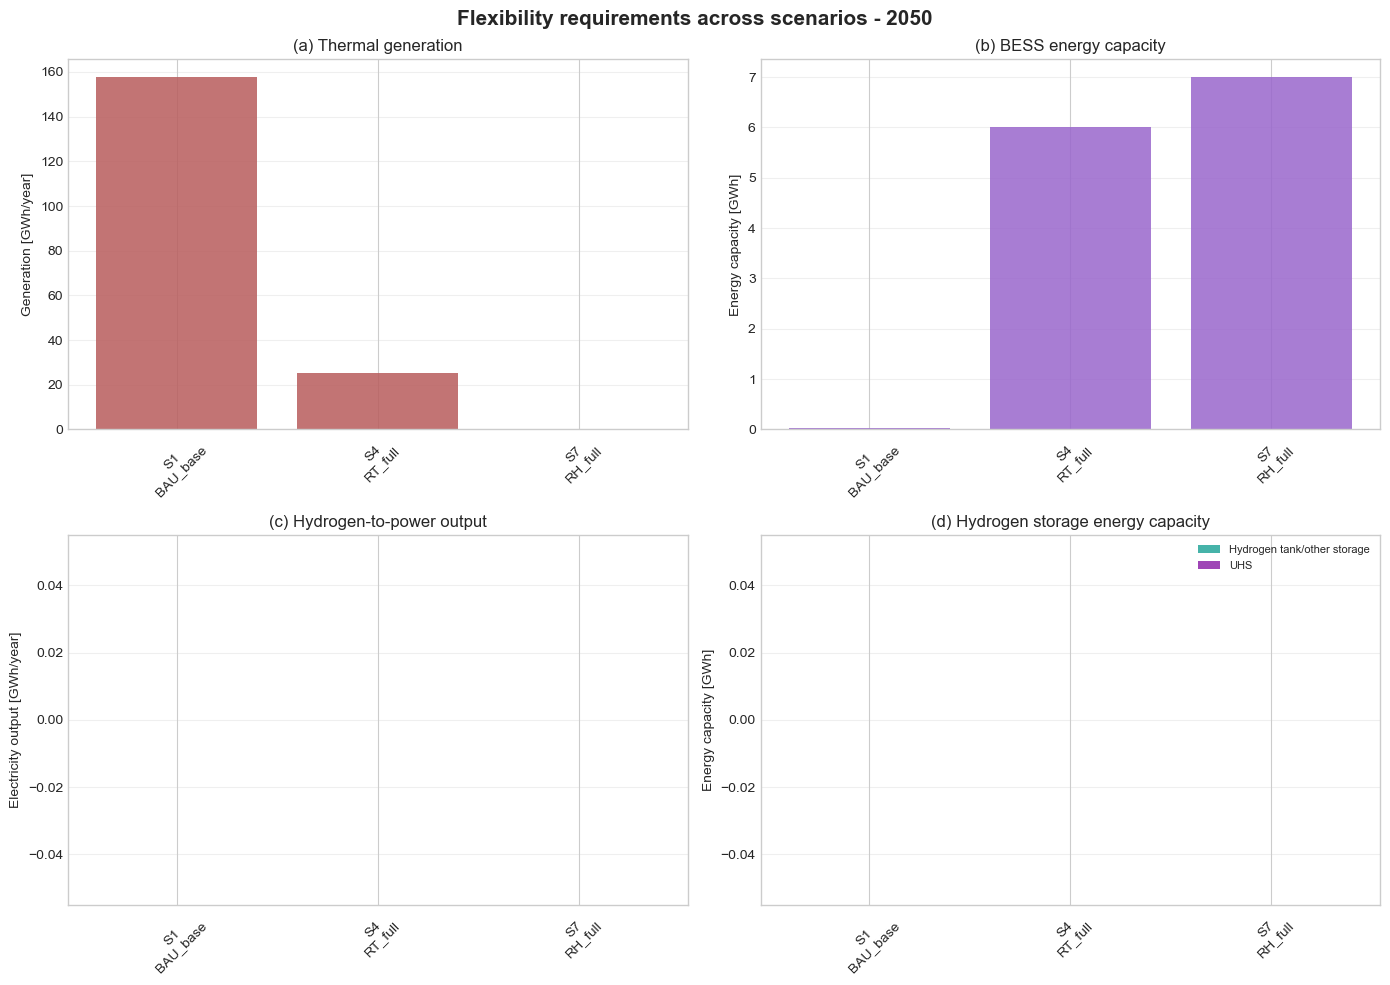

,scenario,paper_id,year,slack_generation_gwh,curtailment_gwh
3,BAU_base,S1,2050,0.000,137.040
4,RT_full,S4,2050,0.000,2845.450
5,RH_full,S7,2050,3.464,10325.192


In [253]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure candidate: flexibility transition across scenarios
# ─────────────────────────────────────────────────────────────────────────────

comparison_year = detailed_year
df_y = scenario_comparison[scenario_comparison["year"] == comparison_year].copy()
df_y["label"] = df_y["paper_id"] + "\n" + df_y["scenario"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f"Flexibility requirements across scenarios - {comparison_year}", fontsize=15, fontweight="bold")

# (a) Thermal generation
axes[0, 0].bar(df_y["label"], df_y["thermal_generation_mwh"] / 1e3, color=TECH_COLORS.get("ocgt", "#b85c5c"), alpha=0.85)
axes[0, 0].set_title("(a) Thermal generation")
axes[0, 0].set_ylabel("Generation [GWh/year]")
axes[0, 0].tick_params(axis="x", rotation=45)
axes[0, 0].grid(True, axis="y", alpha=0.3)

# (b) BESS energy capacity
axes[0, 1].bar(df_y["label"], df_y["energy_bess_mwh"] / 1e3, color=TECH_COLORS.get("bess", "#9966cc"), alpha=0.85)
axes[0, 1].set_title("(b) BESS energy capacity")
axes[0, 1].set_ylabel("Energy capacity [GWh]")
axes[0, 1].tick_params(axis="x", rotation=45)
axes[0, 1].grid(True, axis="y", alpha=0.3)

# (c) Hydrogen-to-power output
axes[1, 0].bar(df_y["label"], df_y["h2_to_power_mwh"] / 1e3, color=TECH_COLORS.get("h2_turbine", "#6d4c41"), alpha=0.85)
axes[1, 0].set_title("(c) Hydrogen-to-power output")
axes[1, 0].set_ylabel("Electricity output [GWh/year]")
axes[1, 0].tick_params(axis="x", rotation=45)
axes[1, 0].grid(True, axis="y", alpha=0.3)

# (d) Hydrogen storage capacity: tank/other H2 storage vs UHS
x = np.arange(len(df_y))
axes[1, 1].bar(
    x, df_y["h2_storage_total_mwh"] / 1e3,
    label="Hydrogen tank/other storage",
    color=TECH_COLORS.get("hydrogen_storage", "#26a69a"),
    alpha=0.85,
)
axes[1, 1].bar(
    x, df_y["uhs_storage_total_mwh"] / 1e3,
    bottom=df_y["h2_storage_total_mwh"] / 1e3,
    label="UHS",
    color=TECH_COLORS.get("uhs_storage", "#8e24aa"),
    alpha=0.85,
)

axes[1, 1].set_title("(d) Hydrogen storage energy capacity")
axes[1, 1].set_ylabel("Energy capacity [GWh]")
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(df_y["label"], rotation=45)
axes[1, 1].legend(fontsize=8)
axes[1, 1].grid(True, axis="y", alpha=0.3)

plt.tight_layout()

fig_path = output_root / f"figure_flexibility_transition_{comparison_year}.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {fig_path}")
plt.show()

# Reliability check table
reliability_check = pd.DataFrame({
    "scenario": df_y["scenario"],
    "paper_id": df_y["paper_id"],
    "year": df_y["year"],
    "slack_generation_gwh": df_y["slack_generation_mwh"] / 1e3,
    "curtailment_gwh": df_y["curtailment_total_mwh"] / 1e3,
})
display(reliability_check.round(3))


In [254]:
# Heat sector analysis: demand, dispatch, and capacities
import pandas as pd

def _heat_series_for_year(results_dict, year):
    """Extract heat demand and supply time series for a given year."""
    net = results_dict[year]['network']
    heat_df = results_dict[year].get('heat_load', pd.DataFrame())
    if heat_df is None or heat_df.empty:
        return None

    total_heat = heat_df.sum(axis=1)
    gas_links = net.links.index[net.links['carrier'] == 'gas_boiler'] if len(net.links) > 0 else []
    hp_links = net.links.index[net.links['carrier'] == 'heat_pump'] if len(net.links) > 0 else []

    gas_heat = pd.Series(0.0, index=net.snapshots)
    hp_heat = pd.Series(0.0, index=net.snapshots)
    hp_power = pd.Series(0.0, index=net.snapshots)

    if len(gas_links) > 0:
        gas_heat = net.links_t.p1[gas_links].abs().sum(axis=1)

    if len(hp_links) > 0:
        hp_heat = net.links_t.p1[hp_links].abs().sum(axis=1)
        hp_power = net.links_t.p0[hp_links].abs().sum(axis=1)

    return {
        'network': net,
        'heat_load': heat_df,
        'total_heat_load': total_heat,
        'gas_boiler_heat': gas_heat,
        'heat_pump_heat': hp_heat,
        'heat_pump_power': hp_power,
    }

def _plot_heat_supply_area(ax, total_heat, gas_heat, hp_heat, title, resample_rule='D'):
    """Plot stacked area of heat supply by technology, smoothed to daily averages."""
    supply = pd.concat(
        [gas_heat.rename('Gas boiler'), hp_heat.rename('Heat pump')],
        axis=1,
    ).fillna(0.0).clip(lower=0.0)

    total_for_plot = total_heat.copy()
    if resample_rule and len(supply) > 0:
        supply = supply.resample(resample_rule).mean()
        total_for_plot = total_for_plot.resample(resample_rule).mean()

    if supply.sum().sum() <= 0:
        total_for_plot.plot(
            ax=ax, color='#222222', linewidth=1.4, linestyle='--',
            label='Heat demand', zorder=3
        )
    else:
        supply.plot.area(
            ax=ax,
            stacked=True,
            color=['#8d6e63', '#42a5f5'],
            alpha=0.92,
            linewidth=0,
        )
        total_for_plot.plot(
            ax=ax, color='#222222', linewidth=1.3, linestyle='--',
            label='Heat demand', zorder=4
        )

    ax.set_title(title, fontsize=12, pad=12)
    ax.set_ylabel('MWth', fontsize=11)
    ax.set_xlabel('Time', fontsize=11)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.25)

analysis_year = detailed_year
heat_data = _heat_series_for_year(all_results, analysis_year)

if heat_data is None:
    print(f"No heat demand configured for {analysis_year}.")
else:
    # Plot previous year if available (for comparison)
    previous_year = None
    if len(years) > 1:
        previous_candidates = [y for y in years if y < analysis_year]
        if previous_candidates:
            previous_year = max(previous_candidates)

    if previous_year is not None:
        prev_data = _heat_series_for_year(all_results, previous_year)
        if prev_data is not None:
            fig_prev, ax_prev = plt.subplots(1, 1, figsize=(14, 4.5))
            prev_total = prev_data['total_heat_load']
            prev_gas = prev_data['gas_boiler_heat']
            prev_hp = prev_data['heat_pump_heat']

            _plot_heat_supply_area(
                ax_prev, prev_total, prev_gas, prev_hp,
                f'Heat supply by technology (daily average) - {previous_year}'
            )
            plt.tight_layout()
            plt.show()

            print(f"\n=== HEAT SUMMARY {previous_year} ===")
            print(f"Annual heat demand: {prev_total.sum():,.0f} MWhth")
            print(f"Gas boiler heat: {prev_gas.sum():,.0f} MWhth")
            print(f"Heat pump heat: {prev_hp.sum():,.0f} MWhth")

    total_heat_load = heat_data['total_heat_load']
    gas_boiler_heat = heat_data['gas_boiler_heat']
    heat_pump_heat = heat_data['heat_pump_heat']
    heat_pump_power = heat_data['heat_pump_power']
    analysis_net = heat_data['network']

    fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

    # Panel 1: Total heat demand time series
    total_heat_load.plot(ax=axes[0], color='#111111', linewidth=1.8, label='Total heat demand')
    axes[0].set_title(f'Heat demand - {analysis_year}', fontsize=12, pad=15)
    axes[0].set_ylabel('MWth', fontsize=11)
    axes[0].legend(loc='best', fontsize=9)
    axes[0].grid(True, alpha=0.25)

    # Panel 2: Heat supply by technology (stacked area, daily average)
    _plot_heat_supply_area(
        axes[1], total_heat_load, gas_boiler_heat, heat_pump_heat,
        f'Heat supply by technology (daily average) - {analysis_year}'
    )

    # Panel 3: Heat pump electricity consumption
    hp_power_daily = heat_pump_power.resample('D').mean() if len(heat_pump_power) > 0 else heat_pump_power
    hp_power_monthly = heat_pump_power.resample('ME').mean() if len(heat_pump_power) > 0 else heat_pump_power
    hp_power_avg = float(heat_pump_power.mean()) if len(heat_pump_power) > 0 else 0.0

    axes[2].plot(
        hp_power_daily.index, hp_power_daily,
        color='#64b5f6', linewidth=1.2, alpha=0.90,
        label='HP electricity consumption (daily avg)'
    )
    axes[2].plot(
        hp_power_monthly.index, hp_power_monthly,
        color='#0d47a1', linewidth=2.8, marker='o', markersize=5,
        label='HP electricity consumption (monthly avg)'
    )
    axes[2].axhline(
        hp_power_avg, color='#1b5e20', linewidth=1.8, linestyle='--',
        label=f'Annual average = {hp_power_avg:.2f} MWel'
    )
    axes[2].set_title(f'Heat pump electricity consumption - {analysis_year}', fontsize=12, pad=15)
    axes[2].set_ylabel('MWel', fontsize=11)
    axes[2].set_xlabel('Time', fontsize=11)
    axes[2].legend(loc='best', fontsize=8)
    axes[2].grid(True, alpha=0.25)

    max_hp = float(max(hp_power_daily.max(), hp_power_monthly.max())) if len(hp_power_daily) > 0 else 0.0
    axes[2].set_ylim(0, max(1.0, max_hp * 1.25))

    plt.tight_layout()
    plt.show()

    # Extra zoom figure (without sharex) to avoid visual compression artifacts
    fig_zoom, ax_zoom = plt.subplots(1, 1, figsize=(14, 4.5))
    ax_zoom.plot(
        hp_power_daily.index, hp_power_daily,
        color='#1976d2', linewidth=1.8, label='HP daily average'
    )
    ax_zoom.scatter(
        hp_power_monthly.index, hp_power_monthly,
        color='#0d47a1', s=35, label='HP monthly average', zorder=3
    )
    ax_zoom.axhline(
        hp_power_avg, color='#1b5e20', linewidth=1.8, linestyle='--',
        label=f'Annual average = {hp_power_avg:.2f} MWel'
    )
    ax_zoom.set_title(f'ZOOM - HP electricity consumption - {analysis_year}', fontsize=12, pad=12)
    ax_zoom.set_ylabel('MWel', fontsize=11)
    ax_zoom.set_xlabel('Time', fontsize=11)
    ax_zoom.set_ylim(0, max(1.0, max_hp * 1.25))
    ax_zoom.legend(loc='best', fontsize=9)
    ax_zoom.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    # Display heat sector link capacities
    heat_links = analysis_net.links[analysis_net.links['carrier'].isin(['gas_boiler', 'heat_pump'])].copy()
    if not heat_links.empty:
        heat_cap_col = 'p_nom_opt' if 'p_nom_opt' in heat_links.columns else 'p_nom'
        heat_caps = heat_links[['carrier', 'bus0', 'bus1', 'efficiency']].copy()
        heat_caps['capacity_mw'] = heat_links[heat_cap_col]
        print(f"\n=== HEAT SECTOR CAPACITIES ({analysis_year}) ===")
        display(heat_caps.sort_values(['carrier', 'capacity_mw'], ascending=[True, False]))

    print(f"\n=== HEAT SECTOR STATISTICS ({analysis_year}) ===")
    print(f"Annual heat demand: {total_heat_load.sum():,.0f} MWhth")
    print(f"Heat served by gas boiler: {gas_boiler_heat.sum():,.0f} MWhth")
    print(f"Heat served by heat pumps: {heat_pump_heat.sum():,.0f} MWhth")
    print(f"Heat pump electricity consumption: {heat_pump_power.sum():,.0f} MWhel")
    if heat_pump_power.sum() > 0:
        print(f"Average operating COP: {heat_pump_heat.sum() / heat_pump_power.sum():.2f}")
        print(f"Average HP power (hourly): {heat_pump_power.mean():.2f} MWel | peak: {heat_pump_power.max():.2f} MWel")

No heat demand configured for 2050.


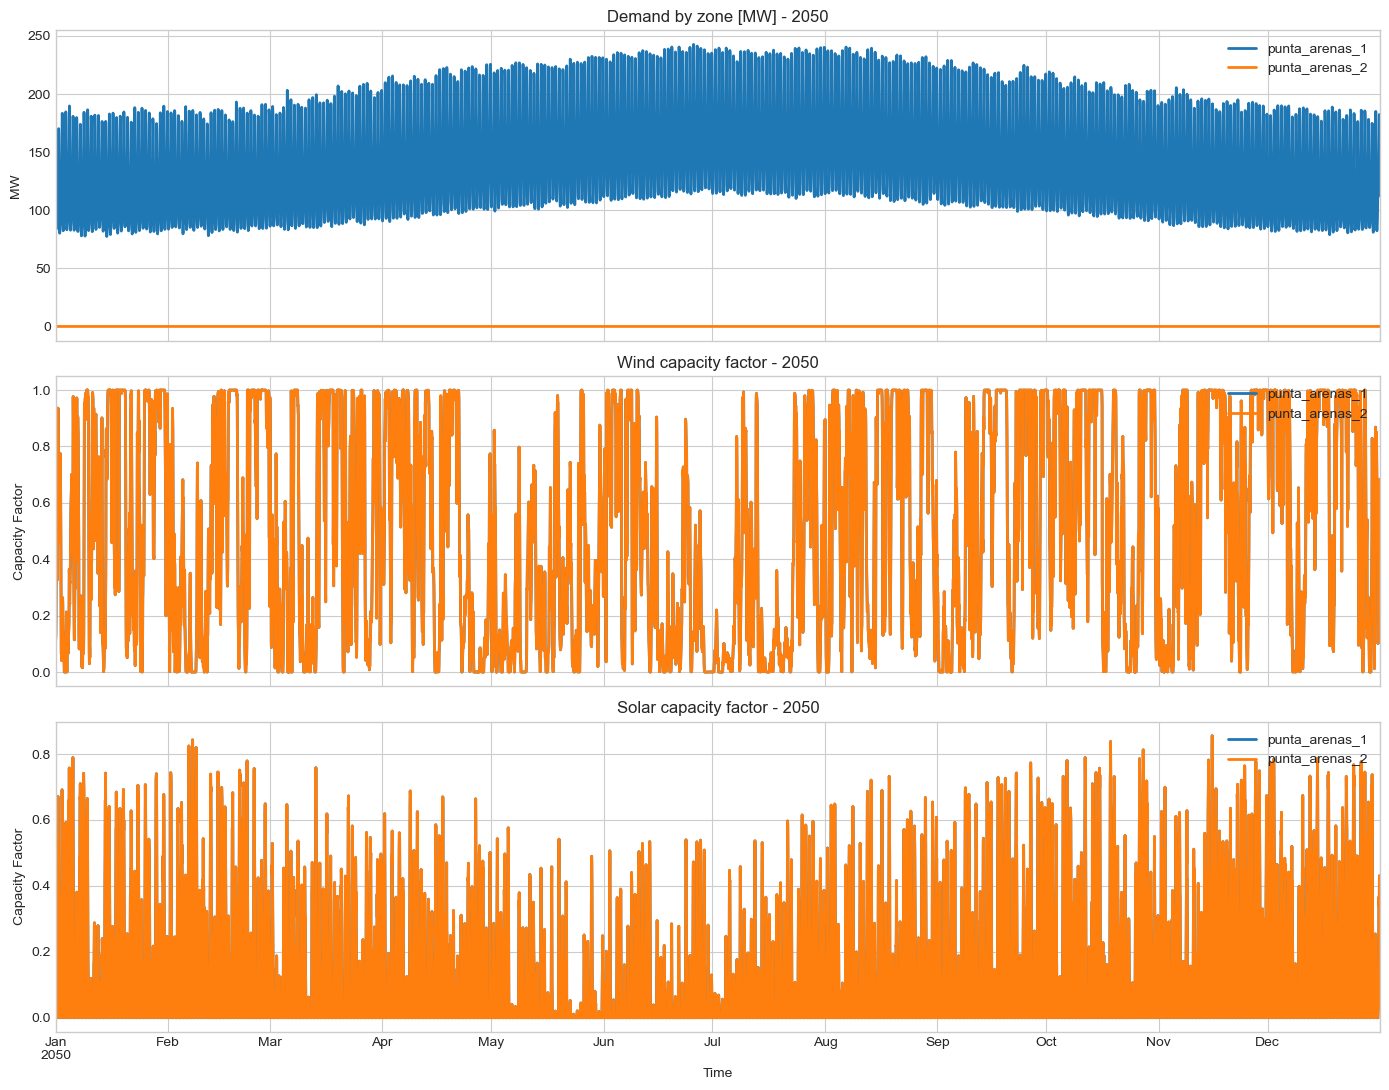

In [255]:
# Input profiles: demand, wind capacity factor, and solar capacity factor
fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)

load.plot(ax=axes[0], linewidth=2, title=f'Demand by zone [MW] - {detailed_year}', legend=True)
axes[0].set_ylabel('MW')
axes[0].get_legend().set_loc('upper right')

wind_cf.plot(ax=axes[1], linewidth=2, title=f'Wind capacity factor - {detailed_year}', legend=True)
axes[1].set_ylabel('Capacity Factor')
axes[1].get_legend().set_loc('upper right')

solar_cf.plot(ax=axes[2], linewidth=2, title=f'Solar capacity factor - {detailed_year}', legend=True)
axes[2].set_ylabel('Capacity Factor')
axes[2].set_xlabel('Time')
axes[2].get_legend().set_loc('upper right')

plt.tight_layout()
plt.show()

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


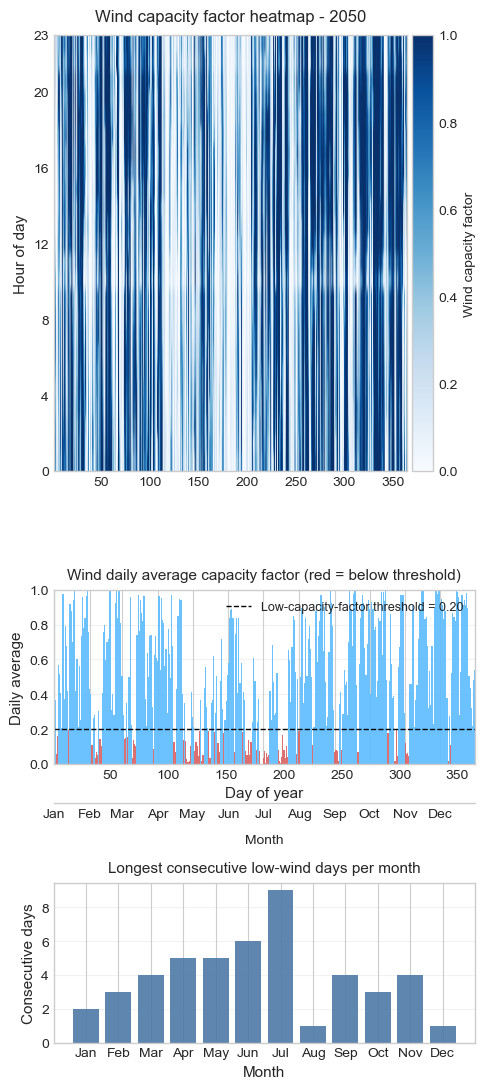

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


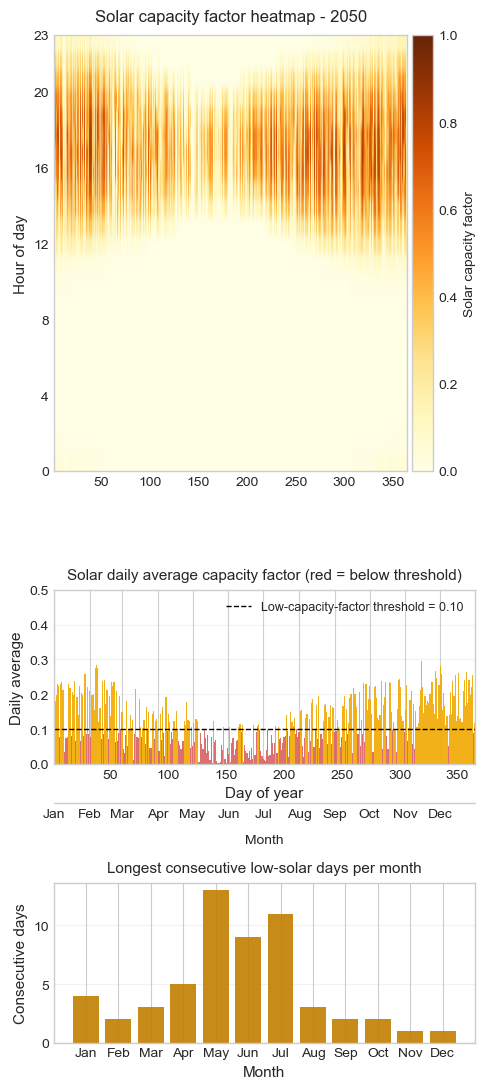

In [256]:
# Wind and solar capacity factor diagnostics (English labels)
import numpy as np
import pandas as pd

# Easy-to-tune thresholds for low-resource diagnostics
low_wind_threshold = 0.20
low_solar_threshold = 0.10

def _prepare_cf_series(cf_df: pd.DataFrame) -> pd.Series:
    if cf_df.empty:
        raise ValueError('No capacity factor data available to plot.')

    cf = cf_df.copy()
    if not isinstance(cf.index, pd.DatetimeIndex):
        cf.index = pd.to_datetime(cf.index)

    # Average across zones for each timestamp
    return cf.mean(axis=1)

def _cf_heatmap_matrix(cf_series: pd.Series) -> pd.DataFrame:
    data = pd.DataFrame({
        'capacity_factor': cf_series.values,
        'day': cf_series.index.dayofyear,
        'hour': cf_series.index.hour,
    })
    pivot = data.pivot_table(index='hour', columns='day', values='capacity_factor', aggfunc='mean')
    return pivot.reindex(index=range(24), columns=range(1, int(cf_series.index.dayofyear.max()) + 1))

def _daily_mean_series(cf_series: pd.Series) -> pd.Series:
    return cf_series.resample('D').mean()

def _monthly_max_consecutive_low_days(daily_cf: pd.Series, threshold: float) -> pd.Series:
    month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    result = pd.Series(0, index=month_labels, dtype=float)

    for month_num, month_data in daily_cf.groupby(daily_cf.index.month):
        mask = month_data.values < threshold
        max_len = 0
        cur_len = 0
        for is_low in mask:
            if is_low:
                cur_len += 1
                max_len = max(max_len, cur_len)
            else:
                cur_len = 0
        result.iloc[month_num - 1] = max_len

    return result

wind_series = _prepare_cf_series(wind_cf)
solar_series = _prepare_cf_series(solar_cf)
wind_matrix = _cf_heatmap_matrix(wind_series)
solar_matrix = _cf_heatmap_matrix(solar_series)
wind_daily = _daily_mean_series(wind_series)
solar_daily = _daily_mean_series(solar_series)
wind_streak_monthly = _monthly_max_consecutive_low_days(wind_daily, low_wind_threshold)
solar_streak_monthly = _monthly_max_consecutive_low_days(solar_daily, low_solar_threshold)

# ---- WIND: heatmap + daily average + monthly consecutive low-wind days ----
fig, axes = plt.subplots(
    3, 1, figsize=(5, 11), sharex=False,
    gridspec_kw={'height_ratios': [3, 1.2, 1.1]}
)

im_w = axes[0].imshow(
    wind_matrix.values,
    origin='lower',
    aspect='auto',
    cmap='Blues',
    vmin=0,
    vmax=1,
    extent=[1, wind_matrix.shape[1], 0, 23],
)
axes[0].set_title(f'Wind capacity factor heatmap - {detailed_year}', fontsize=12, pad=10)
axes[0].set_ylabel('Hour of day', fontsize=11)
axes[0].set_yticks([0, 4, 8, 12, 16, 20, 23])
axes[0].grid(False)
cbar_w = plt.colorbar(im_w, ax=axes[0], pad=0.01)
cbar_w.set_label('Wind capacity factor', fontsize=10)

wind_daily_day = wind_daily.index.dayofyear
wind_colors = np.where(wind_daily.values < low_wind_threshold, '#d95f5f', '#5bbcff')
axes[1].bar(wind_daily_day, wind_daily.values, color=wind_colors, width=1.0, alpha=0.9)
axes[1].axhline(
    low_wind_threshold, color='black', linestyle='--', linewidth=1,
    label=f'Low-capacity-factor threshold = {low_wind_threshold:.2f}'
)
axes[1].set_title('Wind daily average capacity factor (red = below threshold)', fontsize=11, pad=8)
axes[1].set_ylabel('Daily average', fontsize=11)
axes[1].set_xlabel('Day of year', fontsize=11)
axes[1].set_ylim(0, 1)
axes[1].set_xlim(1, wind_matrix.shape[1])
axes[1].grid(True, axis='y', alpha=0.25)
axes[1].xaxis.grid(False, which='both')
axes[1].legend(loc='upper right', fontsize=9)

# Keep day-of-year on the main bottom axis and add month labels on lower bottom axis
month_starts = wind_daily.resample('MS').first().index
month_start_days = month_starts.dayofyear.values
month_start_labels = month_starts.strftime('%b')

ax_month_bottom = axes[1].secondary_xaxis('bottom')
ax_month_bottom.set_xticks(month_start_days)
ax_month_bottom.set_xticklabels(month_start_labels)
ax_month_bottom.spines['bottom'].set_position(('outward', 28))
ax_month_bottom.set_xlabel('Month', fontsize=10, labelpad=10)
ax_month_bottom.grid(False)
ax_month_bottom.xaxis.grid(False, which='both')

# Draw month boundaries explicitly to avoid mixed automatic x-grid spacing
for day in month_start_days:
    axes[1].axvline(day, color='#bcbcbc', linewidth=0.8, alpha=0.7, zorder=0)

axes[2].bar(wind_streak_monthly.index, wind_streak_monthly.values, color='#4e79a7', alpha=0.9)
axes[2].set_title('Longest consecutive low-wind days per month', fontsize=11, pad=8)
axes[2].set_ylabel('Consecutive days', fontsize=11)
axes[2].set_xlabel('Month', fontsize=11)
axes[2].grid(True, axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

# ---- SOLAR: heatmap + daily average + monthly consecutive low-solar days ----
fig, axes = plt.subplots(
    3, 1, figsize=(5, 11), sharex=False,
    gridspec_kw={'height_ratios': [3, 1.2, 1.1]}
)

im_s = axes[0].imshow(
    solar_matrix.values,
    origin='lower',
    aspect='auto',
    cmap='YlOrBr',
    vmin=0,
    vmax=1,
    extent=[1, solar_matrix.shape[1], 0, 23],
)
axes[0].set_title(f'Solar capacity factor heatmap - {detailed_year}', fontsize=12, pad=10)
axes[0].set_ylabel('Hour of day', fontsize=11)
axes[0].set_yticks([0, 4, 8, 12, 16, 20, 23])
axes[0].grid(False)
cbar_s = plt.colorbar(im_s, ax=axes[0], pad=0.01)
cbar_s.set_label('Solar capacity factor', fontsize=10)

solar_daily_day = solar_daily.index.dayofyear
solar_colors = np.where(solar_daily.values < low_solar_threshold, '#d95f5f', '#f2a900')
axes[1].bar(solar_daily_day, solar_daily.values, color=solar_colors, width=1.0, alpha=0.9)
axes[1].axhline(
    low_solar_threshold, color='black', linestyle='--', linewidth=1,
    label=f'Low-capacity-factor threshold = {low_solar_threshold:.2f}'
)
axes[1].set_title('Solar daily average capacity factor (red = below threshold)', fontsize=11, pad=8)
axes[1].set_ylabel('Daily average', fontsize=11)
axes[1].set_xlabel('Day of year', fontsize=11)
axes[1].set_ylim(0, 0.5)
axes[1].set_xlim(1, solar_matrix.shape[1])
axes[1].grid(True, axis='y', alpha=0.25)
axes[1].xaxis.grid(False, which='both')
axes[1].legend(loc='upper right', fontsize=9)

# Match month labels and month boundary lines as in wind daily chart
solar_month_starts = solar_daily.resample('MS').first().index
solar_month_start_days = solar_month_starts.dayofyear.values
solar_month_start_labels = solar_month_starts.strftime('%b')

ax_solar_month_bottom = axes[1].secondary_xaxis('bottom')
ax_solar_month_bottom.set_xticks(solar_month_start_days)
ax_solar_month_bottom.set_xticklabels(solar_month_start_labels)
ax_solar_month_bottom.spines['bottom'].set_position(('outward', 28))
ax_solar_month_bottom.set_xlabel('Month', fontsize=10, labelpad=10)
ax_solar_month_bottom.grid(False)
ax_solar_month_bottom.xaxis.grid(False, which='both')

for day in solar_month_start_days:
    axes[1].axvline(day, color='#bcbcbc', linewidth=0.8, alpha=0.7, zorder=0)

axes[2].bar(solar_streak_monthly.index, solar_streak_monthly.values, color='#c17f00', alpha=0.9)
axes[2].set_title('Longest consecutive low-solar days per month', fontsize=11, pad=8)
axes[2].set_ylabel('Consecutive days', fontsize=11)
axes[2].set_xlabel('Month', fontsize=11)
axes[2].grid(True, axis='y', alpha=0.25)

plt.tight_layout()
plt.show()

## Critical low-renewable event window

This cell identifies the longest simultaneous low-wind and low-solar event for the currently selected `active_scenario` and `detailed_year`. The resulting time window is then reused by the event-dispatch comparison cell below.

In [257]:
# ─────────────────────────────────────────────────────────────────────────────
# Identify the longest simultaneous low-wind and low-solar event
# ─────────────────────────────────────────────────────────────────────────────

low_wind_threshold = 0.20
low_solar_threshold = 0.10


def _longest_true_run(mask: pd.Series):
    """Return start, end and duration of the longest consecutive True run."""
    mask = mask.astype(bool)

    best_start = None
    best_end = None
    best_len = 0

    cur_start = None
    cur_len = 0

    for ts, value in mask.items():
        if value:
            if cur_start is None:
                cur_start = ts
                cur_len = 1
            else:
                cur_len += 1

            if cur_len > best_len:
                best_len = cur_len
                best_start = cur_start
                best_end = ts
        else:
            cur_start = None
            cur_len = 0

    return best_start, best_end, best_len


def identify_simultaneous_low_event(wind_cf, solar_cf, wind_threshold=0.20, solar_threshold=0.10):
    wind_series = wind_cf.mean(axis=1).copy()
    solar_series = solar_cf.mean(axis=1).copy()

    wind_series.index = pd.to_datetime(wind_series.index)
    solar_series.index = pd.to_datetime(solar_series.index)

    wind_daily = wind_series.resample("D").mean()
    solar_daily = solar_series.resample("D").mean()

    low_event_mask = (wind_daily < wind_threshold) & (solar_daily < solar_threshold)
    start, end, duration_days = _longest_true_run(low_event_mask)

    event_table = pd.DataFrame({
        "wind_daily_cf": wind_daily,
        "solar_daily_cf": solar_daily,
        "simultaneous_low": low_event_mask,
    })

    if start is None:
        raise ValueError("No simultaneous low-wind and low-solar event found with the selected thresholds.")

    return {
        "start_day": start,
        "end_day": end,
        "duration_days": duration_days,
        "start_hour": pd.Timestamp(start),
        "end_hour": pd.Timestamp(end) + pd.Timedelta(hours=23),
        "event_table": event_table,
    }


critical_event = identify_simultaneous_low_event(
    wind_cf,
    solar_cf,
    wind_threshold=low_wind_threshold,
    solar_threshold=low_solar_threshold,
)

critical_event_start = critical_event["start_hour"]
critical_event_end = critical_event["end_hour"]

print("Critical simultaneous low-renewable event:")
print(f"  Start: {critical_event_start}")
print(f"  End:   {critical_event_end}")
print(f"  Duration: {critical_event['duration_days']} days")

display(
    critical_event["event_table"]
    .loc[critical_event["start_day"]:critical_event["end_day"]]
    .round(3)
)

# Export event table for traceability
critical_event_table_path = output_root / f"critical_event_daily_table_{base_case_name}_{active_scenario}_{detailed_year}.csv"
critical_event["event_table"].to_csv(critical_event_table_path)
print(f"Saved daily event table to: {critical_event_table_path}")


Critical simultaneous low-renewable event:
  Start: 2050-06-28 00:00:00
  End:   2050-07-06 23:00:00
  Duration: 9 days


,wind_daily_cf,solar_daily_cf,simultaneous_low
2050-06-28,0.077,0.097,True
2050-06-29,0.000,0.037,True
2050-06-30,0.000,0.024,True
2050-07-01,0.037,0.014,True
2050-07-02,0.075,0.010,True
2050-07-03,0.005,0.009,True
2050-07-04,0.064,0.040,True
2050-07-05,0.041,0.098,True
2050-07-06,0.050,0.022,True


Saved daily event table to: output\critical_event_daily_table_punta_arenas_RH_full_2050.csv


In [258]:
# Optimized generator and link capacities overview
gen_caps = n.generators[['bus', 'carrier', 'p_nom_opt']].sort_values('p_nom_opt', ascending=False)
link_caps = n.links[['bus0', 'bus1', 'p_nom']]
display(gen_caps)
display(link_caps)

,bus,carrier,p_nom_opt
name,,,
slack_punta_arenas_1,elec_punta_arenas_1,slack,1000000.00
slack_punta_arenas_2,elec_punta_arenas_2,slack,1000000.00
wind_flexible_punta_arenas_2,elec_punta_arenas_2,wind,2500.00
solar_utility_flexible_punta_arenas_2,elec_punta_arenas_2,solar,1500.00
pv_residential_flexible_punta_arenas_1,elec_punta_arenas_1,solar,150.00
ocgt_existing_punta_arenas_1,elec_punta_arenas_1,ocgt,80.00
wind_existing_punta_arenas_2,elec_punta_arenas_2,wind,2.55


,bus0,bus1,p_nom
name,,,
tx_punta_arenas_1_2_fwd,elec_punta_arenas_1,elec_punta_arenas_2,0.0
tx_punta_arenas_1_2_rev,elec_punta_arenas_2,elec_punta_arenas_1,0.0
h2_electrolyzer_punta_arenas_2,elec_punta_arenas_2,h2_punta_arenas_2,0.0
h2_fuel_cell_punta_arenas_2,h2_punta_arenas_2,elec_punta_arenas_2,0.0
h2_turbine_punta_arenas_2,h2_punta_arenas_2,elec_punta_arenas_2,0.0
uhs_injection_punta_arenas_2,h2_punta_arenas_2,uhs_punta_arenas_2,0.0
uhs_withdrawal_punta_arenas_2,uhs_punta_arenas_2,h2_punta_arenas_2,0.0



=== INSTALLED CAPACITY BY TECHNOLOGY AND YEAR [MW] ===


carrier,wind,solar,bess,ocgt
2025,2.55,0.0,0.0,80.0
2050,2502.55,1650.0,2000.0,80.0


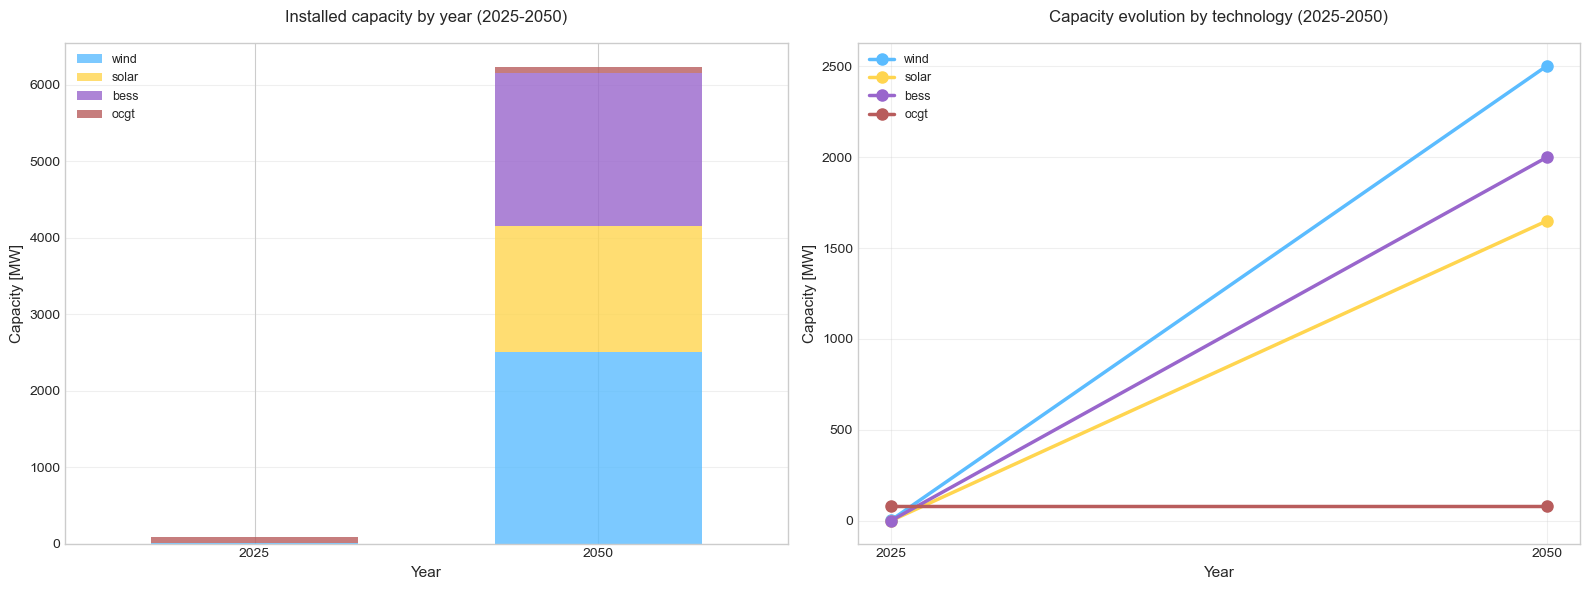


=== INSTALLED CAPACITY GROWTH ===

WIND:
  2025: 2.5 MW
  2050: 2502.6 MW
  Growth 2025-2050: 2500.0 MW (98039.2%)

SOLAR:
  2025: 0.0 MW
  2050: 1650.0 MW
  Growth 2025-2050: 1650.0 MW (0.0%)

BESS:
  2025: 0.0 MW
  2050: 2000.0 MW
  Growth 2025-2050: 2000.0 MW (0.0%)

OCGT:
  2025: 80.0 MW
  2050: 80.0 MW
  Growth 2025-2050: 0.0 MW (0.0%)

=== TOTAL CAPACITY ===
2025: 82.5 MW
2050: 6232.6 MW


In [259]:
# Installed capacity comparison across years
import pandas as pd
import numpy as np

period_start = years[0]
period_end = years[-1]

# Extract capacities by technology and year
capacity_by_year = {}
for year in years:
    net = all_results[year]['network']

    # Generators by technology
    gen_by_tech = net.generators.groupby('carrier')['p_nom_opt'].sum()

    # BESS (storage units)
    if len(net.storage_units) > 0:
        bess_cap = net.storage_units['p_nom_opt'].sum()
        gen_by_tech['bess'] = bess_cap

    capacity_by_year[year] = gen_by_tech

# Build DataFrame with all technologies and years
cap_df = pd.DataFrame(capacity_by_year).T.fillna(0)
cap_df = cap_df[['wind', 'solar', 'bess', 'ocgt']] if 'bess' in cap_df.columns else cap_df[['wind', 'solar', 'ocgt']]

# Color fallback
if 'TECH_COLORS' not in globals():
    TECH_COLORS = {
        'wind': '#5bbcff',
        'solar': '#ffd54f',
        'ocgt': '#b85c5c',
        'bess': '#9966cc',
        'slack': '#d32f2f',
        'natural_gas': '#bdbdbd',
        'gas': '#bdbdbd',
    }

print("\n=== INSTALLED CAPACITY BY TECHNOLOGY AND YEAR [MW] ===")
display(cap_df.round(2))

# Comparative plots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Stacked bars by year
tech_colors = [TECH_COLORS.get(t, '#999999') for t in cap_df.columns]
cap_df.plot.bar(ax=axes[0], stacked=True, color=tech_colors, alpha=0.8, width=0.6)
axes[0].set_title(f'Installed capacity by year ({period_start}-{period_end})', fontsize=12, pad=15)
axes[0].set_ylabel('Capacity [MW]', fontsize=11)
axes[0].set_xlabel('Year', fontsize=11)
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

# Plot 2: Technology evolution lines
for tech in cap_df.columns:
    axes[1].plot(cap_df.index, cap_df[tech], marker='o', linewidth=2.5,
                 label=tech, color=TECH_COLORS.get(tech, '#999999'), markersize=8)

axes[1].set_title(f'Capacity evolution by technology ({period_start}-{period_end})', fontsize=12, pad=15)
axes[1].set_ylabel('Capacity [MW]', fontsize=11)
axes[1].set_xlabel('Year', fontsize=11)
axes[1].legend(loc='upper left', fontsize=9)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(cap_df.index)

plt.tight_layout()
plt.show()

# Growth statistics
print("\n=== INSTALLED CAPACITY GROWTH ===")
for tech in cap_df.columns:
    if cap_df[tech].max() > 0:
        growth_total = cap_df.loc[period_end, tech] - cap_df.loc[period_start, tech]
        growth_pct = (growth_total / cap_df.loc[period_start, tech] * 100) if cap_df.loc[period_start, tech] > 0 else 0
        print(f"\n{tech.upper()}:")
        for year in years:
            print(f"  {year}: {cap_df.loc[year, tech]:.1f} MW")
        print(f"  Growth {period_start}-{period_end}: {growth_total:.1f} MW ({growth_pct:.1f}%)")

print(f"\n=== TOTAL CAPACITY ===")
for year in years:
    total = cap_df.loc[year].sum()
    print(f"{year}: {total:.1f} MW")


=== TOTAL CAPACITY BY ZONE AND YEAR [MW] ===


,2025,2050
bus,,
punta_arenas_1,1000080.00,1000230.00
punta_arenas_2,1000002.55,1006002.55


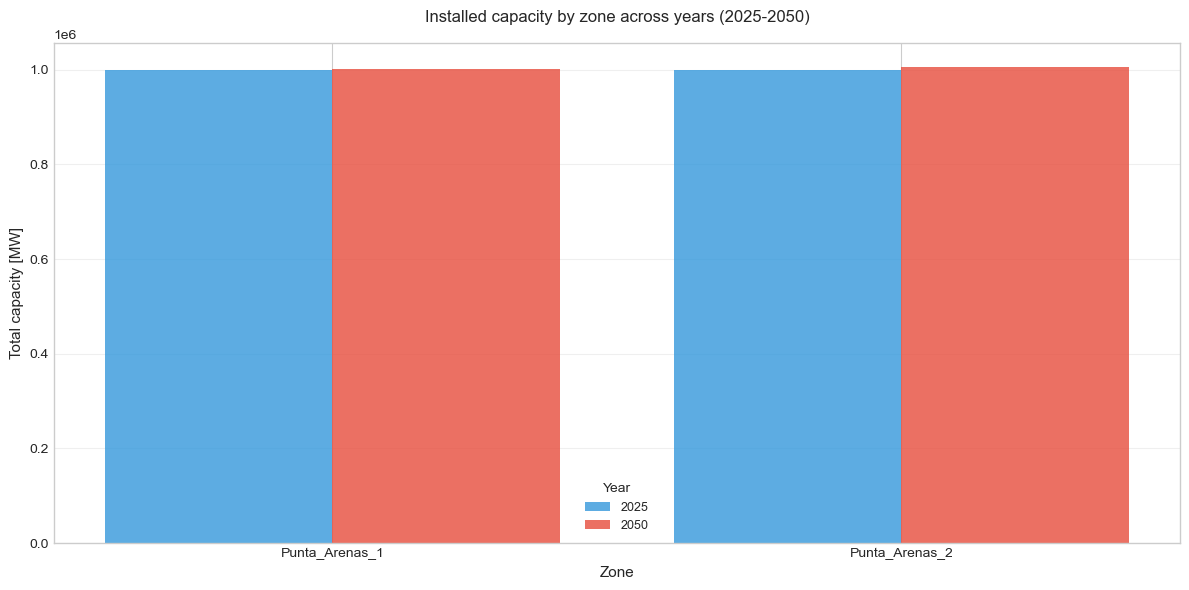


=== GROWTH BY ZONE ===

PUNTA_ARENAS_1:
  2025: 1000080.0 MW
  2050: 1000230.0 MW
  Growth 2025-2050: 150.0 MW (0.0%)

PUNTA_ARENAS_2:
  2025: 1000002.6 MW
  2050: 1006002.6 MW
  Growth 2025-2050: 6000.0 MW (0.6%)


In [260]:
# Installed capacity comparison by zone across years
period_start = years[0]
period_end = years[-1]

# Extract capacities by zone and year
capacity_by_zone_year = {}
for year in years:
    net = all_results[year]['network']

    # Generators by zone
    gen_by_zone = net.generators.groupby(net.generators['bus'].str.replace('elec_', ''))['p_nom_opt'].sum()

    # Add BESS if present
    if len(net.storage_units) > 0:
        bess_by_zone = net.storage_units.groupby(net.storage_units['bus'].str.replace('elec_', ''))['p_nom_opt'].sum()
        gen_by_zone = gen_by_zone.add(bess_by_zone, fill_value=0)

    capacity_by_zone_year[year] = gen_by_zone

# Build DataFrame
cap_zone_df = pd.DataFrame(capacity_by_zone_year).fillna(0)

print("\n=== TOTAL CAPACITY BY ZONE AND YEAR [MW] ===")
display(cap_zone_df.round(2))

# Grouped bar chart by zone
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(cap_zone_df.index))
width = 0.8 / len(years)
colors_years = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12']

for i, year in enumerate(years):
    offset = width * (i - (len(years) - 1) / 2)
    ax.bar(x + offset, cap_zone_df[year], width, label=str(year),
           color=colors_years[i % len(colors_years)], alpha=0.8)

ax.set_title(f'Installed capacity by zone across years ({period_start}-{period_end})', fontsize=12, pad=15)
ax.set_ylabel('Total capacity [MW]', fontsize=11)
ax.set_xlabel('Zone', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels([z.title() for z in cap_zone_df.index])
ax.legend(title='Year', fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Statistics by zone
print("\n=== GROWTH BY ZONE ===")
for zone in cap_zone_df.index:
    growth = cap_zone_df.loc[zone, period_end] - cap_zone_df.loc[zone, period_start]
    growth_pct = (growth / cap_zone_df.loc[zone, period_start] * 100) if cap_zone_df.loc[zone, period_start] > 0 else 0
    print(f"\n{zone.upper()}:")
    for year in years:
        print(f"  {year}: {cap_zone_df.loc[zone, year]:.1f} MW")
    print(f"  Growth {period_start}-{period_end}: {growth:.1f} MW ({growth_pct:.1f}%)")

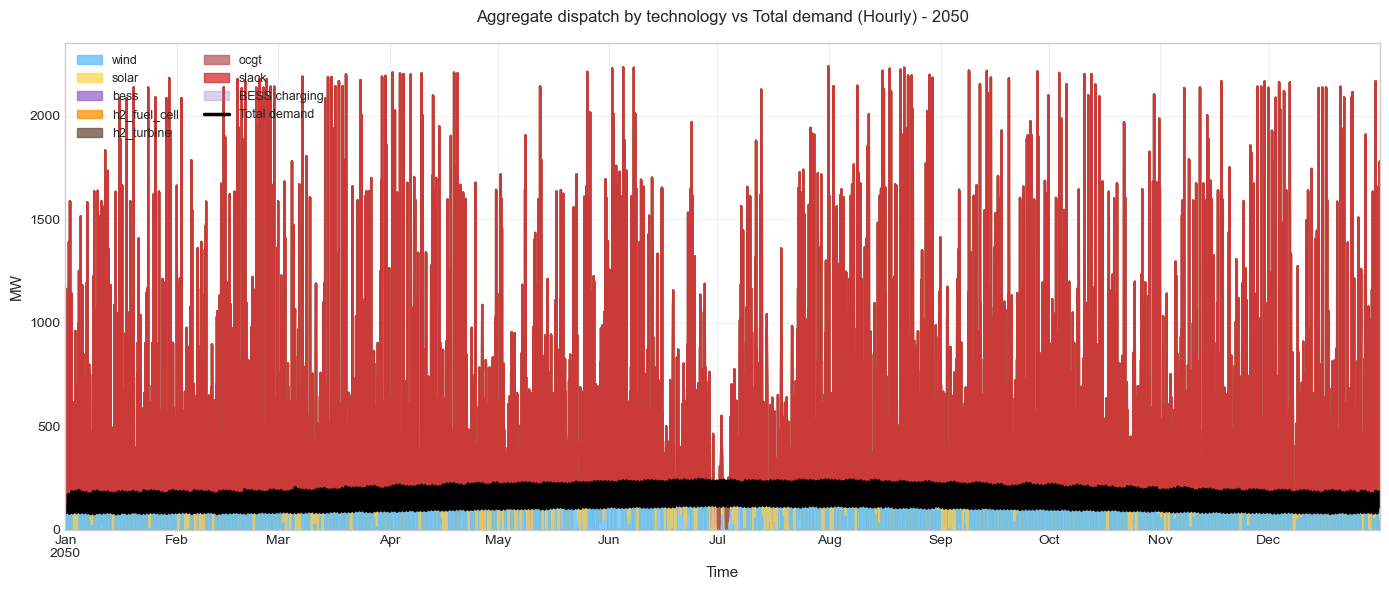

In [261]:
# Aggregate dispatch by technology vs total demand
analysis_year = detailed_year

dispatch = n.generators_t.p.copy()
#dispatch_by_tech = dispatch.T.groupby(dispatch.T.index.str.split('_').str[0]).sum().T
gen_carrier = n.generators["carrier"].astype(str)
dispatch_by_tech = dispatch.T.groupby(gen_carrier).sum().T
dispatch_by_tech = dispatch_by_tech.clip(lower=0)

# Clip small numerical negatives to zero to prevent area() plot errors
negative_techs = [
    tech for tech in dispatch_by_tech.columns
    if dispatch_by_tech[tech].min() < -1e-6
]
if negative_techs:
    print(f"Warning: negative values detected in {negative_techs}; clipping to 0 for plotting.")
dispatch_by_tech = dispatch_by_tech.clip(lower=0)

# BESS: separate charge and discharge per unit before aggregating
if len(n.storage_units) > 0:
    bess_power_by_unit = n.storage_units_t.p.copy()
    bess_discharge = bess_power_by_unit.clip(lower=0).sum(axis=1)
    bess_charge = -bess_power_by_unit.clip(upper=0).sum(axis=1)
    dispatch_by_tech['bess'] = bess_discharge
else:
    bess_charge = None

# Electricity output from hydrogen links (output at bus1)
if len(n.links) > 0:
    fuel_cell_links = n.links.index[n.links['carrier'] == 'h2_fuel_cell']
    if len(fuel_cell_links) > 0:
        dispatch_by_tech['h2_fuel_cell'] = (-n.links_t.p1[fuel_cell_links]).clip(lower=0).sum(axis=1)

    turbine_links = n.links.index[n.links['carrier'] == 'h2_turbine']
    if len(turbine_links) > 0:
        dispatch_by_tech['h2_turbine'] = (-n.links_t.p1[turbine_links]).clip(lower=0).sum(axis=1)

total_load = load.sum(axis=1)

# Consistent order and colors by technology
preferred_order = ['wind', 'solar', 'bess', 'h2_fuel_cell', 'h2_turbine', 'ocgt', 'gas', 'slack']
tech_order = [t for t in preferred_order if t in dispatch_by_tech.columns]
# Include any remaining techs not in the preferred order
tech_order += [t for t in dispatch_by_tech.columns if t not in tech_order]
dispatch_plot = dispatch_by_tech[tech_order]
tech_colors = [TECH_COLORS.get(t, '#999999') for t in tech_order]

fig, ax = plt.subplots(figsize=(14, 6))
dispatch_plot.plot.area(ax=ax, alpha=0.75, legend=True, color=tech_colors)

# Show BESS charging as negative area
if bess_charge is not None:
    ax.fill_between(bess_charge.index, 0, -bess_charge, alpha=0.3, color=TECH_COLORS['bess'],
                     label='BESS charging', step='mid')

total_load.plot(ax=ax, color='black', linewidth=2.5, label='Total demand', legend=True)

ax.set_title(f'Aggregate dispatch by technology vs Total demand (Hourly) - {analysis_year}', fontsize=12, pad=15)
ax.set_ylabel('MW', fontsize=11)
ax.set_xlabel('Time', fontsize=11)
ax.legend(loc='upper left', ncol=2, fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Critical-event deep-dive across selected scenarios

This is the detailed scenario-level analysis. It zooms into the critical event window and compares how selected scenarios supply demand during the same low-renewable period.

Saved figure to: output\figure_critical_event_dispatch_2050.png


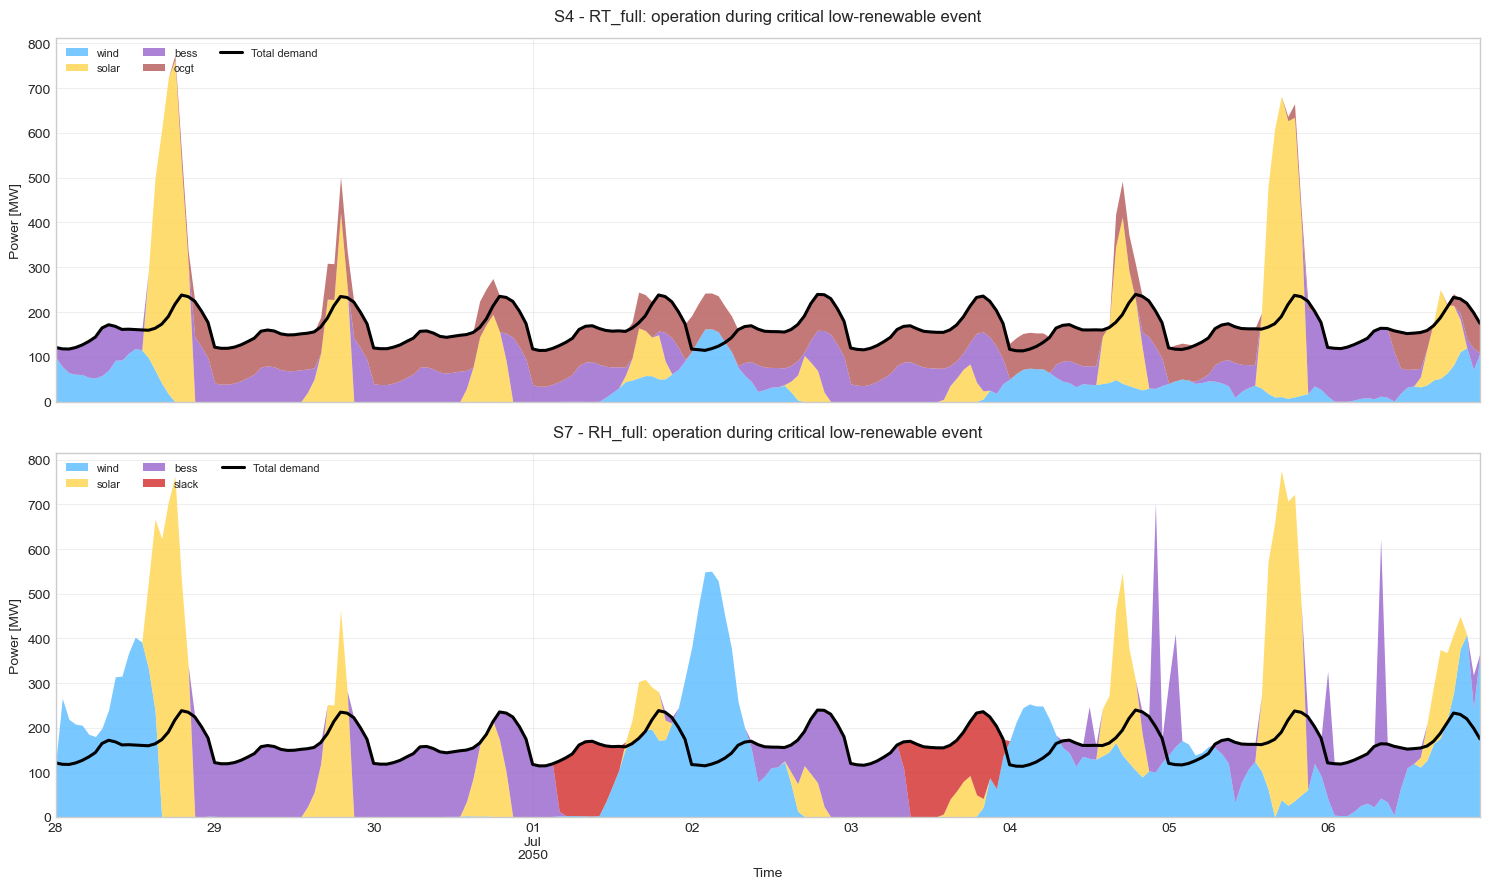

,scenario,paper_id,event_start,event_end,event_demand_mwh,wind_event_generation_mwh,solar_event_generation_mwh,bess_event_generation_mwh,h2_fuel_cell_event_generation_mwh,h2_turbine_event_generation_mwh,ocgt_event_generation_mwh,slack_event_generation_mwh
0,RT_full,S4,2050-06-28,2050-07-06 23:00:00,35677.73,6201.07,12610.49,10697.30,0.0,0.0,13572.63,0.00
1,RH_full,S7,2050-06-28,2050-07-06 23:00:00,35677.73,20516.74,13417.53,14104.32,0.0,0.0,0.00,3463.82


Saved event dispatch summary to: output\critical_event_dispatch_summary_2050.csv


In [262]:
# ─────────────────────────────────────────────────────────────────────────────
# Figure candidate: dispatch comparison during the critical low-renewable event
# ─────────────────────────────────────────────────────────────────────────────

selected_scenarios_for_event = ["RT_full", "RH_full"]
event_year = detailed_year


def _dispatch_by_technology_for_network(net):
    """Build electricity dispatch by technology, including BESS and H2-to-power."""
    dispatch = net.generators_t.p.reindex(columns=net.generators.index, fill_value=0.0).clip(lower=0.0)
    gen_carrier = net.generators["carrier"].astype(str)
    dispatch_by_tech = dispatch.T.groupby(gen_carrier).sum().T

    # BESS discharge
    if len(net.storage_units) > 0:
        bess_power = net.storage_units_t.p.copy()
        dispatch_by_tech["bess"] = bess_power.clip(lower=0.0).sum(axis=1)

    # Hydrogen-to-power output
    if len(net.links) > 0:
        for carrier in ["h2_fuel_cell", "h2_turbine"]:
            links = net.links.index[net.links["carrier"].astype(str) == carrier]
            if len(links) > 0:
                dispatch_by_tech[carrier] = (-net.links_t.p1[links]).clip(lower=0.0).sum(axis=1)

    # Preferred order
    preferred_order = ["wind", "solar", "bess", "h2_fuel_cell", "h2_turbine", "ocgt", "gas", "natural_gas", "diesel", "slack"]
    cols = [c for c in preferred_order if c in dispatch_by_tech.columns]
    cols += [c for c in dispatch_by_tech.columns if c not in cols]

    return dispatch_by_tech[cols].clip(lower=0.0)


missing_scenarios = [s for s in selected_scenarios_for_event if s not in scenario_results]
if missing_scenarios:
    raise ValueError(f"These scenarios are not available in scenario_results: {missing_scenarios}")

if "critical_event_start" not in globals() or "critical_event_end" not in globals():
    raise ValueError("Run the critical event identification cell before this cell.")

nrows = len(selected_scenarios_for_event)
fig, axes = plt.subplots(nrows, 1, figsize=(15, 4.5 * nrows), sharex=True)

if nrows == 1:
    axes = [axes]

for ax, scenario_code in zip(axes, selected_scenarios_for_event):
    package = scenario_results[scenario_code]
    result = package["results"][event_year]
    net = result["network"]

    dispatch_event = _dispatch_by_technology_for_network(net).loc[critical_event_start:critical_event_end]
    load_event = result["load"].sum(axis=1).loc[critical_event_start:critical_event_end]

    tech_cols = [c for c in dispatch_event.columns if dispatch_event[c].sum() > 1e-6]
    colors = [TECH_COLORS.get(c, "#999999") for c in tech_cols]

    dispatch_event[tech_cols].plot.area(
        ax=ax,
        stacked=True,
        color=colors,
        alpha=0.82,
        linewidth=0,
    )

    load_event.plot(
        ax=ax,
        color="black",
        linewidth=2.2,
        label="Total demand",
    )

    ax.set_title(
        f"{package['metadata']['paper_id']} - {scenario_code}: operation during critical low-renewable event",
        fontsize=12,
        pad=12,
    )
    ax.set_ylabel("Power [MW]")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", ncol=3, fontsize=8)

axes[-1].set_xlabel("Time")

plt.tight_layout()

fig_path = output_root / f"figure_critical_event_dispatch_{event_year}.png"
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
print(f"Saved figure to: {fig_path}")
plt.show()

# Summary table for the event
event_rows = []

for scenario_code in selected_scenarios_for_event:
    package = scenario_results[scenario_code]
    result = package["results"][event_year]
    net = result["network"]

    dispatch_event = _dispatch_by_technology_for_network(net).loc[critical_event_start:critical_event_end]
    load_event = result["load"].sum(axis=1).loc[critical_event_start:critical_event_end]

    row = {
        "scenario": scenario_code,
        "paper_id": package["metadata"]["paper_id"],
        "event_start": critical_event_start,
        "event_end": critical_event_end,
        "event_demand_mwh": float(load_event.sum()),
    }

    for tech in dispatch_event.columns:
        row[f"{tech}_event_generation_mwh"] = float(dispatch_event[tech].sum())

    event_rows.append(row)

event_summary = pd.DataFrame(event_rows)
display(event_summary.round(2))

event_summary_path = output_root / f"critical_event_dispatch_summary_{event_year}.csv"
event_summary.to_csv(event_summary_path, index=False)
print(f"Saved event dispatch summary to: {event_summary_path}")


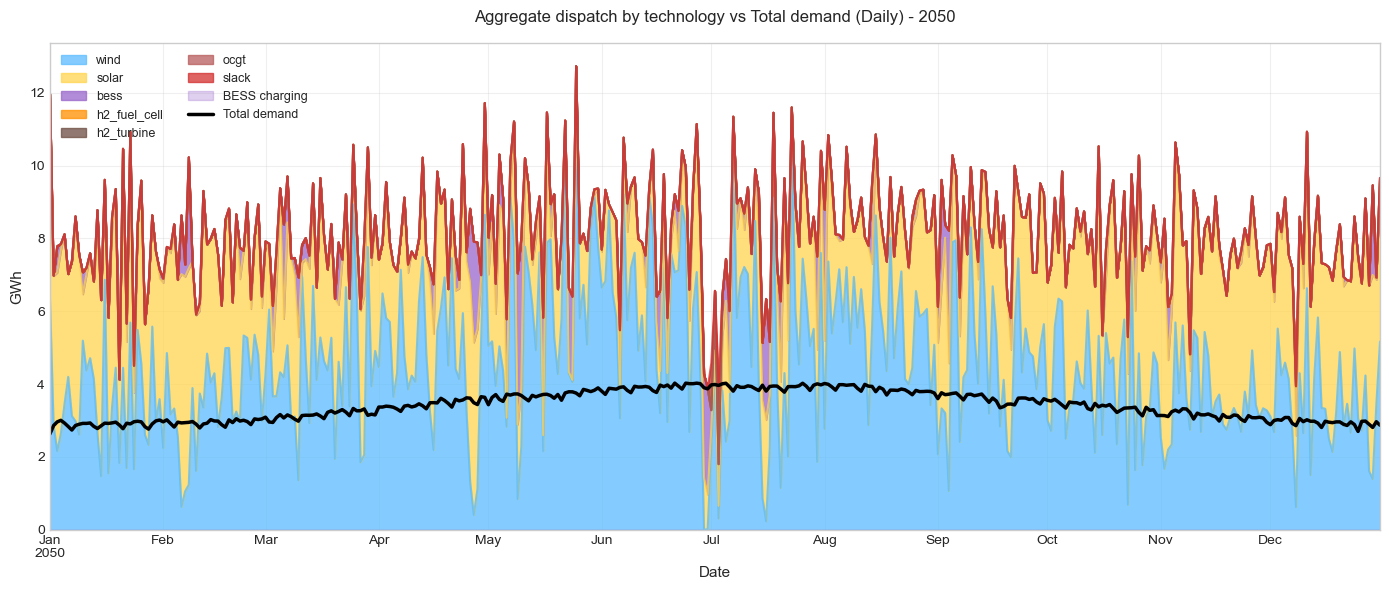

In [263]:
# --- Daily aggregated dispatch ---
dispatch_daily = dispatch_plot.resample('D').sum() / 1e3  # Convert MWh -> GWh
total_load_daily = total_load.resample('D').sum() / 1e3
bess_charge_daily = bess_charge.resample('D').sum() / 1e3 if bess_charge is not None else None

fig_d, ax_d = plt.subplots(figsize=(14, 6))
dispatch_daily.plot.area(ax=ax_d, alpha=0.75, legend=True, color=tech_colors)

if bess_charge_daily is not None:
    ax_d.fill_between(bess_charge_daily.index, 0, -bess_charge_daily, alpha=0.3,
                       color=TECH_COLORS['bess'], label='BESS charging')

total_load_daily.plot(ax=ax_d, color='black', linewidth=2.5, label='Total demand', legend=True)

ax_d.set_title(f'Aggregate dispatch by technology vs Total demand (Daily) - {analysis_year}', fontsize=12, pad=15)
ax_d.set_ylabel('GWh', fontsize=11)
ax_d.set_xlabel('Date', fontsize=11)
ax_d.legend(loc='upper left', ncol=2, fontsize=9)
ax_d.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

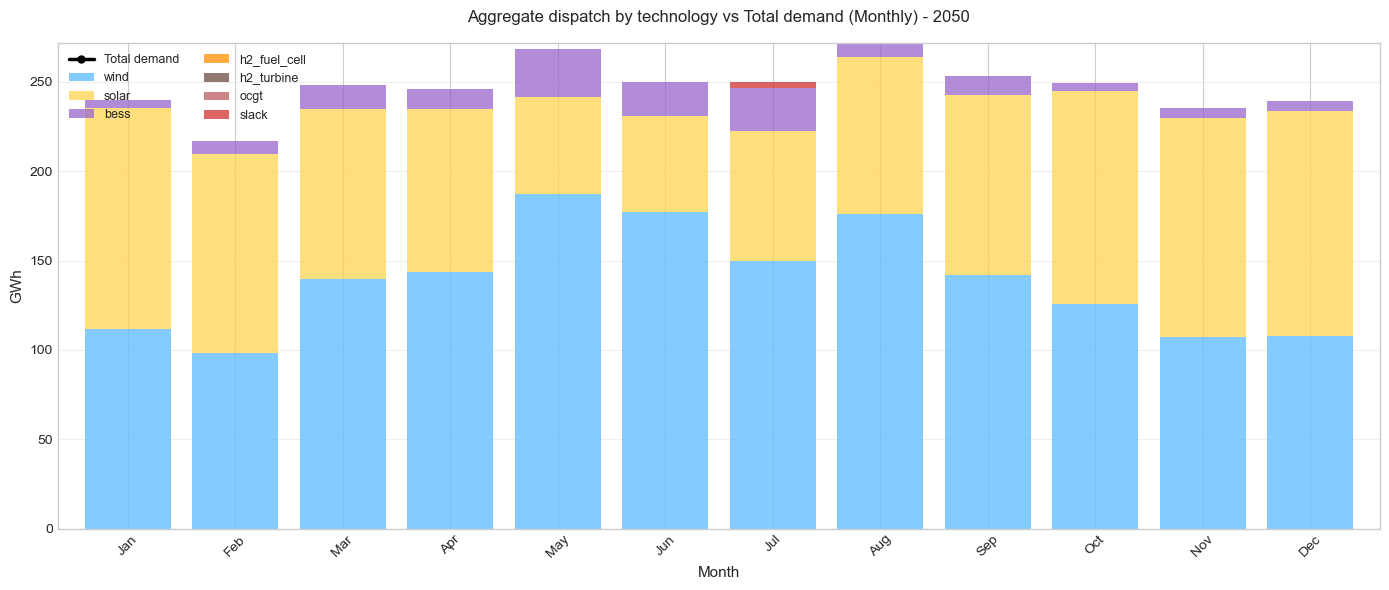

In [264]:
# --- Monthly aggregated dispatch ---
dispatch_monthly = dispatch_plot.resample('ME').sum() / 1e3  # Convert MWh -> GWh
total_load_monthly = total_load.resample('ME').sum() / 1e3
bess_charge_monthly = bess_charge.resample('ME').sum() / 1e3 if bess_charge is not None else None

fig_m, ax_m = plt.subplots(figsize=(14, 6))
dispatch_monthly.plot.bar(ax=ax_m, stacked=True, alpha=0.75, color=tech_colors, width=0.8)

#if bess_charge_monthly is not None:
#    ax_m.bar(range(len(bess_charge_monthly)), -bess_charge_monthly.values, alpha=0.3,
#             color=TECH_COLORS['bess'], label='BESS charging', width=0.8)

ax_m.plot(range(len(total_load_monthly)), total_load_monthly.values, color='black',
          linewidth=2.5, marker='o', markersize=5, label='Total demand')

ax_m.set_title(f'Aggregate dispatch by technology vs Total demand (Monthly) - {analysis_year}', fontsize=12, pad=15)
ax_m.set_ylabel('GWh', fontsize=11)
ax_m.set_xlabel('Month', fontsize=11)
ax_m.set_xticklabels([d.strftime('%b') for d in dispatch_monthly.index], rotation=45)
ax_m.legend(loc='upper left', ncol=2, fontsize=9)
ax_m.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

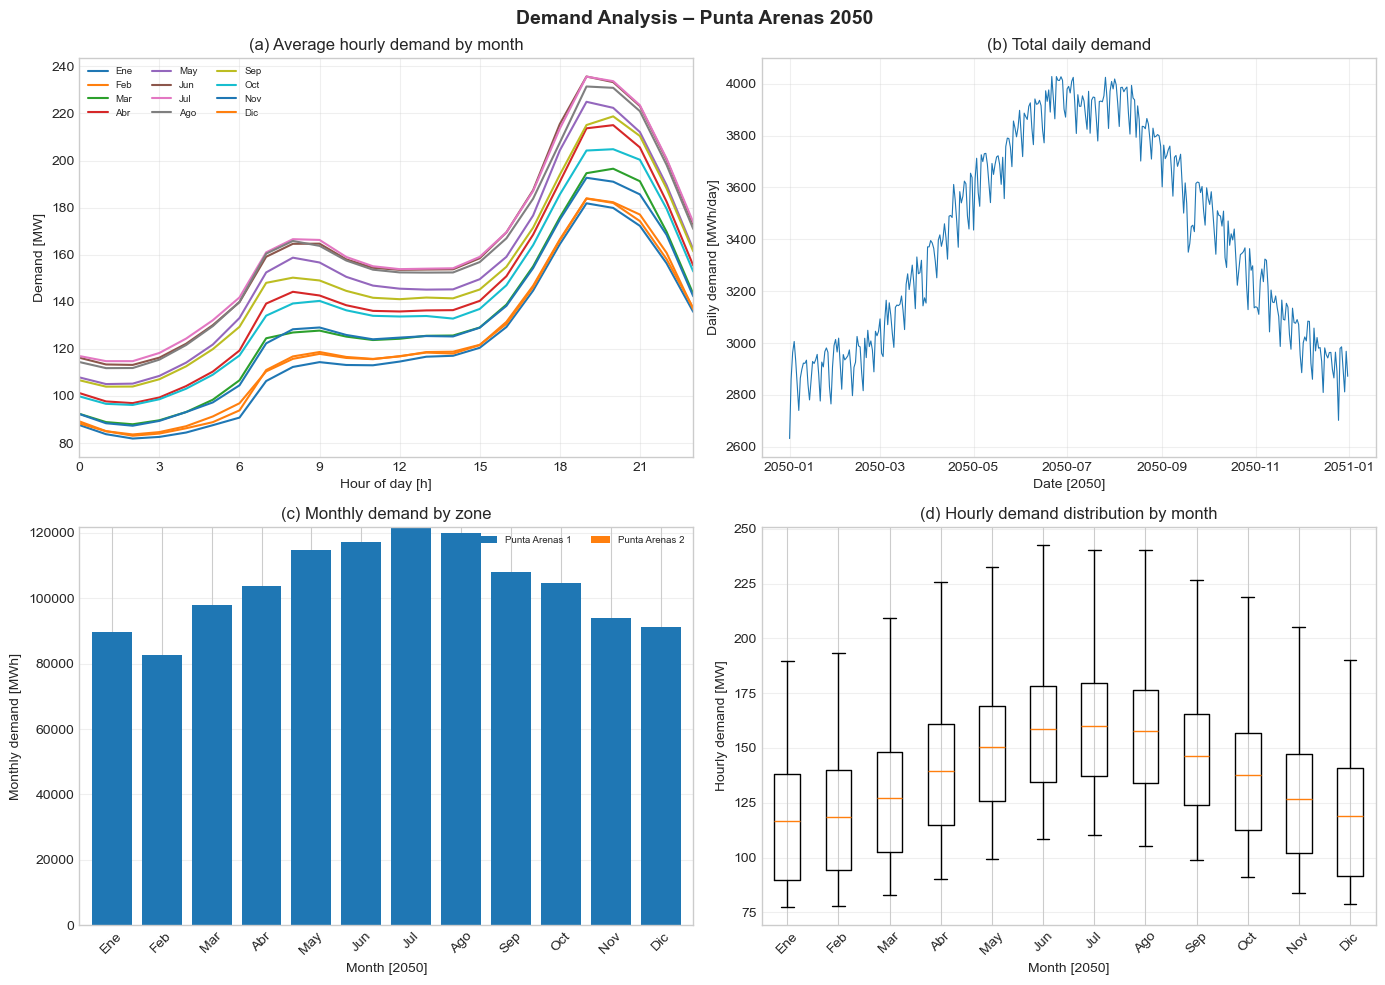

In [265]:
# ── Demand analysis (similar to demand_PArenas.py) ───────────────────────────
months_es = {1: "Ene", 2: "Feb", 3: "Mar", 4: "Abr", 5: "May", 6: "Jun",
             7: "Jul", 8: "Ago", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dic"}

demand_ts = total_load.copy()
demand_ts.index = pd.to_datetime(demand_ts.index)
demand_month = demand_ts.index.month
demand_hour = demand_ts.index.hour

fig_dem, axes_dem = plt.subplots(2, 2, figsize=(14, 10))
fig_dem.suptitle(f"Demand Analysis – {base_case_name.replace('_', ' ').title()} {analysis_year}",
                 fontsize=14, fontweight="bold")

# --- (a) Average hourly demand curve by month ---
ax_a = axes_dem[0, 0]
for m in sorted(demand_ts.index.month.unique()):
    mask = demand_month == m
    hourly_avg = demand_ts[mask].groupby(demand_hour[mask]).mean()
    ax_a.plot(hourly_avg.index, hourly_avg.values, label=months_es.get(m, m))
ax_a.set_xlabel("Hour of day [h]")
ax_a.set_ylabel("Demand [MW]")
ax_a.set_title("(a) Average hourly demand by month")
ax_a.set_xlim(0, 23)
ax_a.set_xticks(range(0, 24, 3))
ax_a.legend(fontsize=7, ncol=3)
ax_a.grid(True, alpha=0.3)

# --- (b) Daily total demand over the year ---
ax_b = axes_dem[0, 1]
demand_daily_mwh = demand_ts.resample('D').sum()  # MWh/day
ax_b.plot(demand_daily_mwh.index, demand_daily_mwh.values, linewidth=0.8)
ax_b.set_xlabel(f"Date [{analysis_year}]")
ax_b.set_ylabel("Daily demand [MWh/day]")
ax_b.set_title("(b) Total daily demand")
ax_b.grid(True, alpha=0.3)

# --- (c) Monthly demand by zone (stacked bar) ---
ax_c = axes_dem[1, 0]
load_by_zone = load.copy()
load_by_zone.index = pd.to_datetime(load_by_zone.index)
load_by_zone['month'] = load_by_zone.index.month
monthly_by_zone = load_by_zone.groupby('month').sum()  # MWh per month
monthly_by_zone.index = [months_es.get(m, m) for m in monthly_by_zone.index]
# Simplify column names
monthly_by_zone.columns = [c.replace('elec_', '').replace('_', ' ').title() for c in monthly_by_zone.columns]
monthly_by_zone.plot(kind="bar", stacked=True, ax=ax_c, legend=True, width=0.8)
ax_c.set_xlabel(f"Month [{analysis_year}]")
ax_c.set_ylabel("Monthly demand [MWh]")
ax_c.set_title("(c) Monthly demand by zone")
ax_c.legend(fontsize=7, ncol=2, loc="upper right")
ax_c.tick_params(axis="x", rotation=45)
ax_c.grid(True, alpha=0.3, axis="y")

# --- (d) Boxplot of hourly demand by month ---
ax_d = axes_dem[1, 1]
data_box = [demand_ts[demand_month == m].values for m in sorted(demand_ts.index.month.unique())]
labels_box = [months_es.get(m, m) for m in sorted(demand_ts.index.month.unique())]
ax_d.boxplot(data_box, labels=labels_box, showfliers=False)
ax_d.set_xlabel(f"Month [{analysis_year}]")
ax_d.set_ylabel("Hourly demand [MW]")
ax_d.set_title("(d) Hourly demand distribution by month")
ax_d.tick_params(axis="x", rotation=45)
ax_d.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()


=== ANNUAL CO2 EMISSIONS [tCO2] ===


,ocgt
2025,147381.46


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


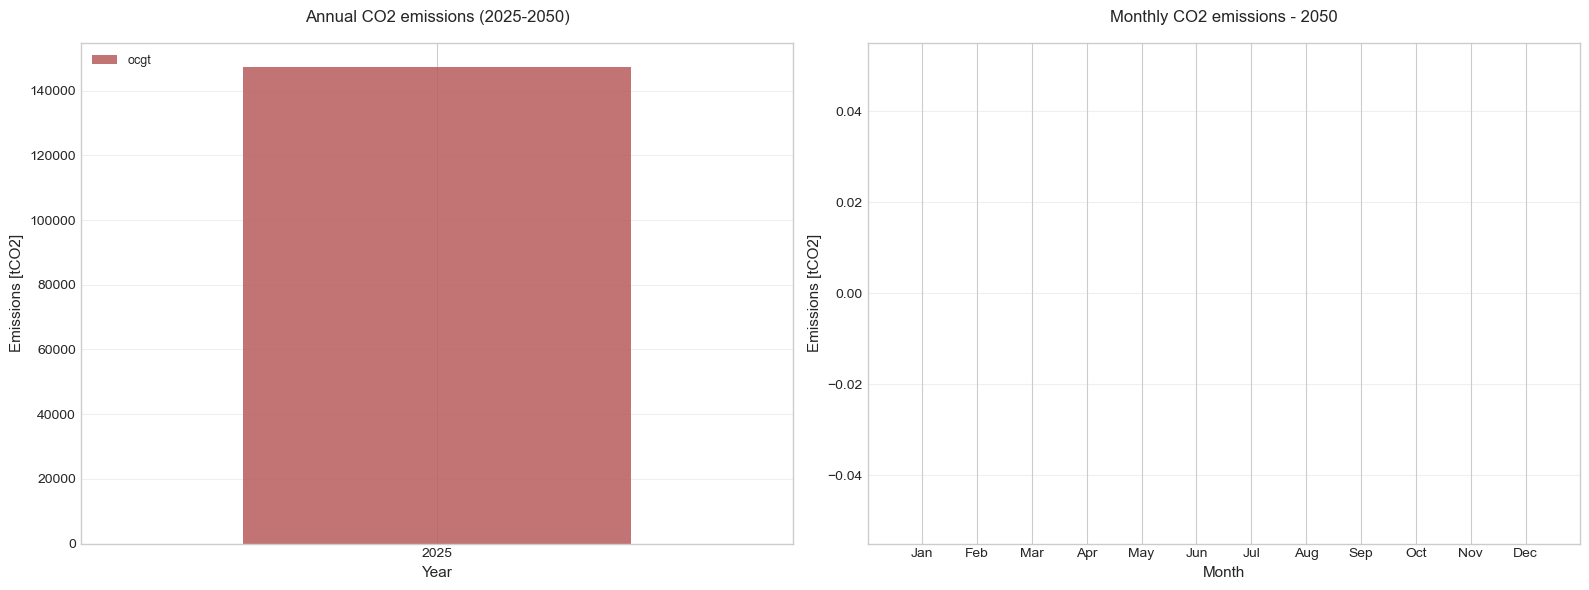


=== EMISSION INTENSITY [tCO2/MWh] ===
2025: 147381.5 tCO2 | intensity = 0.5316 tCO2/MWh | status=ok, condition=optimal
2050: 0.0 tCO2 | intensity = 0.0000 tCO2/MWh | status=ok, condition=optimal


In [266]:
# CO2 emissions using native emission factors loaded into PyPSA (carrier.co2_emissions)
import numpy as np
import pandas as pd

annual_emissions_total = {}
annual_emissions_by_carrier = {}
annual_loads = {}
monthly_emissions_detail = None
year_status = {}

for year in years:
    net = all_results[year]['network']
    status = str(all_results[year].get('status', 'unknown')).lower()
    condition = str(all_results[year].get('condition', 'unknown')).lower()
    year_status[year] = (status, condition)

    # Annual total demand
    year_load = all_results[year]['load'].sum(axis=1)
    annual_loads[year] = float(year_load.sum())

    # If no usable solution, record zero and continue
    if status not in {'ok', 'optimal'} and condition not in {'optimal', 'feasible'}:
        annual_emissions_total[year] = 0.0
        annual_emissions_by_carrier[year] = {}
        if year == detailed_year:
            monthly_emissions_detail = pd.Series(dtype=float)
        continue

    # Emission factors by carrier [tCO2/MWh_th]
    carrier_factors = (
        net.carriers['co2_emissions'] if 'co2_emissions' in net.carriers.columns
        else pd.Series(dtype=float)
    )
    carrier_factors = carrier_factors.fillna(0.0)

    # Align dispatch to all generators to avoid KeyError
    dispatch = net.generators_t.p.reindex(columns=net.generators.index, fill_value=0.0)

    # Electrical emission factor per generator: (tCO2/MWh_th) / efficiency = tCO2/MWh_el
    gen_carrier = net.generators['carrier'].astype(str)
    gen_eff = net.generators['efficiency'].replace(0, np.nan).fillna(1.0)
    gen_emission_factor_el = gen_carrier.map(carrier_factors).fillna(0.0) / gen_eff
    gen_emission_factor_el = gen_emission_factor_el.fillna(0.0)

    emissions_by_gen_ts = dispatch.multiply(gen_emission_factor_el, axis=1)
    total_emissions_year = float(emissions_by_gen_ts.to_numpy().sum())
    annual_emissions_total[year] = total_emissions_year

    # Aggregation by carrier
    emissions_by_carrier_year = {}
    for carrier in sorted(gen_carrier.unique()):
        cols = gen_carrier.index[gen_carrier == carrier]
        value = float(emissions_by_gen_ts[cols].to_numpy().sum()) if len(cols) > 0 else 0.0
        if value > 0:
            emissions_by_carrier_year[carrier] = value
    annual_emissions_by_carrier[year] = emissions_by_carrier_year

    if year == detailed_year:
        monthly_emissions_detail = emissions_by_gen_ts.sum(axis=1).resample('ME').sum()

# Output DataFrames
emissions_df = pd.DataFrame.from_dict(annual_emissions_by_carrier, orient='index').fillna(0.0).sort_index()
total_emissions_series = pd.Series(annual_emissions_total).sort_index()

print('\n=== ANNUAL CO2 EMISSIONS [tCO2] ===')
display(emissions_df.round(2) if not emissions_df.empty else pd.DataFrame(index=years))

emissions_intensity = pd.Series({
    year: (total_emissions_series.loc[year] / annual_loads[year]) if annual_loads[year] > 0 else 0.0
    for year in total_emissions_series.index
})

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

if not emissions_df.empty and emissions_df.sum().sum() > 0:
    emission_colors = [TECH_COLORS.get(t, '#666666') for t in emissions_df.columns]
    emissions_df.plot.bar(ax=axes[0], stacked=True, color=emission_colors, alpha=0.85, width=0.6)
    axes[0].legend(loc='upper left', fontsize=9)
else:
    total_emissions_series.plot.bar(ax=axes[0], color='#666666', alpha=0.85, width=0.6)
    axes[0].legend().remove() if axes[0].get_legend() is not None else None

axes[0].set_title(f'Annual CO2 emissions ({years[0]}-{years[-1]})', fontsize=12, pad=15)
axes[0].set_ylabel('Emissions [tCO2]', fontsize=11)
axes[0].set_xlabel('Year', fontsize=11)
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

if monthly_emissions_detail is not None and len(monthly_emissions_detail) > 0:
    month_labels = [ts.strftime('%b') for ts in monthly_emissions_detail.index]
    axes[1].bar(month_labels, monthly_emissions_detail.values, color=TECH_COLORS.get('ocgt', '#666666'), alpha=0.85)
    axes[1].set_ylabel('Emissions [tCO2]', fontsize=11)
    axes[1].set_xlabel('Month', fontsize=11)
    axes[1].grid(True, alpha=0.3, axis='y')
else:
    axes[1].text(0.5, 0.5, 'No emissions or infeasible year', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_axis_off()

axes[1].set_title(f'Monthly CO2 emissions - {detailed_year}', fontsize=12, pad=15)

plt.tight_layout()
plt.show()

print('\n=== EMISSION INTENSITY [tCO2/MWh] ===')
for year in total_emissions_series.index:
    total_emissions = total_emissions_series.loc[year]
    status, condition = year_status[year]
    print(f"{year}: {total_emissions:.1f} tCO2 | intensity = {emissions_intensity.loc[year]:.4f} tCO2/MWh | status={status}, condition={condition}")

if detailed_year in emissions_df.index and emissions_df.loc[detailed_year].sum() > 0:
    print(f'\n=== DETAIL {detailed_year} ===')
    for tech, value in emissions_df.loc[detailed_year].items():
        if value > 0:
            print(f'{tech}: {value:.1f} tCO2')

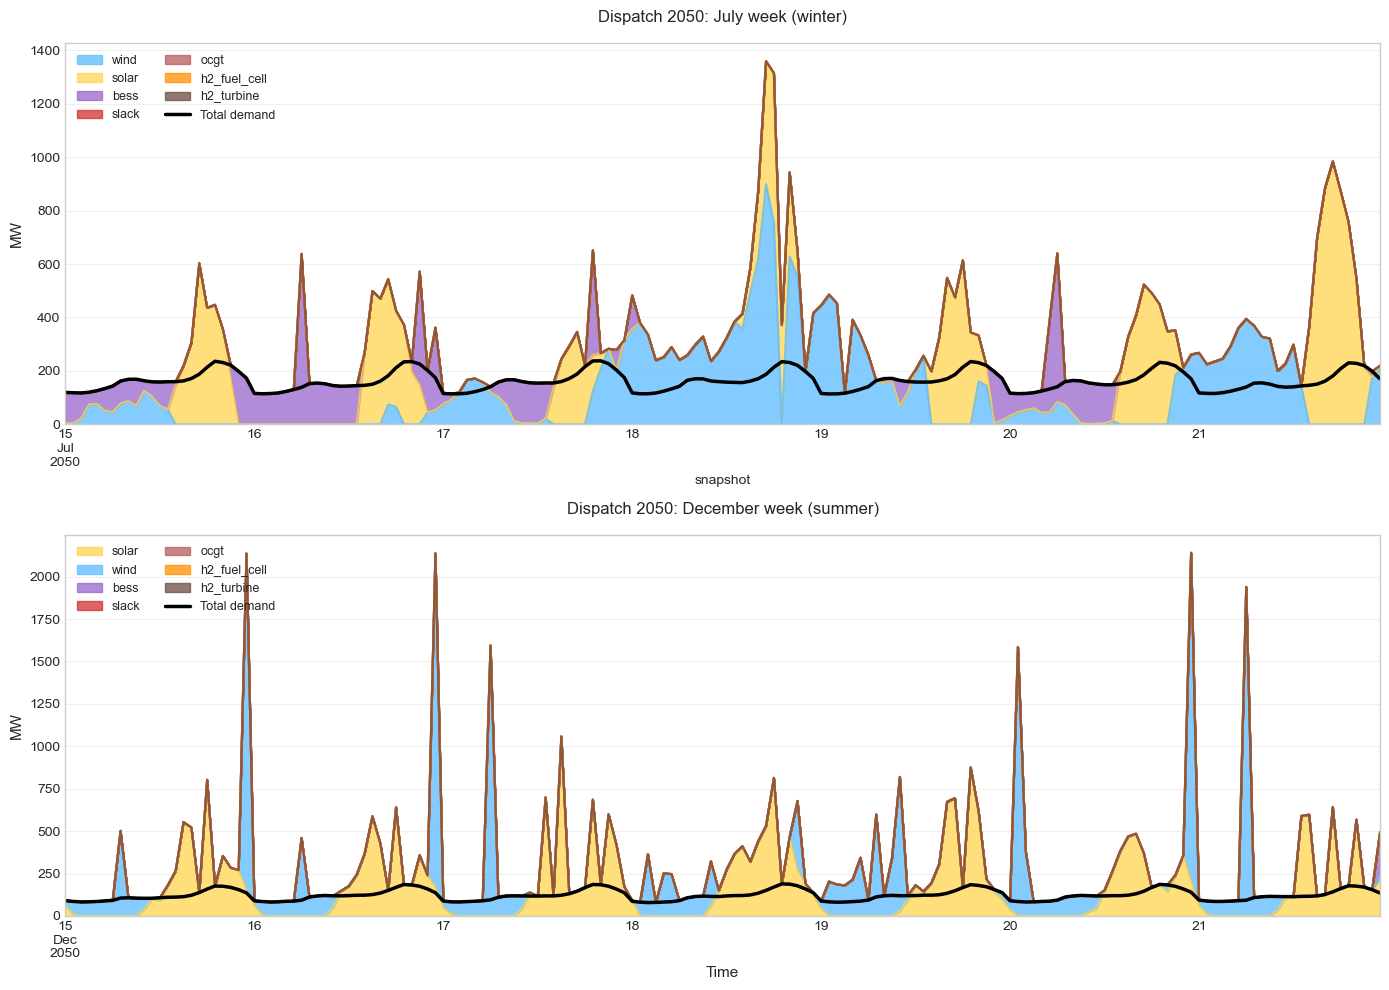


=== JULY vs DECEMBER COMPARISON (2050) ===

July (winter):
  Avg demand: 162.3 MW | peak: 237.8 MW
  wind avg: 130.3 MW
  solar avg: 119.7 MW
  bess avg: 55.0 MW
  slack avg: 0.0 MW
  ocgt avg: 0.0 MW
  h2_fuel_cell avg: 0.0 MW
  h2_turbine avg: 0.0 MW

December (summer):
  Avg demand: 122.1 MW | peak: 188.8 MW
  solar avg: 173.6 MW
  wind avg: 132.5 MW
  bess avg: 1.6 MW
  slack avg: 0.0 MW
  ocgt avg: 0.0 MW
  h2_fuel_cell avg: 0.0 MW
  h2_turbine avg: 0.0 MW


In [267]:
# Weekly dispatch zoom: July (winter) and December (summer)
import pandas as pd

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

# Color fallback in case this cell runs without cell 2
if 'TECH_COLORS' not in globals():
    TECH_COLORS = {
        'wind': '#5bbcff',
        'solar': '#ffd54f',
        'ocgt': '#b85c5c',
        'bess': '#9966cc',
        'h2_fuel_cell': '#ff8f00',
        'h2_turbine': '#6d4c41',
        'slack': '#d32f2f',
        'natural_gas': '#bdbdbd',
        'gas': '#bdbdbd',
    }

# Ensure DatetimeIndex to avoid empty windows from format mismatch
if not isinstance(dispatch_by_tech.index, pd.DatetimeIndex):
    dispatch_by_tech = dispatch_by_tech.copy()
    dispatch_by_tech.index = pd.to_datetime(dispatch_by_tech.index)

if not isinstance(total_load.index, pd.DatetimeIndex):
    total_load = total_load.copy()
    total_load.index = pd.to_datetime(total_load.index)

analysis_year = int(total_load.index[0].year)

def _select_week(data, month, take='first'):
    """Return a representative week from the requested month with robust fallback."""
    start = f"{analysis_year}-{month:02d}-15"
    end = f"{analysis_year}-{month:02d}-21 23:00"
    window = data.loc[start:end]

    if window.empty:
        month_data = data[data.index.month == month]
        if len(month_data) >= 24 * 7:
            window = month_data.iloc[:24 * 7] if take == 'first' else month_data.iloc[-24 * 7:]
        else:
            window = month_data

    if window.empty:
        fallback_rows = min(len(data), 24 * 7)
        window = data.iloc[:fallback_rows] if take == 'first' else data.iloc[-fallback_rows:]

    return window

# July week (winter in Southern Hemisphere)
dispatch_july = _select_week(dispatch_by_tech, month=7, take='first')
load_july = _select_week(total_load.to_frame('load'), month=7, take='first')['load']

# Sort columns by average contribution (highest first)
col_order_july = dispatch_july.mean().sort_values(ascending=False).index
dispatch_july_sorted = dispatch_july[col_order_july]
july_colors = [TECH_COLORS.get(t, '#999999') for t in col_order_july]

if dispatch_july_sorted.empty:
    raise ValueError('No dispatch data available for the July window.')

dispatch_july_sorted.plot.area(ax=axes[0], alpha=0.75, legend=True, color=july_colors)
load_july.plot(ax=axes[0], color='black', linewidth=2.5, label='Total demand', legend=True)
axes[0].set_title(f'Dispatch {analysis_year}: July week (winter)', fontsize=12, pad=15)
axes[0].set_ylabel('MW', fontsize=11)
axes[0].legend(loc='upper left', ncol=2, fontsize=9)
axes[0].grid(True, alpha=0.3)

# December week (summer in Southern Hemisphere)
dispatch_dec = _select_week(dispatch_by_tech, month=12, take='last')
load_dec = _select_week(total_load.to_frame('load'), month=12, take='last')['load']

# Sort columns by average contribution (highest first)
col_order_dec = dispatch_dec.mean().sort_values(ascending=False).index
dispatch_dec_sorted = dispatch_dec[col_order_dec]
dec_colors = [TECH_COLORS.get(t, '#999999') for t in col_order_dec]

if dispatch_dec_sorted.empty:
    raise ValueError('No dispatch data available for the December window.')

dispatch_dec_sorted.plot.area(ax=axes[1], alpha=0.75, legend=True, color=dec_colors)
load_dec.plot(ax=axes[1], color='black', linewidth=2.5, label='Total demand', legend=True)
axes[1].set_title(f'Dispatch {analysis_year}: December week (summer)', fontsize=12, pad=15)
axes[1].set_ylabel('MW', fontsize=11)
axes[1].set_xlabel('Time', fontsize=11)
axes[1].legend(loc='upper left', ncol=2, fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Comparative statistics
print(f"\n=== JULY vs DECEMBER COMPARISON ({analysis_year}) ===")
print(f"\nJuly (winter):")
print(f"  Avg demand: {load_july.mean():.1f} MW | peak: {load_july.max():.1f} MW")
for tech in col_order_july:
    print(f"  {tech} avg: {dispatch_july[tech].mean():.1f} MW")

print(f"\nDecember (summer):")
print(f"  Avg demand: {load_dec.mean():.1f} MW | peak: {load_dec.max():.1f} MW")
for tech in col_order_dec:
    print(f"  {tech} avg: {dispatch_dec[tech].mean():.1f} MW")

No electrical interconnections (link_*) found in the network.


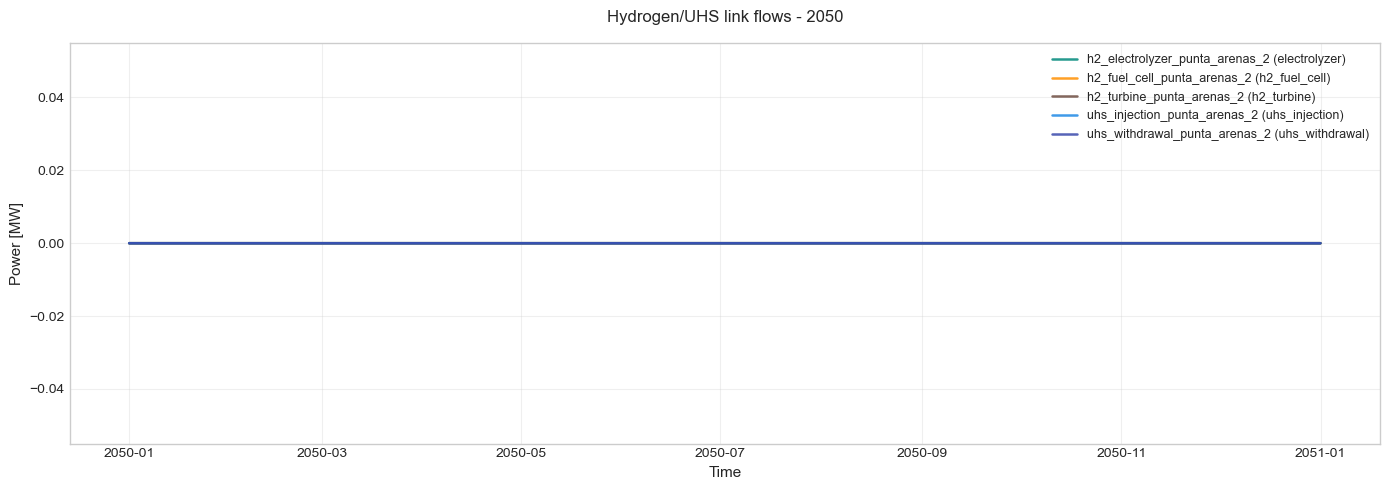


=== H2/UHS FLOWS (2050) ===
h2_electrolyzer_punta_arenas_2 (electrolyzer):  avg=0.0 MW | max=0.0 MW | min=0.0 MW
h2_fuel_cell_punta_arenas_2 (h2_fuel_cell):  avg=0.0 MW | max=0.0 MW | min=0.0 MW
h2_turbine_punta_arenas_2 (h2_turbine):  avg=0.0 MW | max=0.0 MW | min=0.0 MW
uhs_injection_punta_arenas_2 (uhs_injection):  avg=0.0 MW | max=0.0 MW | min=0.0 MW
uhs_withdrawal_punta_arenas_2 (uhs_withdrawal):  avg=0.0 MW | max=0.0 MW | min=0.0 MW


In [268]:
# Link flows: electrical interconnections and H2/UHS links (separate plots)
analysis_year = detailed_year
links_flow = n.links_t.p0.copy()

# Separate by type
elec_links = [c for c in links_flow.columns if str(c).startswith('link_')]
h2_uhs_carriers = {'electrolyzer', 'h2_fuel_cell', 'h2_turbine', 'uhs_injection', 'uhs_withdrawal'}
h2_links = [
    c for c in links_flow.columns
    if c in n.links.index and n.links.loc[c, 'carrier'] in h2_uhs_carriers
]

# ── Figure 1: electrical interconnections (Y-axis capped at 0-100 MW) ──────
if elec_links:
    fig, ax = plt.subplots(figsize=(14, 5))
    for link in elec_links:
        ax.plot(links_flow.index, links_flow[link], linewidth=2, label=link, alpha=0.85)
    ax.set_title(f'Electrical interconnection flows - {analysis_year} (zoom 0-100 MW)',
                 fontsize=12, pad=15)
    ax.set_ylabel('Power [MW]', fontsize=11)
    ax.set_xlabel('Time', fontsize=11)
    ax.set_ylim(0, 100)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'\n=== ELECTRICAL FLOWS ({analysis_year}) ===')
    for link in elec_links:
        f = links_flow[link]
        print(f'{link}:  avg={f.mean():.1f} MW | max={f.max():.1f} MW | min={f.min():.1f} MW')
else:
    print('No electrical interconnections (link_*) found in the network.')

# ── Figure 2: H2/UHS links ────────────────────────────────────────────────
if h2_links:
    h2_color_map = {
        'electrolyzer':    TECH_COLORS.get('electrolyzer', '#00897b'),
        'h2_fuel_cell':    TECH_COLORS.get('h2_fuel_cell', '#ff8f00'),
        'h2_turbine':      TECH_COLORS.get('h2_turbine',   '#6d4c41'),
        'uhs_injection':   TECH_COLORS.get('uhs_injection', '#1e88e5'),
        'uhs_withdrawal':  TECH_COLORS.get('uhs_withdrawal', '#3949ab'),
    }
    fig, ax = plt.subplots(figsize=(14, 5))
    for link in h2_links:
        carrier = n.links.loc[link, 'carrier']
        ax.plot(
            links_flow.index,
            links_flow[link],
            linewidth=1.8,
            label=f"{link} ({carrier})",
            alpha=0.85,
            color=h2_color_map.get(carrier, '#999')
        )
    ax.set_title(f'Hydrogen/UHS link flows - {analysis_year}', fontsize=12, pad=15)
    ax.set_ylabel('Power [MW]', fontsize=11)
    ax.set_xlabel('Time', fontsize=11)
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'\n=== H2/UHS FLOWS ({analysis_year}) ===')
    for link in h2_links:
        carrier = n.links.loc[link, 'carrier']
        f = links_flow[link]
        print(f'{link} ({carrier}):  avg={f.mean():.1f} MW | max={f.max():.1f} MW | min={f.min():.1f} MW')
else:
    print('No active H2/UHS links in the network.')


=== INSTALLED BESS CAPACITIES (2050) ===


,bus,p_nom_opt,max_hours,energy_capacity_MWh
name,,,,
bess_4h_punta_arenas_2,elec_punta_arenas_2,1500.0,4.0,6000.0
bess_2h_punta_arenas_2,elec_punta_arenas_2,500.0,2.0,1000.0


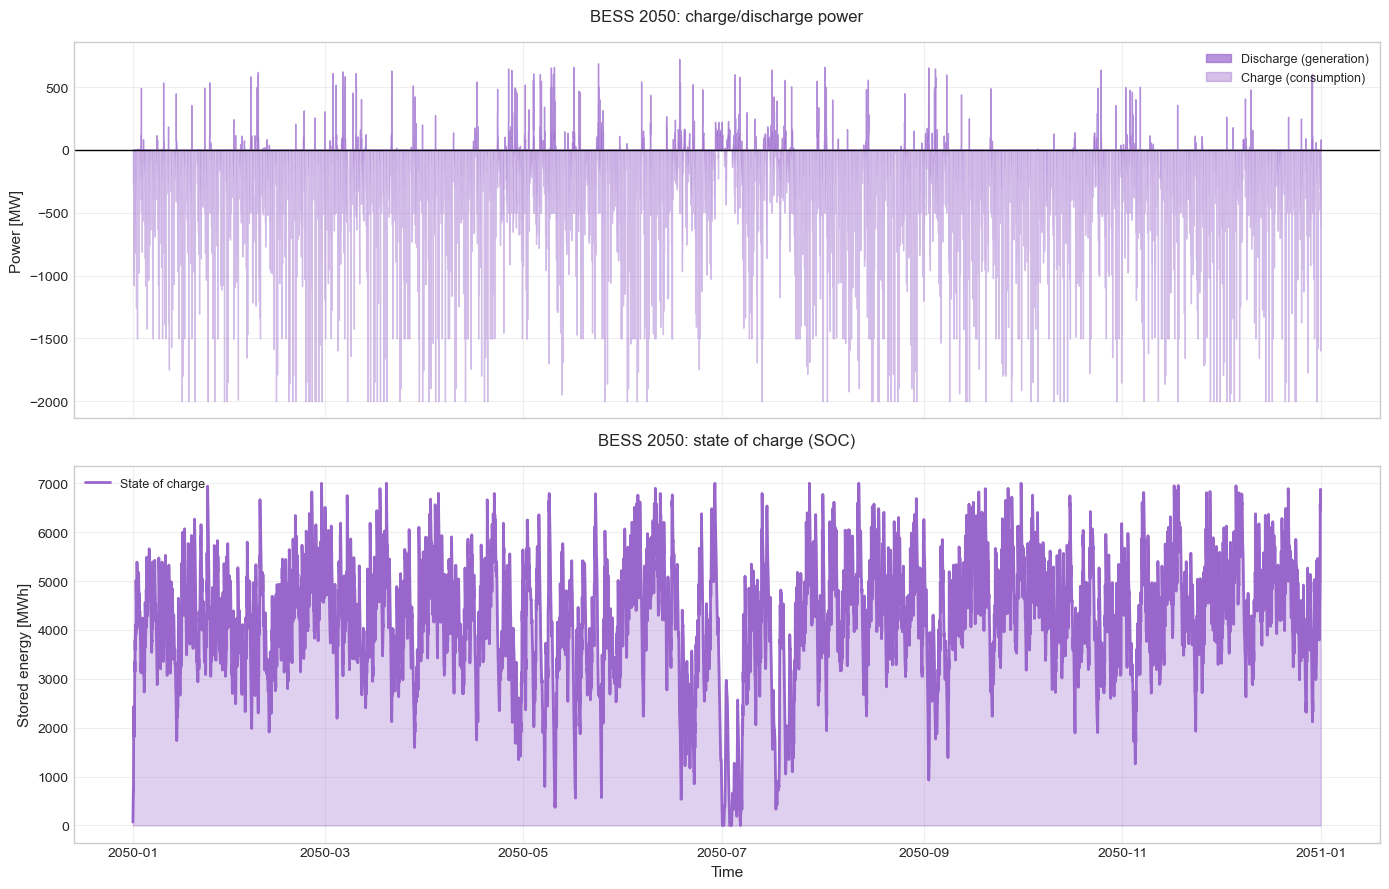


=== BESS OPERATION STATISTICS (2050) ===
Total installed capacity: 2000.00 MW
Total energy capacity: 7000.00 MWh

Power:
  Peak discharge: 723.77 MW
  Peak charge: 2000.00 MW
  Avg discharge: 151.72 MW
  Avg charge: 459.37 MW
  Avg net power: -180.54 MW

Energy:
  SOC max: 7000.00 MWh
  SOC avg: 4208.58 MWh
  SOC min: 0.00 MWh

Annual energy:
  Charged: 1723107 MWh
  Discharged: 141555 MWh
  Round-trip efficiency: 8.2%


In [269]:
# BESS (Battery Energy Storage System) analysis
analysis_year = detailed_year

if len(n.storage_units) > 0:
    print(f"\n=== INSTALLED BESS CAPACITIES ({analysis_year}) ===")
    bess_caps = n.storage_units[['bus', 'p_nom_opt', 'max_hours']].copy()
    bess_caps['energy_capacity_MWh'] = bess_caps['p_nom_opt'] * bess_caps['max_hours']
    bess_caps = bess_caps.sort_values('p_nom_opt', ascending=False)
    display(bess_caps)

    # Separate charge and discharge per unit before aggregating to avoid cancellations
    bess_power_by_unit = n.storage_units_t.p.copy()
    bess_discharge = bess_power_by_unit.clip(lower=0).sum(axis=1)
    bess_charge = -bess_power_by_unit.clip(upper=0).sum(axis=1)
    bess_net_power = bess_discharge - bess_charge
    bess_soc = n.storage_units_t.state_of_charge.sum(axis=1)

    # Color fallback
    if 'TECH_COLORS' not in globals():
        TECH_COLORS = {'bess': '#9966cc'}

    fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

    # Plot 1: Aggregate charge/discharge power
    axes[0].fill_between(bess_discharge.index, 0, bess_discharge,
                         color=TECH_COLORS.get('bess', '#9966cc'),
                         alpha=0.7, label='Discharge (generation)', step='mid')
    axes[0].fill_between(bess_charge.index, 0, -bess_charge,
                         color=TECH_COLORS.get('bess', '#9966cc'),
                         alpha=0.4, label='Charge (consumption)', step='mid')
    axes[0].axhline(y=0, color='black', linewidth=1)
    axes[0].set_title(f'BESS {analysis_year}: charge/discharge power', fontsize=12, pad=15)
    axes[0].set_ylabel('Power [MW]', fontsize=11)
    axes[0].legend(loc='best', fontsize=9)
    axes[0].grid(True, alpha=0.3)

    # Plot 2: State of charge (SOC)
    axes[1].plot(bess_soc.index, bess_soc, color=TECH_COLORS.get('bess', '#9966cc'),
                 linewidth=2, label='State of charge')
    axes[1].fill_between(bess_soc.index, 0, bess_soc,
                         color=TECH_COLORS.get('bess', '#9966cc'), alpha=0.3)
    axes[1].set_title(f'BESS {analysis_year}: state of charge (SOC)', fontsize=12, pad=15)
    axes[1].set_ylabel('Stored energy [MWh]', fontsize=11)
    axes[1].set_xlabel('Time', fontsize=11)
    axes[1].legend(loc='best', fontsize=9)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Statistics
    print(f"\n=== BESS OPERATION STATISTICS ({analysis_year}) ===")
    print(f"Total installed capacity: {bess_caps['p_nom_opt'].sum():.2f} MW")
    print(f"Total energy capacity: {bess_caps['energy_capacity_MWh'].sum():.2f} MWh")
    print(f"\nPower:")
    print(f"  Peak discharge: {bess_discharge.max():.2f} MW")
    print(f"  Peak charge: {bess_charge.max():.2f} MW")
    print(f"  Avg discharge: {bess_discharge[bess_discharge > 0].mean():.2f} MW")
    print(f"  Avg charge: {bess_charge[bess_charge > 0].mean():.2f} MW")
    print(f"  Avg net power: {bess_net_power.mean():.2f} MW")
    print(f"\nEnergy:")
    print(f"  SOC max: {bess_soc.max():.2f} MWh")
    print(f"  SOC avg: {bess_soc.mean():.2f} MWh")
    print(f"  SOC min: {bess_soc.min():.2f} MWh")

    # Cycle analysis
    charge_energy = bess_charge.sum()
    discharge_energy = bess_discharge.sum()
    print(f"\nAnnual energy:")
    print(f"  Charged: {charge_energy:.0f} MWh")
    print(f"  Discharged: {discharge_energy:.0f} MWh")
    print(f"  Round-trip efficiency: {(discharge_energy / charge_energy * 100):.1f}%" if charge_energy > 0 else "  Round-trip efficiency: n/a")
else:
    print(f"No storage units (BESS) in the network for {analysis_year}.")

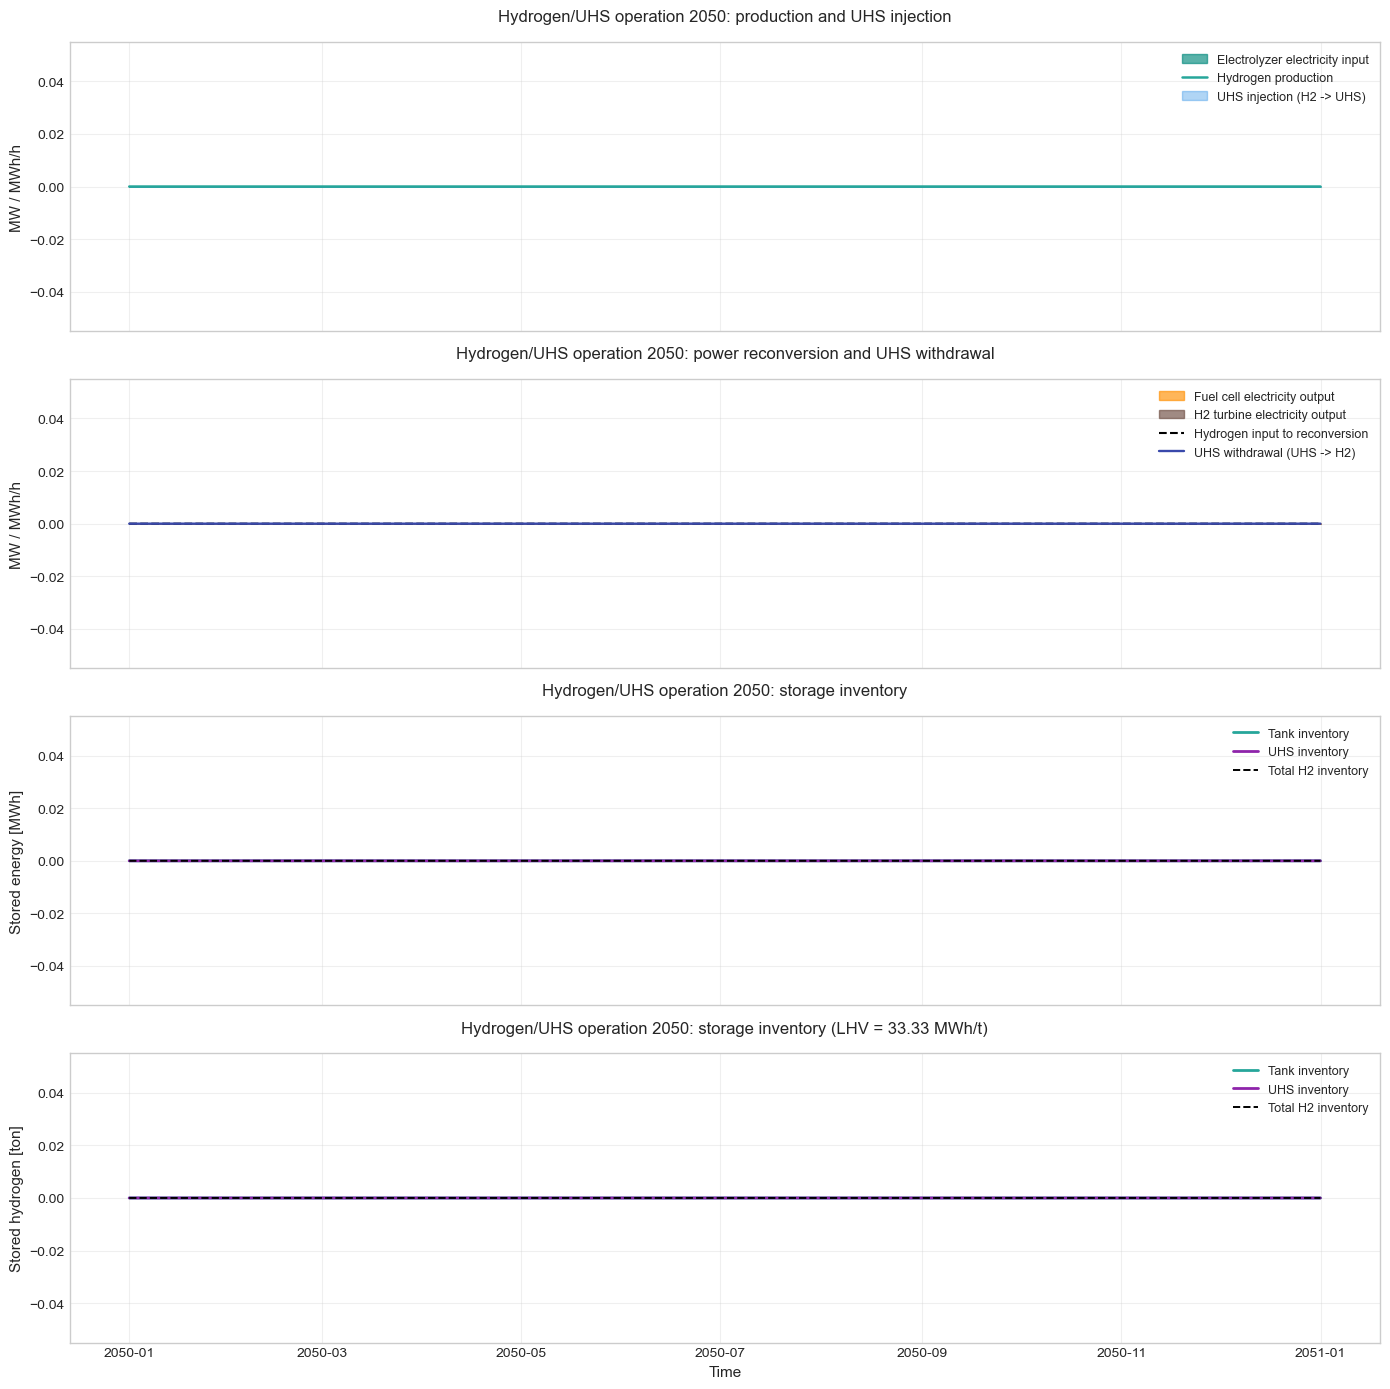


=== HYDROGEN/UHS LINK CAPACITIES (2050) ===


,carrier,bus0,bus1,efficiency,capacity_mw
name,,,,,
h2_electrolyzer_punta_arenas_2,electrolyzer,elec_punta_arenas_2,h2_punta_arenas_2,0.70,0.0
h2_fuel_cell_punta_arenas_2,h2_fuel_cell,h2_punta_arenas_2,elec_punta_arenas_2,0.55,0.0
h2_turbine_punta_arenas_2,h2_turbine,h2_punta_arenas_2,elec_punta_arenas_2,0.45,0.0
uhs_injection_punta_arenas_2,uhs_injection,h2_punta_arenas_2,uhs_punta_arenas_2,0.98,0.0
uhs_withdrawal_punta_arenas_2,uhs_withdrawal,uhs_punta_arenas_2,h2_punta_arenas_2,0.98,0.0



=== HYDROGEN/UHS STORAGE CAPACITIES (2050) ===


,carrier,bus,standing_loss,energy_capacity_mwh
name,,,,
uhs_store_punta_arenas_2,uhs_storage,uhs_punta_arenas_2,0.0001,0.0



=== HYDROGEN/UHS OPERATION STATISTICS (2050) ===
Electrolyzer electricity input: 0 MWh
Hydrogen production: 0 MWh
UHS injection (H2 -> UHS): 0 MWh
UHS withdrawal (UHS -> H2): 0 MWh
Hydrogen input to reconversion: 0 MWh
Electricity from fuel cells: 0 MWh
Electricity from H2 turbines: 0 MWh
Peak tank inventory: 0.00 MWh  (0.00 ton)
Peak UHS inventory: 0.00 MWh  (0.00 ton)
Peak total H2 inventory: 0.00 MWh  (0.00 ton)


In [270]:
# Hydrogen/UHS analysis: conversion and storage
import pandas as pd

analysis_year = detailed_year
hydrogen_link_carriers = ['electrolyzer', 'h2_fuel_cell', 'h2_turbine', 'uhs_injection', 'uhs_withdrawal']
hydrogen_store_carriers = ['hydrogen_storage', 'uhs_storage']

hydrogen_links = n.links[n.links['carrier'].isin(hydrogen_link_carriers)].copy()
hydrogen_stores = n.stores[n.stores['carrier'].isin(hydrogen_store_carriers)].copy()

if hydrogen_links.empty and hydrogen_stores.empty:
    print(
        f"No hydrogen/UHS assets in the network for {analysis_year}. "
        f"enable_hydrogen={all_results[analysis_year].get('enable_hydrogen', True)}."
    )
else:
    if 'TECH_COLORS' not in globals():
        TECH_COLORS = {
            'electrolyzer': '#00897b',
            'h2_fuel_cell': '#ff8f00',
            'h2_turbine': '#6d4c41',
            'hydrogen_storage': '#26a69a',
            'uhs_injection': '#1e88e5',
            'uhs_withdrawal': '#3949ab',
            'uhs_storage': '#8e24aa',
        }

    H2_LHV_MWH_PER_TON = 33.33  # MWh per tonne of H2 (lower heating value)

    def _zero_series() -> pd.Series:
        """Return a zero-valued series aligned with the network snapshots."""
        return pd.Series(0.0, index=n.snapshots)

    def _link_input_series(link_index: pd.Index) -> pd.Series:
        """Aggregate electricity input (p0) for the given link indices."""
        if len(link_index) == 0:
            return _zero_series()
        return n.links_t.p0[link_index].clip(lower=0).sum(axis=1)

    def _link_output_series(link_index: pd.Index) -> pd.Series:
        """Aggregate useful output (p0 * efficiency) for the given link indices."""
        if len(link_index) == 0:
            return _zero_series()
        efficiency = n.links.loc[link_index, 'efficiency'].fillna(1.0)
        dispatch = n.links_t.p0[link_index].clip(lower=0)
        return dispatch.multiply(efficiency, axis=1).sum(axis=1)

    electrolyzer_links = hydrogen_links.index[hydrogen_links['carrier'] == 'electrolyzer']
    fuel_cell_links = hydrogen_links.index[hydrogen_links['carrier'] == 'h2_fuel_cell']
    turbine_links = hydrogen_links.index[hydrogen_links['carrier'] == 'h2_turbine']
    uhs_injection_links = hydrogen_links.index[hydrogen_links['carrier'] == 'uhs_injection']
    uhs_withdrawal_links = hydrogen_links.index[hydrogen_links['carrier'] == 'uhs_withdrawal']

    electrolyzer_power = _link_input_series(electrolyzer_links)
    hydrogen_production = _link_output_series(electrolyzer_links)
    fuel_cell_power = _link_output_series(fuel_cell_links)
    turbine_power = _link_output_series(turbine_links)
    hydrogen_to_power = fuel_cell_power + turbine_power
    hydrogen_reconversion_input = _link_input_series(fuel_cell_links) + _link_input_series(turbine_links)

    uhs_injection_power = _link_input_series(uhs_injection_links)
    uhs_withdrawal_power = _link_output_series(uhs_withdrawal_links)

    tank_stores = hydrogen_stores.index[hydrogen_stores['carrier'] == 'hydrogen_storage']
    uhs_stores = hydrogen_stores.index[hydrogen_stores['carrier'] == 'uhs_storage']

    tank_inventory = _zero_series() if len(tank_stores) == 0 else n.stores_t.e[tank_stores].sum(axis=1)
    uhs_inventory = _zero_series() if len(uhs_stores) == 0 else n.stores_t.e[uhs_stores].sum(axis=1)
    hydrogen_inventory = tank_inventory + uhs_inventory

    # Tonnes conversion
    tank_inventory_ton = tank_inventory / H2_LHV_MWH_PER_TON
    uhs_inventory_ton = uhs_inventory / H2_LHV_MWH_PER_TON
    hydrogen_inventory_ton = hydrogen_inventory / H2_LHV_MWH_PER_TON

    fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

    # Panel 1: H2 production and UHS injection
    axes[0].fill_between(
        electrolyzer_power.index, 0, electrolyzer_power,
        color=TECH_COLORS.get('electrolyzer', '#00897b'), alpha=0.65,
        label='Electrolyzer electricity input', step='mid'
    )
    axes[0].plot(
        hydrogen_production.index, hydrogen_production,
        color=TECH_COLORS.get('hydrogen_storage', '#26a69a'), linewidth=1.8,
        label='Hydrogen production',
    )
    axes[0].fill_between(
        uhs_injection_power.index, 0, uhs_injection_power,
        color=TECH_COLORS.get('uhs_injection', '#1e88e5'), alpha=0.35,
        label='UHS injection (H2 -> UHS)', step='mid'
    )
    axes[0].set_title(f'Hydrogen/UHS operation {analysis_year}: production and UHS injection', fontsize=12, pad=15)
    axes[0].set_ylabel('MW / MWh/h', fontsize=11)
    axes[0].legend(loc='best', fontsize=9)
    axes[0].grid(True, alpha=0.3)

    # Panel 2: Power reconversion and UHS withdrawal
    axes[1].fill_between(
        fuel_cell_power.index, 0, fuel_cell_power,
        color=TECH_COLORS.get('h2_fuel_cell', '#ff8f00'), alpha=0.65,
        label='Fuel cell electricity output', step='mid'
    )
    axes[1].fill_between(
        turbine_power.index, fuel_cell_power, hydrogen_to_power,
        color=TECH_COLORS.get('h2_turbine', '#6d4c41'), alpha=0.65,
        label='H2 turbine electricity output', step='mid'
    )
    axes[1].plot(
        hydrogen_reconversion_input.index, hydrogen_reconversion_input,
        color='black', linewidth=1.5, linestyle='--',
        label='Hydrogen input to reconversion'
    )
    axes[1].plot(
        uhs_withdrawal_power.index, uhs_withdrawal_power,
        color=TECH_COLORS.get('uhs_withdrawal', '#3949ab'), linewidth=1.7,
        label='UHS withdrawal (UHS -> H2)'
    )
    axes[1].set_title(f'Hydrogen/UHS operation {analysis_year}: power reconversion and UHS withdrawal', fontsize=12, pad=15)
    axes[1].set_ylabel('MW / MWh/h', fontsize=11)
    axes[1].legend(loc='best', fontsize=9)
    axes[1].grid(True, alpha=0.3)

    # Panel 3: Storage inventory levels [MWh]
    axes[2].plot(
        tank_inventory.index, tank_inventory,
        color=TECH_COLORS.get('hydrogen_storage', '#26a69a'), linewidth=2,
        label='Tank inventory'
    )
    axes[2].plot(
        uhs_inventory.index, uhs_inventory,
        color=TECH_COLORS.get('uhs_storage', '#8e24aa'), linewidth=2,
        label='UHS inventory'
    )
    axes[2].plot(
        hydrogen_inventory.index, hydrogen_inventory,
        color='black', linewidth=1.4, linestyle='--',
        label='Total H2 inventory'
    )
    axes[2].fill_between(
        tank_inventory.index, 0, tank_inventory,
        color=TECH_COLORS.get('hydrogen_storage', '#26a69a'), alpha=0.2
    )
    axes[2].fill_between(
        uhs_inventory.index, 0, uhs_inventory,
        color=TECH_COLORS.get('uhs_storage', '#8e24aa'), alpha=0.15
    )
    axes[2].set_title(f'Hydrogen/UHS operation {analysis_year}: storage inventory', fontsize=12, pad=15)
    axes[2].set_ylabel('Stored energy [MWh]', fontsize=11)
    axes[2].legend(loc='best', fontsize=9)
    axes[2].grid(True, alpha=0.3)

    # Panel 4: Storage inventory levels [tonnes H2]
    axes[3].plot(
        tank_inventory_ton.index, tank_inventory_ton,
        color=TECH_COLORS.get('hydrogen_storage', '#26a69a'), linewidth=2,
        label='Tank inventory'
    )
    axes[3].plot(
        uhs_inventory_ton.index, uhs_inventory_ton,
        color=TECH_COLORS.get('uhs_storage', '#8e24aa'), linewidth=2,
        label='UHS inventory'
    )
    axes[3].plot(
        hydrogen_inventory_ton.index, hydrogen_inventory_ton,
        color='black', linewidth=1.4, linestyle='--',
        label='Total H2 inventory'
    )
    axes[3].fill_between(
        tank_inventory_ton.index, 0, tank_inventory_ton,
        color=TECH_COLORS.get('hydrogen_storage', '#26a69a'), alpha=0.2
    )
    axes[3].fill_between(
        uhs_inventory_ton.index, 0, uhs_inventory_ton,
        color=TECH_COLORS.get('uhs_storage', '#8e24aa'), alpha=0.15
    )
    axes[3].set_title(f'Hydrogen/UHS operation {analysis_year}: storage inventory (LHV = {H2_LHV_MWH_PER_TON} MWh/t)', fontsize=12, pad=15)
    axes[3].set_ylabel('Stored hydrogen [ton]', fontsize=11)
    axes[3].set_xlabel('Time', fontsize=11)
    axes[3].legend(loc='best', fontsize=9)
    axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Display link capacities
    link_capacity_column = 'p_nom_opt' if 'p_nom_opt' in hydrogen_links.columns else 'p_nom'
    link_caps = hydrogen_links[['carrier', 'bus0', 'bus1', 'efficiency']].copy()
    link_caps['capacity_mw'] = hydrogen_links[link_capacity_column]
    print(f"\n=== HYDROGEN/UHS LINK CAPACITIES ({analysis_year}) ===")
    display(link_caps.sort_values(['carrier', 'capacity_mw'], ascending=[True, False]))

    # Display store capacities
    if not hydrogen_stores.empty:
        store_capacity_column = 'e_nom_opt' if 'e_nom_opt' in hydrogen_stores.columns else 'e_nom'
        store_caps = hydrogen_stores[['carrier', 'bus', 'standing_loss']].copy()
        store_caps['energy_capacity_mwh'] = hydrogen_stores[store_capacity_column]
        print(f"\n=== HYDROGEN/UHS STORAGE CAPACITIES ({analysis_year}) ===")
        display(store_caps.sort_values(['carrier', 'energy_capacity_mwh'], ascending=[True, False]))

    print(f"\n=== HYDROGEN/UHS OPERATION STATISTICS ({analysis_year}) ===")
    print(f"Electrolyzer electricity input: {electrolyzer_power.sum():,.0f} MWh")
    print(f"Hydrogen production: {hydrogen_production.sum():,.0f} MWh")
    print(f"UHS injection (H2 -> UHS): {uhs_injection_power.sum():,.0f} MWh")
    print(f"UHS withdrawal (UHS -> H2): {uhs_withdrawal_power.sum():,.0f} MWh")
    print(f"Hydrogen input to reconversion: {hydrogen_reconversion_input.sum():,.0f} MWh")
    print(f"Electricity from fuel cells: {fuel_cell_power.sum():,.0f} MWh")
    print(f"Electricity from H2 turbines: {turbine_power.sum():,.0f} MWh")
    print(f"Peak tank inventory: {tank_inventory.max():,.2f} MWh  ({tank_inventory_ton.max():,.2f} ton)")
    print(f"Peak UHS inventory: {uhs_inventory.max():,.2f} MWh  ({uhs_inventory_ton.max():,.2f} ton)")
    print(f"Peak total H2 inventory: {hydrogen_inventory.max():,.2f} MWh  ({hydrogen_inventory_ton.max():,.2f} ton)")


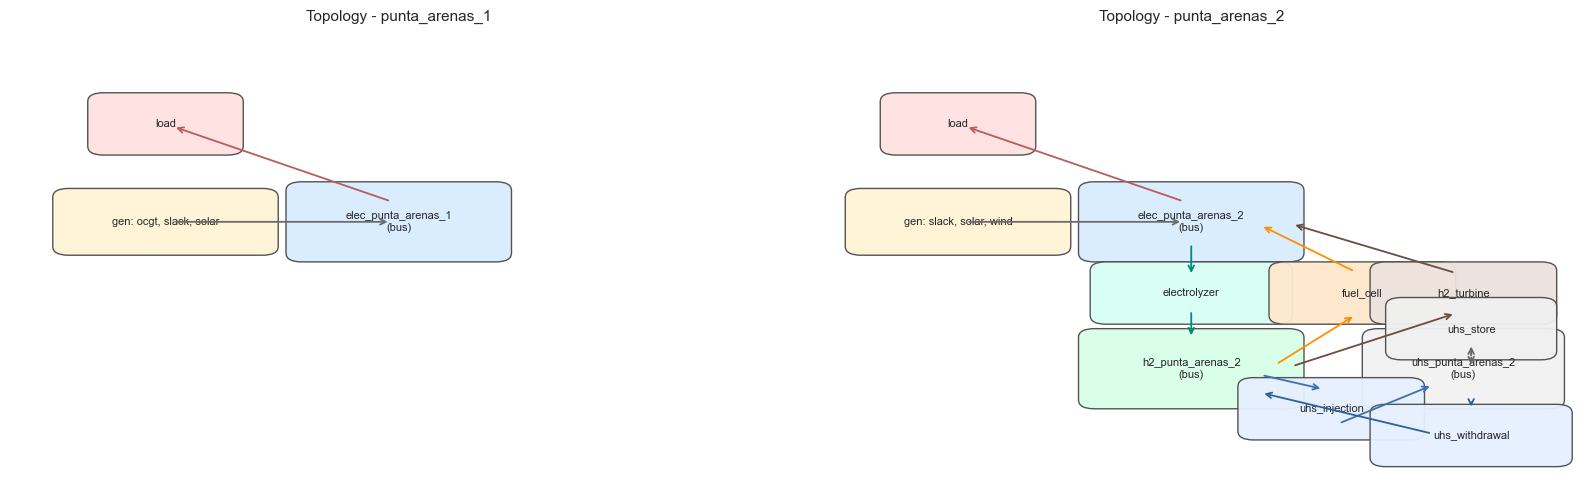

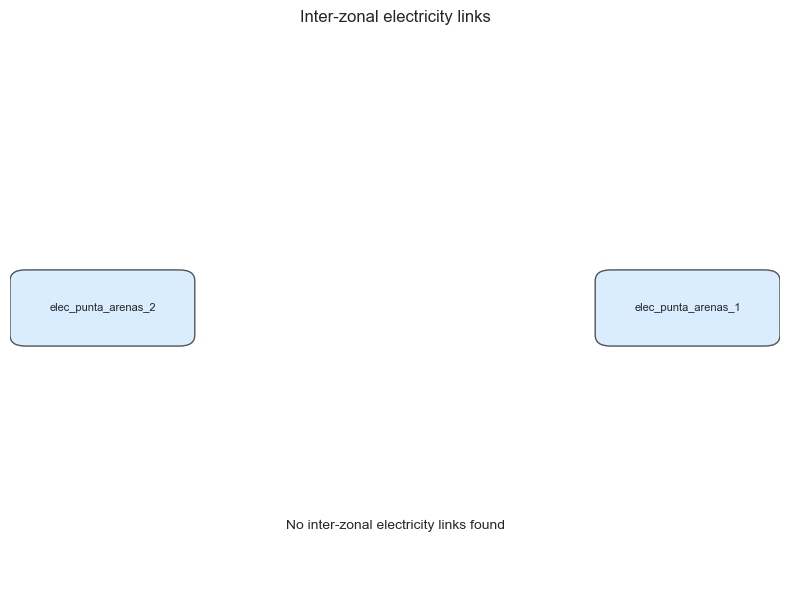

In [271]:
# System topology diagram by zone (electricity + hydrogen + UHS)
from matplotlib.patches import FancyBboxPatch
import numpy as np

def _draw_box(ax, xy, text, color="#e8eef7", width=0.2, height=0.12, fontsize=8):
    x, y = xy
    patch = FancyBboxPatch(
        (x - width / 2, y - height / 2), width, height,
        boxstyle="round,pad=0.02", linewidth=1.0, edgecolor="#4a4a4a", facecolor=color, alpha=0.95
    )
    ax.add_patch(patch)
    ax.text(x, y, text, ha="center", va="center", fontsize=fontsize)

def _draw_arrow(ax, start, end, color="#666", text=None):
    ax.annotate(
        "", xy=end, xytext=start,
        arrowprops=dict(arrowstyle="->", lw=1.3, color=color, shrinkA=8, shrinkB=8)
    )
    if text:
        mx = (start[0] + end[0]) / 2
        my = (start[1] + end[1]) / 2
        ax.text(mx, my + 0.03, text, fontsize=7, color=color, ha="center")

# Detect zones from electric buses
zone_names = sorted([b.replace("elec_", "") for b in n.buses.index if str(b).startswith("elec_")])
if not zone_names:
    raise ValueError("No electricity zones found in network buses.")

ncols = min(2, max(1, len(zone_names)))
nrows = int(np.ceil(len(zone_names) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 5 * nrows))
axes = np.atleast_1d(axes).flatten()

for i, zone in enumerate(zone_names):
    ax = axes[i]
    ax.set_title(f"Topology - {zone}", fontsize=11, pad=10)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

    elec_bus = f"elec_{zone}"
    h2_bus = f"h2_{zone}"
    uhs_bus = f"uhs_{zone}"

    has_h2_bus = h2_bus in n.buses.index
    has_uhs_bus = uhs_bus in n.buses.index

    # Main buses
    _draw_box(ax, (0.5, 0.58), f"{elec_bus}\n(bus)", color="#d8ecff", width=0.25, height=0.14)
    if has_h2_bus:
        _draw_box(ax, (0.5, 0.25), f"{h2_bus}\n(bus)", color="#d8ffe8", width=0.25, height=0.14)
    if has_uhs_bus:
        _draw_box(ax, (0.85, 0.25), f"{uhs_bus}\n(bus)", color="#f2f2f2", width=0.22, height=0.14)

    # Load and generators at electricity bus
    if f"load_{zone}" in n.loads.index:
        _draw_box(ax, (0.2, 0.80), "load", color="#ffe1e1", width=0.16, height=0.10)
        _draw_arrow(ax, (0.5, 0.62), (0.2, 0.80), color="#b85c5c")

    zone_gens = [g for g in n.generators.index if str(g).endswith(f"_{zone}")]
    if zone_gens:
        carriers = sorted(set(n.generators.loc[zone_gens, "carrier"].astype(str)))
        label = "gen: " + ", ".join(carriers[:4]) + ("..." if len(carriers) > 4 else "")
        _draw_box(ax, (0.2, 0.58), label, color="#fff4d6", width=0.25, height=0.11)
        _draw_arrow(ax, (0.2, 0.58), (0.5, 0.58), color="#6b6b6b")

    if f"bess_{zone}" in n.storage_units.index:
        _draw_box(ax, (0.2, 0.36), "bess", color="#efe0ff", width=0.16, height=0.10)
        _draw_arrow(ax, (0.2, 0.36), (0.5, 0.58), color="#9966cc")
        _draw_arrow(ax, (0.5, 0.58), (0.2, 0.36), color="#9966cc")

    # H2 chain components
    if has_h2_bus:
        if f"h2_electrolyzer_{zone}" in n.links.index:
            _draw_box(ax, (0.5, 0.42), "electrolyzer", color="#d7fff4", width=0.22, height=0.10)
            _draw_arrow(ax, (0.5, 0.55), (0.5, 0.44), color="#00897b")
            _draw_arrow(ax, (0.5, 0.40), (0.5, 0.30), color="#00897b")

        if f"h2_fuel_cell_{zone}" in n.links.index:
            _draw_box(ax, (0.72, 0.42), "fuel_cell", color="#ffe8cc", width=0.20, height=0.10)
            _draw_arrow(ax, (0.6, 0.25), (0.72, 0.38), color="#ff8f00")
            _draw_arrow(ax, (0.72, 0.46), (0.58, 0.58), color="#ff8f00")

        if f"h2_turbine_{zone}" in n.links.index:
            _draw_box(ax, (0.85, 0.42), "h2_turbine", color="#ede2dd", width=0.20, height=0.10)
            _draw_arrow(ax, (0.62, 0.25), (0.85, 0.38), color="#6d4c41")
            _draw_arrow(ax, (0.85, 0.46), (0.62, 0.58), color="#6d4c41")

        if f"h2_store_{zone}" in n.stores.index:
            _draw_box(ax, (0.25, 0.25), "h2_tank_store", color="#ddfff2", width=0.22, height=0.10)
            _draw_arrow(ax, (0.38, 0.25), (0.5, 0.25), color="#26a69a")
            _draw_arrow(ax, (0.5, 0.25), (0.32, 0.25), color="#26a69a")

        if f"uhs_injection_{zone}" in n.links.index:
            _draw_box(ax, (0.68, 0.16), "uhs_injection", color="#e6f0ff", width=0.20, height=0.10)
            _draw_arrow(ax, (0.58, 0.24), (0.68, 0.20), color="#3d6fb4")
            _draw_arrow(ax, (0.68, 0.12), (0.82, 0.22), color="#3d6fb4")

        if f"uhs_withdrawal_{zone}" in n.links.index:
            _draw_box(ax, (0.86, 0.10), "uhs_withdrawal", color="#e6f0ff", width=0.22, height=0.10)
            _draw_arrow(ax, (0.86, 0.20), (0.86, 0.14), color="#2f5f9e")
            _draw_arrow(ax, (0.82, 0.10), (0.58, 0.20), color="#2f5f9e")

        if f"uhs_store_{zone}" in n.stores.index:
            _draw_box(ax, (0.86, 0.34), "uhs_store", color="#f0f0f0", width=0.18, height=0.10)
            _draw_arrow(ax, (0.86, 0.28), (0.86, 0.30), color="#666")
            _draw_arrow(ax, (0.86, 0.30), (0.86, 0.26), color="#666")

    # Hydrogen demand load if present
    h2_load_id = f"h2_demand_{zone}"
    if h2_load_id in n.loads.index:
        _draw_box(ax, (0.2, 0.12), "h2_demand", color="#ffd8d8", width=0.18, height=0.10)
        _draw_arrow(ax, (0.5, 0.25), (0.2, 0.12), color="#b85c5c")

# Hide empty axes when zones < grid slots
for j in range(len(zone_names), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

# Inter-zonal electricity links (global view)
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_title("Inter-zonal electricity links", fontsize=12, pad=10)
ax.axis("off")

theta = np.linspace(0, 2 * np.pi, len(zone_names), endpoint=False)
radius = 0.38
center = np.array([0.5, 0.5])
positions = {
    z: center + radius * np.array([np.cos(t), np.sin(t)])
    for z, t in zip(zone_names, theta)
}

for z, pos in positions.items():
    _draw_box(
        ax, tuple(pos), f"elec_{z}", color="#d8ecff",
        width=0.20, height=0.10, fontsize=8
    )

seen_pairs = set()
for link_name, row in n.links.iterrows():
    if not str(link_name).startswith("link_"):
        continue
    bus0 = str(row.get("bus0", ""))
    bus1 = str(row.get("bus1", ""))
    if not (bus0.startswith("elec_") and bus1.startswith("elec_")):
        continue

    z0 = bus0.replace("elec_", "")
    z1 = bus1.replace("elec_", "")
    if z0 not in positions or z1 not in positions or z0 == z1:
        continue

    pair = tuple(sorted([z0, z1]))
    if pair in seen_pairs:
        continue
    seen_pairs.add(pair)

    p0 = positions[z0]
    p1 = positions[z1]
    cap = float(row.get("p_nom", np.nan))
    cap_txt = f"{cap:.1f} MW" if np.isfinite(cap) else None
    _draw_arrow(ax, tuple(p0), tuple(p1), color="#3e7f3e", text=cap_txt)

if not seen_pairs:
    ax.text(0.5, 0.1, "No inter-zonal electricity links found", ha="center", va="center", fontsize=10)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

In [272]:
# ─────────────────────────────────────────────────────────────────────────────
# Georeferenced node map with capacities, generation assets and transmission
# ─────────────────────────────────────────────────────────────────────────────
import folium
import numpy as np
import pandas as pd
from pathlib import Path
from IPython.display import display

# ── Colours ─────────────────────────────────────────────────────────────────
if "TECH_COLORS" not in globals():
    TECH_COLORS = {
        "wind": "#5bbcff",
        "solar": "#ffd54f",
        "solar_utility": "#f4c430",
        "solar_residential": "#ffe082",
        "solar_generic": "#ffd54f",
        "ocgt": "#b85c5c",
        "bess": "#9966cc",
        "slack": "#d32f2f",
        "natural_gas": "#bdbdbd",
        "gas": "#bdbdbd",
        "electrolyzer": "#00897b",
        "h2_fuel_cell": "#ff8f00",
        "h2_turbine": "#6d4c41",
        "hydrogen_storage": "#26a69a",
        "uhs_storage": "#8e24aa",
        "transmission": "#2e7d32",
    }

# ── Helper functions ────────────────────────────────────────────────────────
def _clean_zone_from_bus(bus):
    return str(bus).replace("elec_", "").replace("h2_", "").replace("uhs_", "")


def _capacity_from_row(row, opt_col="p_nom_opt", fixed_col="p_nom"):
    if opt_col in row.index and pd.notna(row.get(opt_col)):
        return float(row.get(opt_col))
    if fixed_col in row.index and pd.notna(row.get(fixed_col)):
        return float(row.get(fixed_col))
    return 0.0


def _energy_capacity_from_row(row, opt_col="e_nom_opt", fixed_col="e_nom"):
    if opt_col in row.index and pd.notna(row.get(opt_col)):
        return float(row.get(opt_col))
    if fixed_col in row.index and pd.notna(row.get(fixed_col)):
        return float(row.get(fixed_col))
    return 0.0


def classify_generation_asset(asset_name, carrier):
    """
    Classify assets for plotting.
    Solar utility/residential is inferred from the generator/asset name.
    If the name does not include a clear label, it remains solar_generic.
    """
    name = str(asset_name).lower()
    carrier = str(carrier).lower()

    if carrier == "solar":
        if any(k in name for k in ["residential", "rooftop", "roof", "distributed", "behind_meter"]):
            return "solar_residential"
        if any(k in name for k in ["utility", "farm", "central", "grid_scale", "pv_utility"]):
            return "solar_utility"
        return "solar_generic"

    if carrier in ["wind", "ocgt", "bess", "slack", "natural_gas", "gas"]:
        return carrier

    return carrier


def get_nodes_coordinates():
    """
    Priority:
    1) nodes stored in all_results[detailed_year]["nodes"]
    2) nodes_df variable in notebook
    3) input folder nodes.csv
    """
    nodes_table = None

    if "all_results" in globals() and detailed_year in all_results:
        nodes_table = all_results[detailed_year].get("nodes")

    if nodes_table is None and "nodes_df" in globals():
        nodes_table = nodes_df

    if nodes_table is None:
        candidate_paths = [
            Path(case_folder) / "nodes.csv" if "case_folder" in globals() else None,
            Path("input_punta_arenas") / "nodes.csv",
            Path("nodes.csv"),
        ]
        for p in candidate_paths:
            if p is not None and p.exists():
                nodes_table = pd.read_csv(p, comment="#")
                break

    if nodes_table is None:
        raise ValueError("Could not find nodes table. Load all_results or provide nodes.csv.")

    nodes_table = nodes_table.copy()

    if "enabled" in nodes_table.columns:
        nodes_table = nodes_table[nodes_table["enabled"].astype(str).str.lower().isin(["true", "1", "yes"])].copy()

    required = {"zone", "lat", "lon"}
    missing = required - set(nodes_table.columns)
    if missing:
        raise ValueError(f"nodes table is missing required columns: {missing}")

    coords = {}
    for _, row in nodes_table.iterrows():
        zone = str(row["zone"]).strip()
        lat = float(row["lat"])
        lon = float(row["lon"])
        if np.isfinite(lat) and np.isfinite(lon):
            coords[zone] = (lat, lon)

    if not coords:
        raise ValueError("No valid lat/lon coordinates found in nodes table.")

    return coords, nodes_table


def build_generation_capacity_by_zone(net):
    """Generator + BESS power capacity by zone and plotting technology."""
    rows = []

    # Generators
    for gen_id, row in net.generators.iterrows():
        zone = _clean_zone_from_bus(row.get("bus", ""))
        carrier = str(row.get("carrier", ""))
        tech_plot = classify_generation_asset(gen_id, carrier)
        cap = _capacity_from_row(row, "p_nom_opt", "p_nom")

        rows.append({
            "zone": zone,
            "asset": gen_id,
            "asset_type": "generator",
            "carrier": carrier,
            "plot_technology": tech_plot,
            "capacity_mw": cap,
        })

    # BESS storage units
    for su_id, row in net.storage_units.iterrows():
        zone = _clean_zone_from_bus(row.get("bus", ""))
        cap = _capacity_from_row(row, "p_nom_opt", "p_nom")

        rows.append({
            "zone": zone,
            "asset": su_id,
            "asset_type": "storage_unit",
            "carrier": str(row.get("carrier", "bess")),
            "plot_technology": "bess",
            "capacity_mw": cap,
        })

    # H2 links: electrolyser, fuel cell, turbine, UHS injection/withdrawal
    for link_id, row in net.links.iterrows():
        carrier = str(row.get("carrier", ""))
        if carrier not in ["electrolyzer", "h2_fuel_cell", "h2_turbine", "uhs_injection", "uhs_withdrawal"]:
            continue

        # Use bus0 for assets consuming from that bus; clean either elec/h2/uhs prefix.
        zone = _clean_zone_from_bus(row.get("bus0", ""))
        cap = _capacity_from_row(row, "p_nom_opt", "p_nom")

        rows.append({
            "zone": zone,
            "asset": link_id,
            "asset_type": "link",
            "carrier": carrier,
            "plot_technology": carrier,
            "capacity_mw": cap,
        })

    assets = pd.DataFrame(rows)

    if assets.empty:
        return pd.DataFrame(), pd.DataFrame()

    cap_by_zone = (
        assets
        .groupby(["zone", "plot_technology"], as_index=False)["capacity_mw"]
        .sum()
        .pivot(index="zone", columns="plot_technology", values="capacity_mw")
        .fillna(0.0)
    )

    return cap_by_zone, assets


def build_h2_store_by_zone(net):
    """Hydrogen/UHS store energy capacity by zone."""
    rows = []

    for store_id, row in net.stores.iterrows():
        carrier = str(row.get("carrier", ""))
        if carrier not in ["hydrogen_storage", "uhs_storage"]:
            continue

        zone = _clean_zone_from_bus(row.get("bus", ""))
        e_cap = _energy_capacity_from_row(row, "e_nom_opt", "e_nom")

        rows.append({
            "zone": zone,
            "asset": store_id,
            "carrier": carrier,
            "energy_capacity_mwh": e_cap,
        })

    return pd.DataFrame(rows)


def get_transmission_corridors(net):
    """
    Build physical transmission corridors for plotting.

    Handles:
    - bidirectional pairs ending in _fwd/_rev
    - single directed electricity links
    """
    if len(net.links) == 0:
        return pd.DataFrame(), {}

    tx_links = net.links[
        (net.links["carrier"].astype(str) == "electricity")
        & net.links["bus0"].astype(str).str.startswith("elec_")
        & net.links["bus1"].astype(str).str.startswith("elec_")
    ].copy()

    if tx_links.empty:
        return pd.DataFrame(), {}

    p0 = net.links_t.p0.reindex(columns=tx_links.index, fill_value=0.0)

    rows = []
    series_dict = {}
    used = set()

    # First treat fwd/rev pairs as one physical corridor
    for link_id in tx_links.index:
        link_id_str = str(link_id)

        if not link_id_str.endswith("_fwd"):
            continue

        base = link_id_str[:-4]
        rev = f"{base}_rev"

        if rev not in tx_links.index:
            continue

        fwd_flow = p0[link_id].clip(lower=0.0)
        rev_flow = p0[rev].clip(lower=0.0)
        net_flow = fwd_flow - rev_flow
        gross_flow = fwd_flow + rev_flow

        cap = _capacity_from_row(tx_links.loc[link_id], "p_nom_opt", "p_nom")

        bus0 = str(tx_links.loc[link_id, "bus0"])
        bus1 = str(tx_links.loc[link_id, "bus1"])
        zone0 = _clean_zone_from_bus(bus0)
        zone1 = _clean_zone_from_bus(bus1)

        simultaneous_hours = int(((fwd_flow > 1e-6) & (rev_flow > 1e-6)).sum())

        rows.append({
            "corridor": base,
            "link_type": "bidirectional_pair",
            "zone0": zone0,
            "zone1": zone1,
            "capacity_mw": cap,
            "max_abs_net_flow_mw": float(net_flow.abs().max()),
            "avg_abs_net_flow_mw": float(net_flow.abs().mean()),
            "annual_net_flow_gwh_zone0_to_zone1": float(net_flow.sum() / 1e3),
            "annual_gross_flow_gwh": float(gross_flow.sum() / 1e3),
            "simultaneous_opposite_hours": simultaneous_hours,
        })

        series_dict[base] = pd.DataFrame({
            "fwd_mw": fwd_flow,
            "rev_mw": rev_flow,
            "net_mw": net_flow,
            "gross_mw": gross_flow,
        })

        used.add(link_id)
        used.add(rev)

    # Then treat remaining directed links
    for link_id, row in tx_links.iterrows():
        if link_id in used:
            continue

        flow = p0[link_id].clip(lower=0.0)
        cap = _capacity_from_row(row, "p_nom_opt", "p_nom")
        zone0 = _clean_zone_from_bus(row["bus0"])
        zone1 = _clean_zone_from_bus(row["bus1"])

        rows.append({
            "corridor": str(link_id),
            "link_type": "directed",
            "zone0": zone0,
            "zone1": zone1,
            "capacity_mw": cap,
            "max_abs_net_flow_mw": float(flow.max()),
            "avg_abs_net_flow_mw": float(flow.mean()),
            "annual_net_flow_gwh_zone0_to_zone1": float(flow.sum() / 1e3),
            "annual_gross_flow_gwh": float(flow.sum() / 1e3),
            "simultaneous_opposite_hours": np.nan,
        })

        series_dict[str(link_id)] = pd.DataFrame({
            "net_mw": flow,
            "gross_mw": flow,
        })

    return pd.DataFrame(rows), series_dict


def html_escape(x):
    return str(x).replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")


# ── Build map data ──────────────────────────────────────────────────────────
coords, nodes_table = get_nodes_coordinates()
cap_by_zone, asset_table = build_generation_capacity_by_zone(n)
h2_store_table = build_h2_store_by_zone(n)
tx_table, tx_series = get_transmission_corridors(n)

# Keep all model nodes, even if capacity is zero
all_zones = sorted(set(coords.keys()) | set(cap_by_zone.index.astype(str)))

missing_coords = [z for z in all_zones if z not in coords]
if missing_coords:
    raise ValueError(
        "These model zones do not have coordinates in nodes.csv: "
        f"{missing_coords}. Add lat/lon to nodes.csv rather than using fake locations."
    )

cap_by_zone = cap_by_zone.reindex(all_zones, fill_value=0.0)

# ── Create map ──────────────────────────────────────────────────────────────
center_lat = float(np.mean([coords[z][0] for z in all_zones]))
center_lon = float(np.mean([coords[z][1] for z in all_zones]))

# Punta Arenas nodes are close, so start with a closer zoom
m = folium.Map(location=[center_lat, center_lon], zoom_start=12, tiles=None, control_scale=True)

folium.TileLayer(
    tiles="https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}",
    attr="Tiles © Esri",
    name="Satellite (Esri)",
    overlay=False,
    control=True,
).add_to(m)

folium.TileLayer(
    "OpenStreetMap",
    name="Streets (OSM)",
    overlay=False,
    control=True,
).add_to(m)

# ── Transmission corridors ─────────────────────────────────────────────────
if not tx_table.empty:
    for _, row in tx_table.iterrows():
        z0 = row["zone0"]
        z1 = row["zone1"]

        if z0 not in coords or z1 not in coords:
            continue

        lat0, lon0 = coords[z0]
        lat1, lon1 = coords[z1]

        cap = float(row["capacity_mw"])
        avg_abs_flow = float(row["avg_abs_net_flow_mw"])
        annual_net = float(row["annual_net_flow_gwh_zone0_to_zone1"])
        simultaneous = row.get("simultaneous_opposite_hours", np.nan)

        weight = max(2.0, min(9.0, 2.0 + cap / 80.0))

        popup = (
            f"<b>{html_escape(row['corridor'])}</b><br>"
            f"{html_escape(z0)} → {html_escape(z1)}<br>"
            f"Capacity: {cap:.1f} MW<br>"
            f"Avg |net flow|: {avg_abs_flow:.1f} MW<br>"
            f"Annual net flow: {annual_net:.1f} GWh<br>"
            f"Annual gross flow: {float(row['annual_gross_flow_gwh']):.1f} GWh<br>"
        )

        if pd.notna(simultaneous):
            popup += f"Simultaneous opposite-flow hours: {int(simultaneous)}<br>"

        folium.PolyLine(
            locations=[[lat0, lon0], [lat1, lon1]],
            color=TECH_COLORS.get("transmission", "#2e7d32"),
            weight=weight,
            opacity=0.8,
            popup=folium.Popup(popup, max_width=350),
            tooltip=f"{row['corridor']} | {cap:.0f} MW",
        ).add_to(m)

# ── Node markers ────────────────────────────────────────────────────────────
for zone in all_zones:
    lat, lon = coords[zone]
    capacities = cap_by_zone.loc[zone]
    total_cap = float(capacities.sum())

    # Choose dominant visible technology, excluding slack if possible
    visible_techs = capacities[capacities > 1e-6].copy()
    visible_no_slack = visible_techs.drop(labels=["slack"], errors="ignore")

    if not visible_no_slack.empty:
        dominant_tech = str(visible_no_slack.idxmax())
    elif not visible_techs.empty:
        dominant_tech = str(visible_techs.idxmax())
    else:
        dominant_tech = "slack"

    marker_color = TECH_COLORS.get(dominant_tech, "#5bbcff")

    # Popup
    popup_text = f"<b>{html_escape(zone.upper())}</b><br>"
    popup_text += f"Total installed power: {total_cap:.1f} MW<br><br>"

    for tech, value in capacities.sort_values(ascending=False).items():
        if value > 1e-6:
            popup_text += f"{html_escape(tech)}: {float(value):.1f} MW<br>"

    if not h2_store_table.empty:
        stores_z = h2_store_table[h2_store_table["zone"] == zone]
        if not stores_z.empty:
            popup_text += "<br><b>H2/UHS stores</b><br>"
            for _, st in stores_z.iterrows():
                if st["energy_capacity_mwh"] > 1e-6:
                    popup_text += (
                        f"{html_escape(st['carrier'])}: "
                        f"{float(st['energy_capacity_mwh']) / 1e3:.2f} GWh<br>"
                    )

    radius = max(8, min(38, 8 + np.sqrt(max(total_cap, 0.0)) * 1.4))

    folium.CircleMarker(
        location=[lat, lon],
        radius=radius,
        popup=folium.Popup(popup_text, max_width=330),
        tooltip=f"{zone} | {total_cap:.1f} MW",
        color="black",
        weight=2,
        fill=True,
        fillColor=marker_color,
        fillOpacity=0.78,
    ).add_to(m)

    # Permanent small label
    folium.map.Marker(
        [lat, lon],
        icon=folium.DivIcon(
            html=f"""
            <div style="
                font-size: 11px;
                font-weight: bold;
                color: white;
                text-shadow: 1px 1px 2px black;
                transform: translate(10px, -8px);
                white-space: nowrap;">
                {html_escape(zone)}
            </div>
            """
        ),
    ).add_to(m)

# ── Layer control and legend ────────────────────────────────────────────────
folium.LayerControl(collapsed=False).add_to(m)

legend_html = """
<div style="position: fixed; bottom: 40px; right: 40px; width: 255px; z-index:9999;
            background: white; border:2px solid #444; border-radius:8px; padding:10px; font-size:12px;">
<b>Technologies</b><br>
<i style="background:#5bbcff; width: 12px; height: 12px; display: inline-block;"></i> Wind<br>
<i style="background:#f4c430; width: 12px; height: 12px; display: inline-block;"></i> Solar utility / generic<br>
<i style="background:#ffe082; width: 12px; height: 12px; display: inline-block;"></i> Solar residential / rooftop<br>
<i style="background:#9966cc; width: 12px; height: 12px; display: inline-block;"></i> BESS<br>
<i style="background:#b85c5c; width: 12px; height: 12px; display: inline-block;"></i> OCGT / thermal<br>
<i style="background:#00897b; width: 12px; height: 12px; display: inline-block;"></i> Electrolyser<br>
<i style="background:#8e24aa; width: 12px; height: 12px; display: inline-block;"></i> UHS<br>
<i style="background:#2e7d32; width: 24px; height: 4px; display: inline-block;"></i> Transmission<br><br>
<b>Circle size:</b> total installed power<br>
<b>Line width:</b> transmission capacity
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

display(m)

# ── Tables ─────────────────────────────────────────────────────────────────
print("\n=== NODE COORDINATES USED ===")
display(nodes_table[["zone", "lat", "lon"]].round(5))

print("\n=== INSTALLED POWER CAPACITIES BY ZONE AND TECHNOLOGY [MW] ===")
display(cap_by_zone.round(2))

print("\n=== ASSET-TO-NODE ASSIGNMENT [MW] ===")
if not asset_table.empty:
    display(
        asset_table
        .sort_values(["zone", "asset_type", "plot_technology", "asset"])
        .reset_index(drop=True)
        .round(3)
    )
else:
    print("No generation/storage assets found.")

print("\n=== H2/UHS STORE ENERGY CAPACITY BY ZONE [MWh] ===")
if not h2_store_table.empty:
    display(
        h2_store_table
        .sort_values(["zone", "carrier", "asset"])
        .reset_index(drop=True)
        .round(3)
    )
else:
    print("No H2/UHS stores found.")

print("\n=== TRANSMISSION CORRIDORS ===")
if not tx_table.empty:
    display(tx_table.round(3))
else:
    print("No electricity transmission links found.")


=== NODE COORDINATES USED ===


,zone,lat,lon
0,punta_arenas_1,-53.16,-70.93
1,punta_arenas_2,-53.16,-70.89



=== INSTALLED POWER CAPACITIES BY ZONE AND TECHNOLOGY [MW] ===


plot_technology,bess,electrolyzer,h2_fuel_cell,h2_turbine,ocgt,slack,solar_residential,solar_utility,uhs_injection,uhs_withdrawal,wind
zone,,,,,,,,,,,
punta_arenas_1,0.0,0.0,0.0,0.0,80.0,1000000.0,150.0,0.0,0.0,0.0,0.00
punta_arenas_2,2000.0,0.0,0.0,0.0,0.0,1000000.0,0.0,1500.0,0.0,0.0,2502.55



=== ASSET-TO-NODE ASSIGNMENT [MW] ===


,zone,asset,asset_type,carrier,plot_technology,capacity_mw
0,punta_arenas_1,ocgt_existing_punta_arenas_1,generator,ocgt,ocgt,80.00
1,punta_arenas_1,slack_punta_arenas_1,generator,slack,slack,1000000.00
2,punta_arenas_1,pv_residential_flexible_punta_arenas_1,generator,solar,solar_residential,150.00
3,punta_arenas_2,slack_punta_arenas_2,generator,slack,slack,1000000.00
4,punta_arenas_2,solar_utility_flexible_punta_arenas_2,generator,solar,solar_utility,1500.00
5,punta_arenas_2,wind_existing_punta_arenas_2,generator,wind,wind,2.55
6,punta_arenas_2,wind_flexible_punta_arenas_2,generator,wind,wind,2500.00
7,punta_arenas_2,h2_electrolyzer_punta_arenas_2,link,electrolyzer,electrolyzer,0.00
8,punta_arenas_2,h2_fuel_cell_punta_arenas_2,link,h2_fuel_cell,h2_fuel_cell,0.00
9,punta_arenas_2,h2_turbine_punta_arenas_2,link,h2_turbine,h2_turbine,0.00



=== H2/UHS STORE ENERGY CAPACITY BY ZONE [MWh] ===


,zone,asset,carrier,energy_capacity_mwh
0,punta_arenas_2,uhs_store_punta_arenas_2,uhs_storage,0.0



=== TRANSMISSION CORRIDORS ===


,corridor,link_type,zone0,zone1,capacity_mw,max_abs_net_flow_mw,avg_abs_net_flow_mw,annual_net_flow_gwh_zone0_to_zone1,annual_gross_flow_gwh,simultaneous_opposite_hours
0,tx_punta_arenas_1_2,bidirectional_pair,punta_arenas_1,punta_arenas_2,250.0,234.074,131.025,-1147.779,2905.404,8107


=== Checking existing cutouts ===
2016: True | C:\Users\vse23\OneDrive - University of Canterbury\Vicente\Analysis\0_PyPSA-Isolated\model\data\magallanes_2016.nc
2017: True | C:\Users\vse23\OneDrive - University of Canterbury\Vicente\Analysis\0_PyPSA-Isolated\model\data\magallanes_2017.nc
2018: True | C:\Users\vse23\OneDrive - University of Canterbury\Vicente\Analysis\0_PyPSA-Isolated\model\data\magallanes_2018.nc
2019: True | C:\Users\vse23\OneDrive - University of Canterbury\Vicente\Analysis\0_PyPSA-Isolated\model\data\magallanes_2019.nc
2020: True | C:\Users\vse23\OneDrive - University of Canterbury\Vicente\Analysis\0_PyPSA-Isolated\model\data\magallanes_2020.nc
2021: True | C:\Users\vse23\OneDrive - University of Canterbury\Vicente\Analysis\0_PyPSA-Isolated\model\data\magallanes_2021.nc
2022: True | C:\Users\vse23\OneDrive - University of Canterbury\Vicente\Analysis\0_PyPSA-Isolated\model\data\magallanes_2022.nc
2023: True | C:\Users\vse23\OneDrive - University of Canterbury\Vicent

INFO:atlite.convert:Convert and aggregate 'wind'.


Using existing cutout: data\magallanes_2016.nc


INFO:atlite.convert:Convert and aggregate 'pv'.
INFO:atlite.convert:Convert and aggregate 'wind'.
INFO:atlite.convert:Convert and aggregate 'pv'.


Updated VRE profiles for 4 generators.


...

Writing continuous variables.: 100%|██████████| 7/7 [00:00<00:00, 88.22it/s]


Set parameter Username
Set parameter LicenseID to value 2807461
Academic license - for non-commercial use only - expires 2027-04-15
Read LP format model from file C:\Users\vse23\AppData\Local\Temp\linopy-problem-94nhrsfw.lp
Reading time = 2.50 seconds
obj: 429243 rows, 192720 columns, 700799 nonzeros
Set parameter LogToConsole to value 1
Set parameter TimeLimit to value 2000
Set parameter MIPGap to value 0.02
Set parameter Threads to value 8

=== Weather-year robustness summary ===


,weather_year,model_year,status,condition,solver,objective,demand_gwh,wind_generation_gwh,solar_generation_gwh,thermal_generation_gwh,...,h2_store_energy_gwh,uhs_store_energy_gwh,electrolyzer_input_gwh,h2_fuel_cell_output_gwh,h2_turbine_output_gwh,uhs_injection_gwh,uhs_withdrawal_gwh,tx_capacity_mw,tx_gross_flow_gwh,tx_net_abs_flow_gwh
0,2016,2050,ok,optimal,gurobi,7.740055e+08,1245.887,954.752,296.642,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,250.0,1165.625,1165.295
1,2017,2050,ok,optimal,gurobi,0.000000e+00,1245.887,995.323,257.442,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,250.0,1171.375,1171.044
2,2018,2050,ok,optimal,gurobi,0.000000e+00,1245.887,987.598,268.355,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,250.0,1169.465,1169.133
3,2019,2050,ok,optimal,gurobi,0.000000e+00,1245.887,1009.755,244.647,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,250.0,1173.060,1172.731
4,2020,2050,ok,optimal,gurobi,3.463789e+08,1245.887,996.497,255.364,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,250.0,1174.425,1174.095
5,2021,2050,ok,optimal,gurobi,0.000000e+00,1245.887,936.987,321.296,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,250.0,1077.885,1077.556
6,2022,2050,ok,optimal,gurobi,3.018625e+07,1245.887,931.115,323.067,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,250.0,1073.153,1072.341
7,2023,2050,ok,optimal,gurobi,0.000000e+00,1245.887,1028.242,224.216,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,250.0,1179.409,1179.079
8,2024,2050,ok,optimal,gurobi,0.000000e+00,1245.887,988.083,270.616,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,250.0,1177.341,1177.011
9,2025,2050,ok,optimal,gurobi,4.430354e+08,1245.887,990.483,260.796,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,250.0,1177.431,1177.099


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Saved: weather_robustness_RH_full_2050.csv


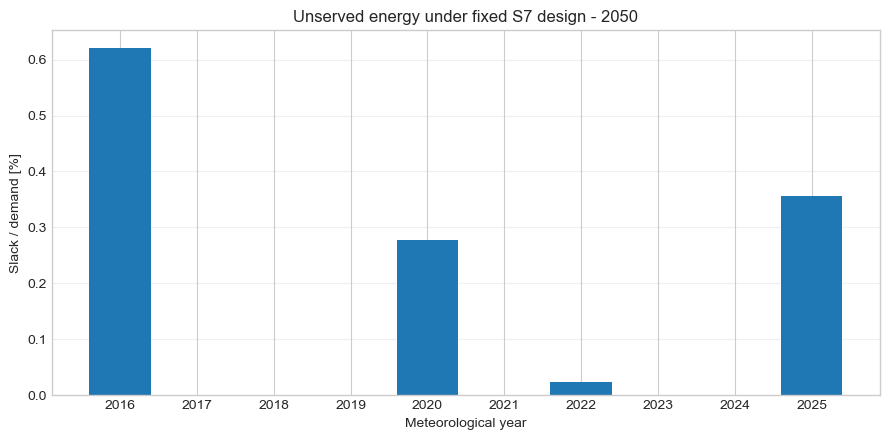

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


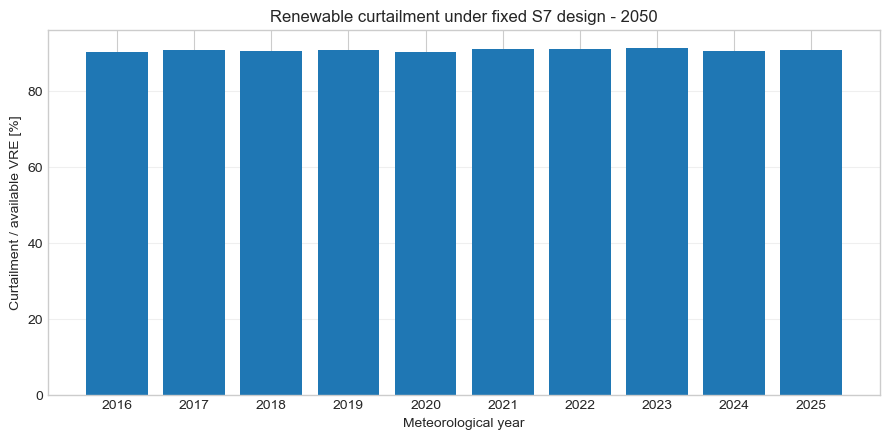

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


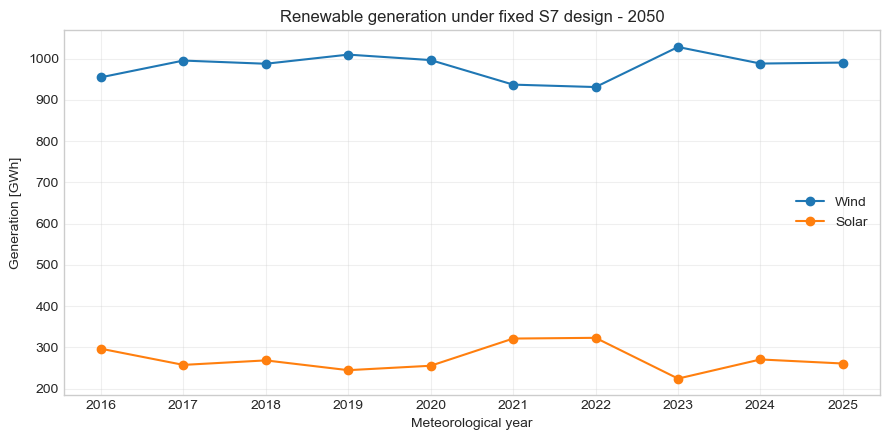

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

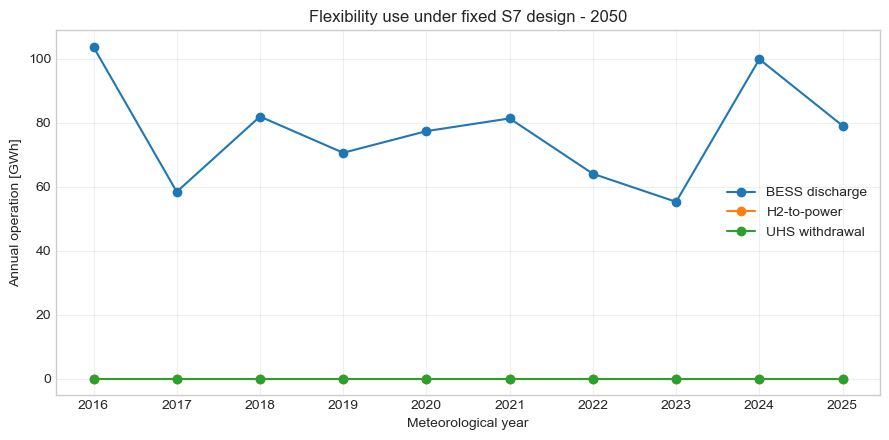

INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


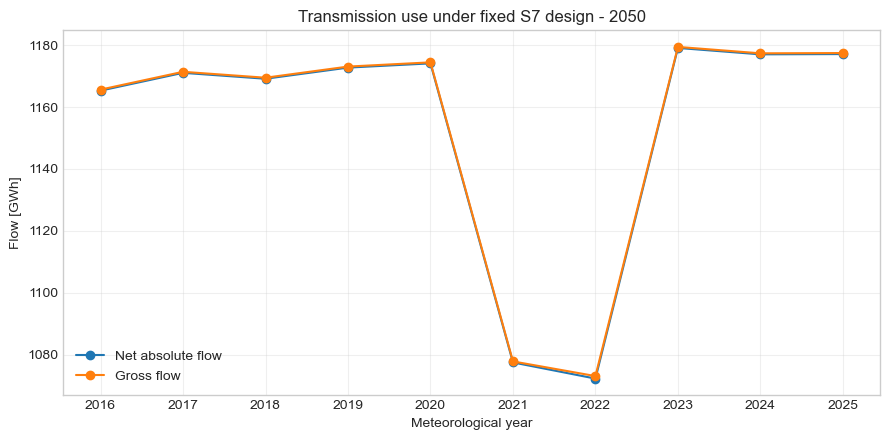

In [273]:
# ─────────────────────────────────────────────────────────────────────────────
# 3.4 Robustness across meteorological years
# Fixed-capacity re-operation of S7 under alternative weather years
# ─────────────────────────────────────────────────────────────────────────────

from pathlib import Path
import tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pypsa
import atlite

# ── User settings ───────────────────────────────────────────────────────────
robustness_scenario_code = "RH_full"   # S7
robustness_target_year = 2050
robustness_weather_years = list(range(2016, 2026))

# Existing cutouts are stored as data/magallanes_{year}.nc
robustness_cutout_base_dir = Path("data")
robustness_cutout_prefix = "magallanes"

# Solver settings fallback, in case some variables are not defined in the notebook
solver_name_robustness = globals().get("solver_name", "gurobi")
time_limit_robustness = globals().get("time_limit", None)
mip_gap_robustness = globals().get("mip_gap", None)
threads_robustness = globals().get("threads", None)
fallback_to_highs_robustness = globals().get("fallback_to_highs", True)

# Important: do NOT prepare cutouts here. We only open existing files.
prepare_cutouts_for_robustness = False

# ── Check existing cutouts ──────────────────────────────────────────────────
print("=== Checking existing cutouts ===")
missing_cutouts = []

for_wy_rows = []
for wy in robustness_weather_years:
    p = robustness_cutout_base_dir / f"{robustness_cutout_prefix}_{wy}.nc"
    exists = p.exists()
    for_wy_rows.append({"weather_year": wy, "exists": exists, "path": str(p.resolve())})
    print(f"{wy}: {exists} | {p.resolve()}")
    if not exists:
        missing_cutouts.append(p)

if missing_cutouts:
    raise FileNotFoundError(
        "Some robustness cutouts are missing. Check the folder/path before running:\n"
        + "\n".join(str(p.resolve()) for p in missing_cutouts)
    )

# ── Retrieve critical-year optimised design ─────────────────────────────────
if robustness_scenario_code not in scenario_results:
    raise KeyError(
        f"{robustness_scenario_code} not found in scenario_results. "
        "Run S7 before running robustness."
    )

base_package = scenario_results[robustness_scenario_code]
base_result = base_package["results"][robustness_target_year]
base_net = base_result["network"]
base_nodes = base_result["nodes"]

critical_weather_year_used = base_result.get("weather_year", critical_weather_year)

print(
    "\nUsing fixed capacities from "
    f"scenario {robustness_scenario_code}, "
    f"model year {robustness_target_year}, "
    f"optimised with weather year {critical_weather_year_used}."
)

# ── Helper functions ────────────────────────────────────────────────────────

def _copy_optimized_capacities_to_nominal(net):
    """
    Convert an optimised expansion network into a fixed-capacity operation network.

    This avoids deepcopy errors caused by solver/linopy/Gurobi objects stored
    inside net.model after optimisation.
    """
    with tempfile.TemporaryDirectory() as tmpdir:
        tmp_path = Path(tmpdir) / "fixed_capacity_template.nc"
        net.export_to_netcdf(tmp_path)
        net_fixed = pypsa.Network(tmp_path)

    net = net_fixed

    # Generators
    if len(net.generators) > 0:
        if "p_nom_opt" in net.generators.columns:
            mask = net.generators["p_nom_opt"].notna()
            net.generators.loc[mask, "p_nom"] = net.generators.loc[mask, "p_nom_opt"]

        if "p_nom_extendable" in net.generators.columns:
            net.generators["p_nom_extendable"] = False

    # StorageUnits, e.g. BESS
    if len(net.storage_units) > 0:
        if "p_nom_opt" in net.storage_units.columns:
            mask = net.storage_units["p_nom_opt"].notna()
            net.storage_units.loc[mask, "p_nom"] = net.storage_units.loc[mask, "p_nom_opt"]

        if "p_nom_extendable" in net.storage_units.columns:
            net.storage_units["p_nom_extendable"] = False

    # Links, e.g. transmission, electrolysers, fuel cells, H2 turbines
    if len(net.links) > 0:
        if "p_nom_opt" in net.links.columns:
            mask = net.links["p_nom_opt"].notna()
            net.links.loc[mask, "p_nom"] = net.links.loc[mask, "p_nom_opt"]

        if "p_nom_extendable" in net.links.columns:
            net.links["p_nom_extendable"] = False

    # Stores, e.g. H2 tank / UHS
    if len(net.stores) > 0:
        if "e_nom_opt" in net.stores.columns:
            mask = net.stores["e_nom_opt"].notna()
            net.stores.loc[mask, "e_nom"] = net.stores.loc[mask, "e_nom_opt"]

        if "e_nom_extendable" in net.stores.columns:
            net.stores["e_nom_extendable"] = False

    # Remove any old optimisation model if present
    if hasattr(net, "model"):
        try:
            delattr(net, "model")
        except Exception:
            pass

    return net


def _replace_vre_profiles_for_weather_year(net, weather_year):
    """
    Replace wind and solar p_max_pu using an existing cutout:
    data/magallanes_{weather_year}.nc

    This bypasses config.get_case_cutout to avoid creating/downloading new cutouts.
    """
    cutout_path = robustness_cutout_base_dir / f"{robustness_cutout_prefix}_{weather_year}.nc"

    if not cutout_path.exists():
        raise FileNotFoundError(
            f"Cutout not found: {cutout_path.resolve()}\n"
            "Check robustness_cutout_base_dir and robustness_cutout_prefix."
        )

    print(f"Using existing cutout: {cutout_path}")

    cutout = atlite.Cutout(str(cutout_path))

    wind_cf_hist, solar_cf_hist = config.get_vre_profiles_from_cutout(
        cutout=cutout,
        nodes_df=base_nodes,
        method=vre_profile_method,
        wind_turbine=wind_turbine,
        solar_panel=solar_panel,
        solar_orientation=solar_orientation,
    )

    wind_cf = config.map_weather_year(wind_cf_hist, target_year=robustness_target_year)
    solar_cf = config.map_weather_year(solar_cf_hist, target_year=robustness_target_year)

    # Ensure all generator columns exist in p_max_pu
    if net.generators_t.p_max_pu.empty:
        net.generators_t.p_max_pu = pd.DataFrame(
            1.0,
            index=net.snapshots,
            columns=net.generators.index,
        )
    else:
        net.generators_t.p_max_pu = net.generators_t.p_max_pu.reindex(
            index=net.snapshots,
            columns=net.generators.index,
            fill_value=1.0,
        )

    # Replace only VRE profiles
    replaced = []

    for gen_id, row in net.generators.iterrows():
        carrier = str(row.get("carrier", "")).lower()
        zone = str(row.get("bus", "")).replace("elec_", "")

        if carrier == "wind" and zone in wind_cf.columns:
            net.generators_t.p_max_pu[gen_id] = (
                wind_cf[zone].reindex(net.snapshots).fillna(0.0)
            )
            replaced.append(gen_id)

        elif carrier == "solar" and zone in solar_cf.columns:
            net.generators_t.p_max_pu[gen_id] = (
                solar_cf[zone].reindex(net.snapshots).fillna(0.0)
            )
            replaced.append(gen_id)

    print(f"Updated VRE profiles for {len(replaced)} generators.")

    return net, wind_cf, solar_cf


def _build_solver_options_for_robustness(target_solver):
    opts = {}

    if target_solver == "gurobi":
        if time_limit_robustness is not None:
            opts["TimeLimit"] = float(time_limit_robustness)
        if mip_gap_robustness is not None:
            opts["MIPGap"] = float(mip_gap_robustness)
        if threads_robustness is not None:
            opts["Threads"] = int(threads_robustness)

        opts["OutputFlag"] = 0
        opts["LogToConsole"] = 0

    elif target_solver == "highs":
        if time_limit_robustness is not None:
            opts["time_limit"] = float(time_limit_robustness)
        if mip_gap_robustness is not None:
            opts["mip_rel_gap"] = float(mip_gap_robustness)
        if threads_robustness is not None:
            opts["threads"] = int(threads_robustness)

    return opts


def _run_fixed_capacity_operation(net):
    """
    Optimise operation only, with all capacities fixed.
    """
    opts = _build_solver_options_for_robustness(solver_name_robustness)

    optimize_kwargs = {"solver_name": solver_name_robustness}
    if opts:
        optimize_kwargs["solver_options"] = opts

    extra_fun = getattr(config, "add_custom_constraints", None)

    try:
        if extra_fun is not None:
            status, condition = net.optimize(
                extra_functionality=extra_fun,
                **optimize_kwargs,
            )
        else:
            status, condition = net.optimize(**optimize_kwargs)

        used_solver = solver_name_robustness

    except Exception as exc:
        if fallback_to_highs_robustness and solver_name_robustness == "gurobi":
            print(f"Gurobi failed during robustness run: {exc}. Trying HiGHS.")

            fallback_kwargs = {"solver_name": "highs"}
            fallback_opts = _build_solver_options_for_robustness("highs")
            if fallback_opts:
                fallback_kwargs["solver_options"] = fallback_opts

            if extra_fun is not None:
                status, condition = net.optimize(
                    extra_functionality=extra_fun,
                    **fallback_kwargs,
                )
            else:
                status, condition = net.optimize(**fallback_kwargs)

            used_solver = "highs"
        else:
            raise

    return status, condition, used_solver


def _generation_by_carrier(net):
    if len(net.generators) == 0:
        return pd.Series(dtype=float)

    gen = (
        net.generators_t.p
        .reindex(columns=net.generators.index, fill_value=0.0)
        .clip(lower=0.0)
    )
    carriers = net.generators["carrier"].astype(str)

    return gen.T.groupby(carriers).sum().T.sum().sort_values(ascending=False)


def _vre_curtailment_mwh(net):
    if len(net.generators) == 0:
        return 0.0

    total_curtailment = 0.0

    for carrier in ["wind", "solar"]:
        gens = net.generators.index[
            net.generators["carrier"].astype(str).str.lower() == carrier
        ]

        for gen_id in gens:
            p_nom = float(net.generators.loc[gen_id, "p_nom"])
            available = (
                net.generators_t.p_max_pu[gen_id]
                .fillna(0.0)
                .clip(lower=0.0)
                * p_nom
            )
            actual = net.generators_t.p[gen_id].fillna(0.0).clip(lower=0.0)
            total_curtailment += float((available - actual).clip(lower=0.0).sum())

    return total_curtailment


def _storage_metrics(net):
    bess_charge = 0.0
    bess_discharge = 0.0
    bess_energy_capacity = 0.0

    if len(net.storage_units) > 0:
        p = net.storage_units_t.p.reindex(
            columns=net.storage_units.index,
            fill_value=0.0,
        )
        bess_charge = float((-p.clip(upper=0.0)).sum().sum())
        bess_discharge = float(p.clip(lower=0.0).sum().sum())

        if "max_hours" in net.storage_units.columns:
            bess_energy_capacity = float(
                (net.storage_units["p_nom"] * net.storage_units["max_hours"]).sum()
            )

    h2_store_energy = 0.0
    uhs_store_energy = 0.0

    if len(net.stores) > 0:
        for _, row in net.stores.iterrows():
            carrier = str(row.get("carrier", "")).lower()
            e_nom = float(row.get("e_nom", 0.0))

            if carrier == "hydrogen_storage":
                h2_store_energy += e_nom
            elif carrier == "uhs_storage":
                uhs_store_energy += e_nom

    return {
        "bess_charge_mwh": bess_charge,
        "bess_discharge_mwh": bess_discharge,
        "bess_energy_capacity_mwh": bess_energy_capacity,
        "h2_store_energy_mwh": h2_store_energy,
        "uhs_store_energy_mwh": uhs_store_energy,
    }


def _h2_link_metrics(net):
    """
    Annual operation of hydrogen-related links.
    Positive p0 is input at bus0. Positive p1 is usually output at bus1
    with sign convention depending on PyPSA. We use p0 for consumption-side
    technologies and -p1 where useful for output-side energy.
    """
    out = {
        "electrolyzer_input_gwh": 0.0,
        "h2_fuel_cell_output_gwh": 0.0,
        "h2_turbine_output_gwh": 0.0,
        "uhs_injection_gwh": 0.0,
        "uhs_withdrawal_gwh": 0.0,
    }

    if len(net.links) == 0:
        return out

    p0 = net.links_t.p0.reindex(columns=net.links.index, fill_value=0.0)
    p1 = net.links_t.p1.reindex(columns=net.links.index, fill_value=0.0)

    for link_id, row in net.links.iterrows():
        carrier = str(row.get("carrier", "")).lower()

        if carrier == "electrolyzer":
            out["electrolyzer_input_gwh"] += float(p0[link_id].clip(lower=0.0).sum() / 1e3)

        elif carrier == "h2_fuel_cell":
            out["h2_fuel_cell_output_gwh"] += float((-p1[link_id]).clip(lower=0.0).sum() / 1e3)

        elif carrier == "h2_turbine":
            out["h2_turbine_output_gwh"] += float((-p1[link_id]).clip(lower=0.0).sum() / 1e3)

        elif carrier == "uhs_injection":
            out["uhs_injection_gwh"] += float(p0[link_id].clip(lower=0.0).sum() / 1e3)

        elif carrier == "uhs_withdrawal":
            out["uhs_withdrawal_gwh"] += float((-p1[link_id]).clip(lower=0.0).sum() / 1e3)

    return out


def _transmission_metrics(net):
    if len(net.links) == 0:
        return {
            "tx_capacity_mw": 0.0,
            "tx_gross_flow_mwh": 0.0,
            "tx_net_abs_flow_mwh": 0.0,
        }

    tx = net.links[
        (net.links["carrier"].astype(str) == "electricity")
        & net.links["bus0"].astype(str).str.startswith("elec_")
        & net.links["bus1"].astype(str).str.startswith("elec_")
    ]

    if tx.empty:
        return {
            "tx_capacity_mw": 0.0,
            "tx_gross_flow_mwh": 0.0,
            "tx_net_abs_flow_mwh": 0.0,
        }

    p0 = net.links_t.p0.reindex(columns=tx.index, fill_value=0.0)

    # Avoid double-counting fwd/rev pair capacity
    counted_links = []
    for link_id in tx.index:
        name = str(link_id)
        if name.endswith("_rev") and f"{name[:-4]}_fwd" in tx.index:
            continue
        counted_links.append(link_id)

    tx_capacity = float(tx.loc[counted_links, "p_nom"].sum())

    # Gross flow counts all directed flows
    gross_flow = float(p0.clip(lower=0.0).sum().sum())

    # Net absolute flow for fwd/rev pairs where possible
    used = set()
    net_abs_flow = 0.0

    for link_id in tx.index:
        name = str(link_id)

        if name in used:
            continue

        if name.endswith("_fwd") and f"{name[:-4]}_rev" in tx.index:
            rev = f"{name[:-4]}_rev"
            net = p0[link_id].clip(lower=0.0) - p0[rev].clip(lower=0.0)
            net_abs_flow += float(net.abs().sum())
            used.add(link_id)
            used.add(rev)

        elif name.endswith("_rev") and f"{name[:-4]}_fwd" in tx.index:
            continue

        else:
            net_abs_flow += float(p0[link_id].clip(lower=0.0).sum())
            used.add(link_id)

    return {
        "tx_capacity_mw": tx_capacity,
        "tx_gross_flow_mwh": gross_flow,
        "tx_net_abs_flow_mwh": net_abs_flow,
    }


def _summarise_robustness_result(net, weather_year, status, condition, used_solver):
    load_mwh = float(base_result["load"].sum().sum())

    gen_by_carrier = _generation_by_carrier(net)

    slack_mwh = float(
        gen_by_carrier[
            gen_by_carrier.index.astype(str).str.contains("slack", case=False)
        ].sum()
    )

    thermal_mwh = float(
        gen_by_carrier[
            gen_by_carrier.index.astype(str).str.lower().isin(
                ["ocgt", "gas", "natural_gas", "diesel"]
            )
        ].sum()
    )

    wind_mwh = float(
        gen_by_carrier[
            gen_by_carrier.index.astype(str).str.lower() == "wind"
        ].sum()
    )

    solar_mwh = float(
        gen_by_carrier[
            gen_by_carrier.index.astype(str).str.lower() == "solar"
        ].sum()
    )

    curtailment_mwh = _vre_curtailment_mwh(net)
    vre_available_mwh = wind_mwh + solar_mwh + curtailment_mwh

    storage = _storage_metrics(net)
    h2_links = _h2_link_metrics(net)
    tx = _transmission_metrics(net)

    objective = float(net.objective) if net.objective is not None else np.nan

    return {
        "weather_year": weather_year,
        "model_year": robustness_target_year,
        "status": status,
        "condition": condition,
        "solver": used_solver,
        "objective": objective,
        "demand_gwh": load_mwh / 1e3,
        "wind_generation_gwh": wind_mwh / 1e3,
        "solar_generation_gwh": solar_mwh / 1e3,
        "thermal_generation_gwh": thermal_mwh / 1e3,
        "slack_gwh": slack_mwh / 1e3,
        "slack_share_pct": 100.0 * slack_mwh / load_mwh if load_mwh > 0 else np.nan,
        "curtailment_gwh": curtailment_mwh / 1e3,
        "curtailment_share_vre_available_pct": (
            100.0 * curtailment_mwh / vre_available_mwh
            if vre_available_mwh > 0 else np.nan
        ),
        "bess_charge_gwh": storage["bess_charge_mwh"] / 1e3,
        "bess_discharge_gwh": storage["bess_discharge_mwh"] / 1e3,
        "bess_energy_capacity_gwh": storage["bess_energy_capacity_mwh"] / 1e3,
        "h2_store_energy_gwh": storage["h2_store_energy_mwh"] / 1e3,
        "uhs_store_energy_gwh": storage["uhs_store_energy_mwh"] / 1e3,
        "electrolyzer_input_gwh": h2_links["electrolyzer_input_gwh"],
        "h2_fuel_cell_output_gwh": h2_links["h2_fuel_cell_output_gwh"],
        "h2_turbine_output_gwh": h2_links["h2_turbine_output_gwh"],
        "uhs_injection_gwh": h2_links["uhs_injection_gwh"],
        "uhs_withdrawal_gwh": h2_links["uhs_withdrawal_gwh"],
        "tx_capacity_mw": tx["tx_capacity_mw"],
        "tx_gross_flow_gwh": tx["tx_gross_flow_mwh"] / 1e3,
        "tx_net_abs_flow_gwh": tx["tx_net_abs_flow_mwh"] / 1e3,
    }


# ── Run robustness loop ─────────────────────────────────────────────────────
weather_robustness_results = {}
weather_robustness_summary_rows = []

for wy in robustness_weather_years:
    print("\n" + "=" * 72)
    print(
        f"Fixed-capacity robustness run: S7 design, "
        f"model year {robustness_target_year}, weather year {wy}"
    )
    print("=" * 72)

    net_wy = _copy_optimized_capacities_to_nominal(base_net)
    net_wy, wind_cf_wy, solar_cf_wy = _replace_vre_profiles_for_weather_year(net_wy, wy)

    status, condition, used_solver = _run_fixed_capacity_operation(net_wy)

    weather_robustness_results[wy] = {
        "network": net_wy,
        "wind_cf": wind_cf_wy,
        "solar_cf": solar_cf_wy,
        "status": status,
        "condition": condition,
        "solver": used_solver,
    }

    summary_row = _summarise_robustness_result(
        net=net_wy,
        weather_year=wy,
        status=status,
        condition=condition,
        used_solver=used_solver,
    )
    weather_robustness_summary_rows.append(summary_row)

weather_robustness_summary = (
    pd.DataFrame(weather_robustness_summary_rows)
    .sort_values("weather_year")
    .reset_index(drop=True)
)

print("\n=== Weather-year robustness summary ===")
display(weather_robustness_summary.round(3))

# ── Save summary ────────────────────────────────────────────────────────────
robustness_output_csv = (
    f"weather_robustness_{robustness_scenario_code}_{robustness_target_year}.csv"
)
weather_robustness_summary.to_csv(robustness_output_csv, index=False)
print(f"Saved: {robustness_output_csv}")


# ── Quick plots for Section 3.4 ─────────────────────────────────────────────

# 1) Slack / demand
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(
    weather_robustness_summary["weather_year"].astype(str),
    weather_robustness_summary["slack_share_pct"],
)
ax.set_title(f"Unserved energy under fixed S7 design - {robustness_target_year}")
ax.set_xlabel("Meteorological year")
ax.set_ylabel("Slack / demand [%]")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 2) Curtailment
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(
    weather_robustness_summary["weather_year"].astype(str),
    weather_robustness_summary["curtailment_share_vre_available_pct"],
)
ax.set_title(f"Renewable curtailment under fixed S7 design - {robustness_target_year}")
ax.set_xlabel("Meteorological year")
ax.set_ylabel("Curtailment / available VRE [%]")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# 3) Wind and solar generation
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(
    weather_robustness_summary["weather_year"].astype(str),
    weather_robustness_summary["wind_generation_gwh"],
    marker="o",
    label="Wind",
)
ax.plot(
    weather_robustness_summary["weather_year"].astype(str),
    weather_robustness_summary["solar_generation_gwh"],
    marker="o",
    label="Solar",
)
ax.set_title(f"Renewable generation under fixed S7 design - {robustness_target_year}")
ax.set_xlabel("Meteorological year")
ax.set_ylabel("Generation [GWh]")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# 4) Flexibility operation
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(
    weather_robustness_summary["weather_year"].astype(str),
    weather_robustness_summary["bess_discharge_gwh"],
    marker="o",
    label="BESS discharge",
)
ax.plot(
    weather_robustness_summary["weather_year"].astype(str),
    weather_robustness_summary["h2_fuel_cell_output_gwh"]
    + weather_robustness_summary["h2_turbine_output_gwh"],
    marker="o",
    label="H2-to-power",
)
ax.plot(
    weather_robustness_summary["weather_year"].astype(str),
    weather_robustness_summary["uhs_withdrawal_gwh"],
    marker="o",
    label="UHS withdrawal",
)
ax.set_title(f"Flexibility use under fixed S7 design - {robustness_target_year}")
ax.set_xlabel("Meteorological year")
ax.set_ylabel("Annual operation [GWh]")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# 5) Transmission use
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(
    weather_robustness_summary["weather_year"].astype(str),
    weather_robustness_summary["tx_net_abs_flow_gwh"],
    marker="o",
    label="Net absolute flow",
)
ax.plot(
    weather_robustness_summary["weather_year"].astype(str),
    weather_robustness_summary["tx_gross_flow_gwh"],
    marker="o",
    label="Gross flow",
)
ax.set_title(f"Transmission use under fixed S7 design - {robustness_target_year}")
ax.set_xlabel("Meteorological year")
ax.set_ylabel("Flow [GWh]")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()